# Análisis EDA - Base de Liquidez Bancaria


<div style="text-align: justify;">

## 1. Introducción

El **Análisis Exploratorio de Datos (EDA)** constituye una etapa fundamental dentro del desarrollo del proyecto **LiquiditySense**, debido a que permite evaluar, comprender y validar la información financiera bancaria que será utilizada posteriormente para la construcción de un modelo de Machine Learning orientado a la **identificación de señales asociadas al deterioro del riesgo de liquidez**.

Antes de desarrollar cualquier modelo predictivo, es necesario comprender la estructura, calidad, distribución y comportamiento de los datos. Un modelo de Machine Learning aprende directamente de la información proporcionada; por tanto, si los datos presentan inconsistencias estructurales, valores faltantes no comprendidos, observaciones duplicadas, valores extremos o relaciones financieras que no han sido correctamente interpretadas, estas situaciones pueden trasladarse al modelo y afectar la confiabilidad de sus resultados.

En el contexto de `LiquiditySense`, esta etapa adquiere una importancia particular porque la información utilizada corresponde a **instituciones financieras observadas a través del tiempo**. El riesgo de liquidez no constituye una característica estática de una institución, sino una condición que puede modificarse como consecuencia de cambios en sus activos líquidos, depósitos, obligaciones, estructura de financiamiento, composición de activos y otros factores financieros.

Por esta razón, el EDA no se limitará a describir estadísticamente las variables, sino que buscará determinar si la información disponible permite representar adecuadamente la **evolución financiera de las instituciones bancarias** y si los indicadores construidos son consistentes con el fenómeno de riesgo que se pretende modelar.

</div>



<div style="text-align: justify;">

### 1.1 ¿Por qué realizamos el EDA?

El EDA se realiza para responder, antes de la etapa de modelización, preguntas fundamentales relacionadas con la calidad y utilidad de la información:

* ¿La base presenta una estructura correcta de institución y período?
* ¿Cada observación representa adecuadamente una institución financiera en una fecha determinada?
* ¿Existe información duplicada?
* ¿Cuál es la cobertura temporal y transversal de la base?
* ¿Qué variables presentan valores faltantes?
* ¿Los valores faltantes tienen una explicación económica, financiera o temporal?
* ¿Existen valores extremos que puedan distorsionar los indicadores?
* ¿Las variables presentan distribuciones razonables?
* ¿Existen relaciones relevantes entre los indicadores financieros?
* ¿Los indicadores construidos permiten representar cambios en la posición financiera de las instituciones?
* ¿Existen variables que puedan generar problemas de información futura o **data leakage** durante la construcción del modelo?

La respuesta a estas preguntas permitirá establecer criterios objetivos para decidir qué información debe conservarse, transformarse, excluirse o utilizarse posteriormente como variable predictora.

</div>


<div style="text-align: justify;">

### 1.2 Justificación metodológica

Desde una perspectiva de **Machine Learning Engineering**, el EDA constituye un mecanismo de control previo a la modelización. Su función no consiste únicamente en generar gráficos o estadísticas descriptivas, sino en garantizar que el conjunto de datos utilizado para entrenar el modelo sea **consistente, interpretable y adecuado para el objetivo predictivo planteado**.

Una base financieramente incorrecta puede producir un modelo aparentemente preciso, pero cuya capacidad predictiva no sea confiable. Por ejemplo, una duplicación de observaciones puede modificar artificialmente las distribuciones; una imputación inadecuada puede introducir información que no existía; un valor extremo puede dominar determinadas relaciones estadísticas; y una variable construida utilizando información futura puede generar **data leakage**, produciendo métricas de evaluación artificialmente elevadas.

En consecuencia, el EDA permitirá identificar y controlar estos riesgos antes de que la información llegue a la etapa de entrenamiento.

</div>

<div style="text-align: justify;">

### 1.3 Justificación financiera

Desde la perspectiva del **riesgo de liquidez**, resulta necesario analizar no solamente los niveles absolutos de las variables financieras, sino también su evolución.

Una institución puede presentar una determinada posición de liquidez en un período y, sin embargo, experimentar posteriormente un deterioro significativo. Por ello, la información histórica resulta esencial para identificar cambios en el comportamiento financiero que puedan constituir señales tempranas de deterioro.

En este sentido, los indicadores construidos previamente, incluyendo razones financieras y variaciones **QoQ** y **YoY**, buscan capturar diferentes dimensiones de la situación financiera de las instituciones.

El EDA permitirá comprobar si estos indicadores presentan un comportamiento coherente, si contienen información suficiente y si sus características estadísticas son compatibles con su utilización posterior en un modelo predictivo.

</div>

<div style="text-align: justify;">

### 1.4 Relación con el objetivo de LiquiditySense

El propósito de `LiquiditySense` no es únicamente describir la situación financiera histórica de las instituciones bancarias. El objetivo final es avanzar hacia un modelo capaz de **identificar patrones asociados al deterioro de la liquidez**, utilizando información financiera histórica como fuente de señales predictivas.

Por ello, el EDA representa el puente entre la **información financiera disponible** y la **información que posteriormente será utilizada por el algoritmo de Machine Learning**.

El proceso seguirá una lógica progresiva:

**Base procesada → Validación estructural → Calidad de datos → Análisis temporal → Análisis univariado → Análisis bivariado/multivariado → Identificación de relaciones → Definición de variables predictoras → Variable objetivo → Modelización**

Esta secuencia permite que las decisiones posteriores de modelización estén respaldadas por evidencia obtenida directamente de los datos y no únicamente por supuestos teóricos.


</div>

<div style="text-align: justify;">

### 1.5 Alcance del análisis

El EDA se desarrollará considerando cinco dimensiones principales:

1. **Estructura:** identificación de registros, variables, instituciones y período de análisis.
2. **Calidad:** evaluación de valores faltantes, duplicados, tipos de datos y posibles inconsistencias.
3. **Comportamiento estadístico:** análisis de distribuciones, dispersión y valores extremos.
4. **Dimensión temporal:** evaluación de la evolución de los indicadores financieros y sus variaciones.
5. **Relaciones entre variables:** identificación de asociaciones relevantes y posibles problemas de redundancia o multicolinealidad.

Estas dimensiones permitirán construir una visión integral del conjunto de datos antes de proceder al desarrollo del modelo.

</div>

<div style="text-align: justify;">

### 1.6 Criterio general de interpretación

Una consideración fundamental durante todo el EDA será que **los resultados estadísticos deben interpretarse conjuntamente con su significado financiero**.

Una correlación, un valor extremo, un porcentaje de datos faltantes o una determinada distribución no deben evaluarse únicamente desde una perspectiva matemática. Cada resultado deberá contrastarse con la naturaleza económica y financiera de la variable y con su posible relación con el riesgo de liquidez.

De esta manera, el análisis buscará evitar interpretaciones puramente mecánicas y establecer conclusiones que puedan ser justificadas tanto desde el punto de vista estadístico como desde la perspectiva financiera.


</div>

<div style="text-align: justify;">

### 1.7 Criterio general de interpretación

Una consideración fundamental durante todo el EDA será que **los resultados estadísticos deben interpretarse conjuntamente con su significado financiero**.

Una correlación, un valor extremo, un porcentaje de datos faltantes o una determinada distribución no deben evaluarse únicamente desde una perspectiva matemática. Cada resultado deberá contrastarse con la naturaleza económica y financiera de la variable y con su posible relación con el riesgo de liquidez.

De esta manera, el análisis buscará evitar interpretaciones puramente mecánicas y establecer conclusiones que puedan ser justificadas tanto desde el punto de vista estadístico como desde la perspectiva financiera.

</div>


<div style="text-align: justify;">

### 1.8 Conclusión

El EDA constituye, por tanto, una etapa de **validación, comprensión y preparación analítica** de la información antes de la construcción del modelo predictivo.

Su realización permitirá determinar si la base presenta las condiciones necesarias para representar adecuadamente la evolución financiera de las instituciones y para identificar señales potencialmente asociadas al deterioro del riesgo de liquidez.

Las conclusiones obtenidas durante esta etapa servirán como fundamento para las decisiones posteriores de selección de variables, tratamiento de datos, construcción de la variable objetivo, entrenamiento, validación y evaluación del modelo de Machine Learning desarrollado en `LiquiditySense`.

</div>

In [1]:
# ============================================
# EDA — CARGA DE BASE PROCESADA
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Ruta del proyecto
ruta_proyecto = Path(
    r"D:\Edwin\DIPLOMADO INGENIERIA DE DATOS\Machine Learning II\Proyecto\LiquiditySense"
)

# Ruta de datos procesados
ruta_procesada = ruta_proyecto / "data" / "processed"

# Archivo de indicadores
ruta_salida = ruta_procesada / "base_liquidez_indicadores.csv"

# Cargar base
base_liquidez = pd.read_csv(
    ruta_salida,
    parse_dates=["date"]
)

print("Base cargada correctamente.")
print(f"Registros: {base_liquidez.shape[0]:,}")
print(f"Variables: {base_liquidez.shape[1]:,}")

Base cargada correctamente.
Registros: 698,184
Variables: 55


## 2. Estructura de la Base

<div style="text-align: justify;">

Se realiza una revisión inicial de la estructura de la base para verificar que la información financiera mantenga una organización adecuada para el análisis longitudinal del riesgo de liquidez bancario. Se identifican el número de registros, variables, instituciones financieras y el período disponible.

La combinación de `id_rssd` y `date` se considera la unidad de observación, ya que representa a una institución financiera en un período determinado. Por ello, se verifica la existencia de duplicados a este nivel, debido a que podrían afectar los análisis temporales y la construcción de indicadores QoQ y YoY.

Esta validación permite establecer que la base presenta una estructura consistente antes de continuar con el análisis de calidad de datos y comportamiento de las variables utilizadas en `LiquiditySense`.

</div>

In [2]:
# ============================================
# ESTRUCTURA DE LA BASE
# ============================================

print("=" * 60)
print("ESTRUCTURA DE LA BASE")
print("=" * 60)

print(f"Registros: {base_liquidez.shape[0]:,}")
print(f"Variables: {base_liquidez.shape[1]:,}")

print(f"\nNúmero de bancos: {base_liquidez['id_rssd'].nunique():,}")

print(f"Fecha mínima: {base_liquidez['date'].min()}")
print(f"Fecha máxima: {base_liquidez['date'].max()}")

duplicados = base_liquidez.duplicated(
    subset=["id_rssd", "date"]
).sum()

print(f"\nDuplicados banco-fecha: {duplicados:,}")

ESTRUCTURA DE LA BASE
Registros: 698,184
Variables: 55

Número de bancos: 11,339
Fecha mínima: 2000-01-01 00:00:00
Fecha máxima: 2025-10-01 00:00:00

Duplicados banco-fecha: 0


## 3. Tipos de Variables

<div style="text-align: justify;">

Se revisan los tipos de datos de las variables para verificar que cada campo tenga un formato coherente con su naturaleza y con el tratamiento que recibirá durante el análisis. En particular, se valida que `date` sea reconocida como variable temporal, `id_rssd` como identificador y que las variables financieras e indicadores se encuentren en formato numérico.

Adicionalmente, se incorpora el número y porcentaje de valores nulos por variable como un primer diagnóstico de disponibilidad de información. Este control es relevante para `LiquiditySense`, ya que los valores faltantes pueden afectar posteriormente el cálculo de indicadores y el entrenamiento del modelo.

En esta etapa los valores nulos únicamente se identifican y cuantifican; no se realiza todavía imputación ni eliminación, debido a que su tratamiento dependerá de su origen y de la naturaleza financiera o temporal de cada variable.

</div>


In [3]:
# ============================================
# TIPOS DE VARIABLES
# ============================================

print("=" * 60)
print("TIPOS DE VARIABLES")
print("=" * 60)

tabla_tipos = pd.DataFrame({
    "variable": base_liquidez.columns,
    "tipo": base_liquidez.dtypes.astype(str).values,
    "nulos": base_liquidez.isna().sum().values,
    "nulos_%": (base_liquidez.isna().mean().values * 100)
})

print(tabla_tipos)

TIPOS DE VARIABLES
                     variable            tipo  nulos  nulos_%
0                     id_rssd           int64      0   0.0000
1                        date  datetime64[ns]      0   0.0000
2                      assets         float64      3   0.0004
3                        cash         float64      3   0.0004
4                  securities         float64      3   0.0004
5                    deposits         float64      3   0.0004
6             demand_deposits         float64      3   0.0004
7               time_deposits         float64      3   0.0004
8                brokered_dep         float64      3   0.0004
9            insured_deposits         float64   2922   0.4185
10                     ln_tot         float64      3   0.0004
11               ln_tot_gross         float64      3   0.0004
12                      ln_re         float64      3   0.0004
13                      ln_ci         float64      3   0.0004
14                    ln_cons         float64      

### 3.1. Resultado

<div style="text-align: justify;">

La revisión confirma que las variables presentan formatos adecuados para el análisis, con `id_rssd` como identificador entero, `date` como variable temporal y las variables financieras e indicadores en formato numérico. Los valores faltantes son generalmente bajos en las variables financieras originales, mientras que los indicadores derivados presentan mayores niveles de ausencia, especialmente aquellos asociados a variaciones **QoQ/YoY** y determinadas razones financieras.

Estos resultados son consistentes con la naturaleza temporal de la base, ya que algunos indicadores requieren información histórica previa para su cálculo. Por tanto, los valores nulos identificados deberán analizarse según su origen antes de definir cualquier tratamiento, evitando eliminar o imputar información de manera indiscriminada.

</div>


## 4. Análisis de Valores Nulos

<div style="text-align: justify;">

Se realiza un análisis detallado de los valores nulos para identificar su magnitud y distribución entre las variables de la base. Para ello, se calcula tanto el número absoluto de valores faltantes como su porcentaje respecto al total de observaciones, ordenando las variables de acuerdo con su nivel de ausencia.

Este análisis es relevante para `LiquiditySense` debido a que los valores faltantes pueden tener diferentes orígenes. En particular, los indicadores **QoQ** y **YoY** pueden presentar faltantes de carácter estructural por requerir información de períodos anteriores, mientras que en otros indicadores los faltantes pueden estar asociados a denominadores nulos, ausencia de información financiera u otras condiciones específicas.

Por esta razón, esta etapa busca **diagnosticar el origen de los valores nulos antes de aplicar cualquier tratamiento**, evitando eliminar observaciones o realizar imputaciones que puedan alterar la información financiera y afectar posteriormente la construcción del modelo de riesgo de liquidez.

</div>


In [4]:
# ============================================
# ANÁLISIS INICIAL DE VALORES NULOS
# ============================================

tabla_nulos = pd.DataFrame({
    "variable": base_liquidez.columns,
    "nulos": base_liquidez.isna().sum(),
    "porcentaje_nulos": (base_liquidez.isna().mean() * 100)
})

tabla_nulos = (
    tabla_nulos
    .sort_values("porcentaje_nulos", ascending=False)
    .reset_index(drop=True)
)

print("=" * 60)
print("VALORES NULOS POR VARIABLE")
print("=" * 60)
print(tabla_nulos)

VALORES NULOS POR VARIABLE
                     variable  nulos  porcentaje_nulos
0       securities_growth_yoy  60955            8.7305
1             loan_growth_yoy  54516            7.8083
2          deposit_growth_yoy  50707            7.2627
3             cash_growth_yoy  45227            6.4778
4    liquid_assets_growth_yoy  44865            6.4260
5      liabilities_growth_yoy  44674            6.3986
6           assets_growth_yoy  44543            6.3798
7       securities_growth_qoq  28982            4.1511
8             loan_growth_qoq  22140            3.1711
9          deposit_growth_qoq  18020            2.5810
10            cash_growth_qoq  12078            1.7299
11   liquid_assets_growth_qoq  11691            1.6745
12     liabilities_growth_qoq  11494            1.6463
13          equity_growth_qoq  11344            1.6248
14          assets_growth_qoq  11343            1.6246
15                  npl_ratio  11116            1.5921
16     insured_deposits_ratio   6929  

### 4.1. Resultado e interpretación

<div style="text-align: justify;">

El análisis evidencia que los mayores niveles de valores nulos se concentran en los indicadores de crecimiento **YoY y QoQ**. El mayor porcentaje corresponde a `securities_growth_yoy`, con **8,7305%**, seguido de `loan_growth_yoy` con **7,8083%** y `deposit_growth_yoy` con **7,2627%**. Este comportamiento resulta consistente con la naturaleza temporal de estos indicadores, debido a que requieren información histórica disponible para realizar las comparaciones correspondientes.

En los indicadores **QoQ**, los porcentajes de valores nulos se encuentran entre **1,6246% y 4,1511%**, mientras que `npl_ratio` presenta **1,5921%**. Por otro lado, las variables financieras originales presentan niveles de ausencia muy reducidos, generalmente de **0,0004%**, lo que evidencia una alta disponibilidad de la información base.


</div>


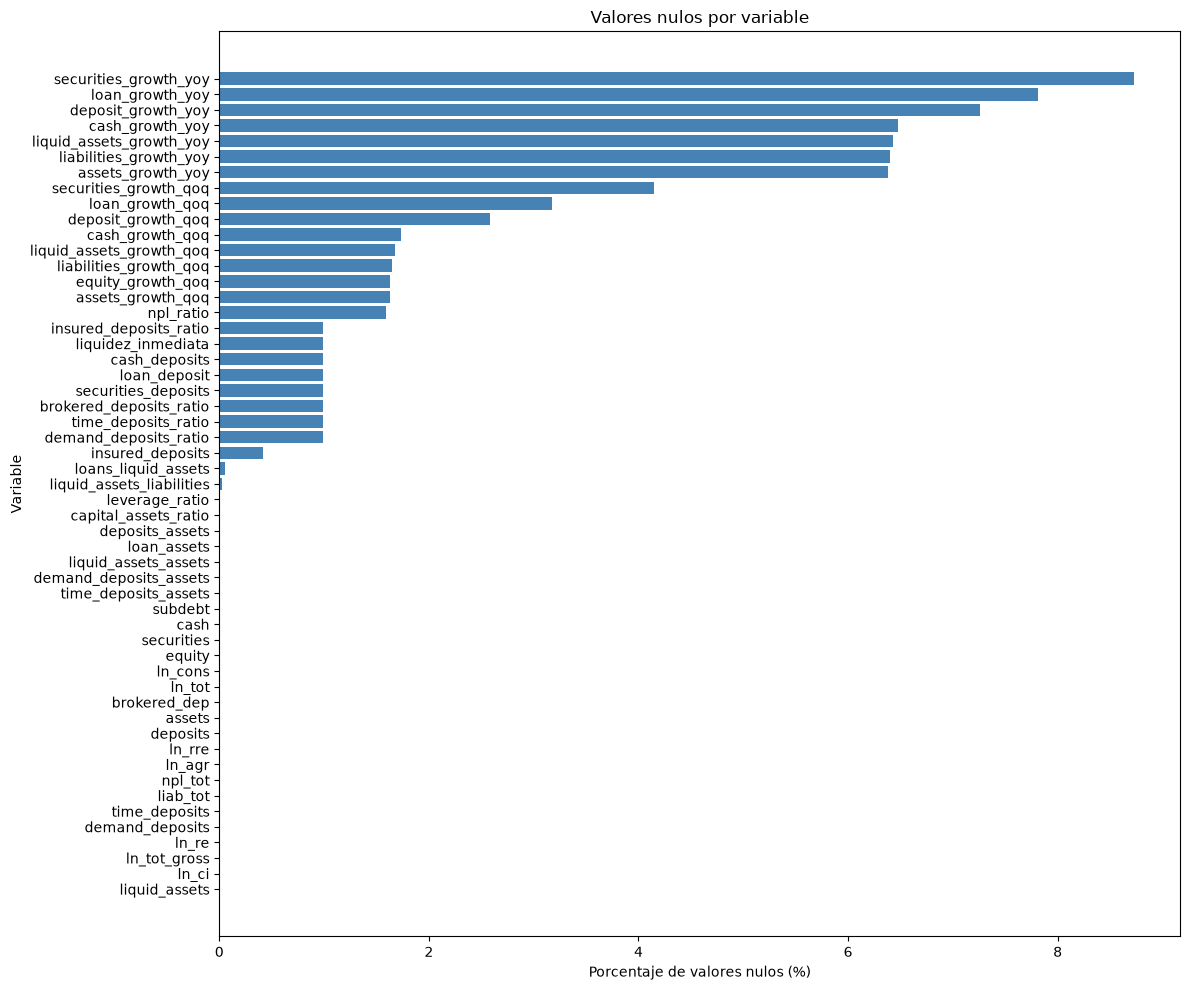

In [5]:
# ============================================
# PORCENTAJE DE NULOS - GRÁFICO
# ============================================

tabla_grafico = tabla_nulos[tabla_nulos["nulos"] > 0].copy()

plt.figure(figsize=(12, 10))
plt.barh(tabla_grafico["variable"], tabla_grafico["porcentaje_nulos"], color='steelblue')
plt.xlabel("Porcentaje de valores nulos (%)")
plt.ylabel("Variable")
plt.title("Valores nulos por variable")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Estadísticos Descriptivos

<div style="text-align: justify;">

Se calculan los principales estadísticos descriptivos de las variables numéricas con el propósito de caracterizar su comportamiento y conocer la distribución de los indicadores financieros relacionados con la liquidez bancaria. Se incluyen diferentes percentiles, desde el **1% hasta el 99,9%**, para obtener una visión más completa de la dispersión y detectar posibles valores extremos.

Este análisis es especialmente relevante en `LiquiditySense`, debido a que los indicadores financieros pueden presentar escalas y distribuciones muy diferentes entre instituciones y períodos. La evaluación de medidas como la media, mediana, desviación estándar y percentiles permitirá identificar diferencias de escala, asimetrías y observaciones potencialmente atípicas que posteriormente podrían influir en la construcción y desempeño del modelo de Machine Learning.

Los percentiles extremos, particularmente el **1%, 99% y 99,9%**, serán utilizados como referencia para evaluar la presencia de valores potencialmente extremos. Sin embargo, estos valores no serán considerados automáticamente como errores, ya que en el contexto financiero pueden representar situaciones reales asociadas a determinadas características o condiciones de las instituciones.

</div>


In [6]:
# ============================================
# ESTADÍSTICOS DESCRIPTIVOS
# ============================================

estadisticos = (
    base_liquidez
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999])
    .T
)

print("=" * 60)
print("ESTADÍSTICOS DESCRIPTIVOS")
print("=" * 60)
print(estadisticos)

ESTADÍSTICOS DESCRIPTIVOS
                                count                           mean  \
id_rssd                   698184.0000                    992519.3309   
date                           698184  2011-04-20 05:38:43.275239680   
assets                    698181.0000                   2214073.1638   
cash                      698181.0000                    220957.1273   
securities                698181.0000                    463036.3893   
deposits                  698181.0000                   1660488.1781   
demand_deposits           698181.0000                    282460.5880   
time_deposits             698181.0000                    273800.8972   
brokered_dep              698181.0000                    103293.5474   
insured_deposits          695262.0000                    740681.9046   
ln_tot                    698181.0000                   1200922.2174   
ln_tot_gross              698181.0000                   1201288.0718   
ln_re                     698181.0000 

### 5.1. Resultado del Estadístico

<div style="text-align: justify;">

Los estadísticos descriptivos muestran una **alta heterogeneidad entre las instituciones financieras**, especialmente en las variables de tamaño y en los indicadores de crecimiento. Por ejemplo, `assets` presenta una mediana de **152.623** frente a una media de **2.214.073**, evidenciando una distribución fuertemente asimétrica hacia valores elevados. Este comportamiento también se observa en depósitos, pasivos, activos líquidos y otras variables de magnitud.

En los indicadores de liquidez, la mediana de `liquidez_inmediata` es **0,3254**, mientras que `liquid_assets_assets` presenta una mediana de **0,2719**. Asimismo, `liquid_assets_liabilities` registra una mediana de **0,3054**. Estos valores proporcionan una referencia inicial sobre la posición de liquidez de las instituciones, aunque su interpretación deberá complementarse posteriormente con análisis de distribución y evolución temporal.

Los indicadores de crecimiento presentan una dispersión considerablemente mayor. Por ejemplo, `securities_growth_yoy` alcanza un **99,9% de 40,8545**, mientras que su máximo llega a **1.792.808,2**. Situaciones similares se observan en otros indicadores QoQ y YoY. Esto evidencia la presencia de **valores extremos y distribuciones altamente asimétricas**, que deberán investigarse antes de incorporarlos al modelo.

En consecuencia, los resultados indican que no es conveniente interpretar estos indicadores únicamente mediante la media. La **mediana y los percentiles** proporcionan una representación más robusta del comportamiento típico, mientras que los valores extremos deberán analizarse para determinar si corresponden a situaciones financieras reales o a posibles anomalías de los datos.

</div>


## 6. Valores Infinitos

<div style="text-align: justify;">

Se verifica la existencia de valores infinitos (`∞` y `-∞`) en las variables numéricas de la base, debido a que pueden generarse principalmente durante el cálculo de **ratios e indicadores de crecimiento**, por ejemplo, cuando una división utiliza valores cercanos a cero como denominador.

La identificación de estos valores es necesaria antes de continuar con el modelado, ya que los algoritmos de Machine Learning no siempre pueden procesarlos correctamente y podrían generar distorsiones en los estadísticos, transformaciones y resultados del modelo.

El análisis permite determinar si los indicadores construidos contienen valores infinitos y, en caso de existir, establecer posteriormente su tratamiento según el origen del problema.

</div>


In [7]:
# ============================================
# VALORES INFINITOS
# ============================================

variables_numericas = base_liquidez.select_dtypes(include=np.number).columns
infinitos = np.isinf(base_liquidez[variables_numericas]).sum()
estadisticos["infinitos"] = infinitos

print("=" * 60)
print("ESTADÍSTICOS DESCRIPTIVOS CON INFINITOS")
print("=" * 60)
print(estadisticos)

ESTADÍSTICOS DESCRIPTIVOS CON INFINITOS
                                count                           mean  \
id_rssd                   698184.0000                    992519.3309   
date                           698184  2011-04-20 05:38:43.275239680   
assets                    698181.0000                   2214073.1638   
cash                      698181.0000                    220957.1273   
securities                698181.0000                    463036.3893   
deposits                  698181.0000                   1660488.1781   
demand_deposits           698181.0000                    282460.5880   
time_deposits             698181.0000                    273800.8972   
brokered_dep              698181.0000                    103293.5474   
insured_deposits          695262.0000                    740681.9046   
ln_tot                    698181.0000                   1200922.2174   
ln_tot_gross              698181.0000                   1201288.0718   
ln_re                   

### 6.1. Resultado de los Valores Infinitos

<div style="text-align: justify;">

Los resultados muestran que **ninguna de las variables numéricas presenta valores infinitos**, registrándose `0` casos en todas las variables evaluadas. Por tanto, los valores extremos observados en algunos indicadores no corresponden a registros infinitos, sino a **valores numéricos finitos**, que deberán analizarse posteriormente como posibles valores atípicos.

Este resultado permite continuar con el análisis de calidad de datos sin requerir un tratamiento específico para valores `∞` o `-∞`. No obstante, la elevada dispersión observada en algunos indicadores de crecimiento y ratios deberá ser revisada en las siguientes etapas para determinar si responde a situaciones financieras reales o a observaciones potencialmente anómalas.

</div>


## 7. Definición de los 33 Indicadores Candidatos

<div style="text-align: justify;">

Se definen **33 indicadores candidatos de liquidez** para caracterizar la posición financiera de las instituciones y capturar diferentes dimensiones relacionadas con su capacidad de atender obligaciones, estructura de fondeo, nivel de apalancamiento y evolución de sus principales partidas financieras.

Los indicadores incluyen **ratios estructurales**, medidas de composición y calidad de la cartera, así como indicadores de crecimiento **interanual (YoY)** y **trimestral (QoQ)**. Esta combinación permite analizar tanto la situación de liquidez en un período determinado como los cambios que pueden anticipar un deterioro de la posición de liquidez.

Estos 33 indicadores se consideran variables candidatas para las siguientes etapas de `LiquiditySense`. Su inclusión inicial no implica que todos serán utilizados en el modelo, ya que posteriormente serán evaluados mediante análisis exploratorio, correlación, estabilidad temporal y desempeño predictivo.

</div>


In [8]:
# ============================================
# 33 INDICADORES CANDIDATOS DE LIQUIDEZ
# ============================================

variables_indicadores = [
    'liquidez_inmediata',
    'cash_deposits',
    'securities_deposits',
    'loan_deposit',
    'loan_assets',
    'deposits_assets',
    'brokered_deposits_ratio',
    'insured_deposits_ratio',
    'time_deposits_ratio',
    'demand_deposits_ratio',
    'leverage_ratio',
    'liquid_assets_liabilities',
    'capital_assets_ratio',
    'npl_ratio',
    'loan_growth_yoy',
    'deposit_growth_yoy',
    'cash_growth_yoy',
    'securities_growth_yoy',
    'liabilities_growth_yoy',
    'assets_growth_yoy',
    'liquid_assets_growth_yoy',
    'liquid_assets_assets',
    'time_deposits_assets',
    'demand_deposits_assets',
    'loans_liquid_assets',
    'deposit_growth_qoq',
    'cash_growth_qoq',
    'liquid_assets_growth_qoq',
    'loan_growth_qoq',
    'liabilities_growth_qoq',
    'assets_growth_qoq',
    'securities_growth_qoq',
    'equity_growth_qoq'
]

print(f"Número de indicadores candidatos: {len(variables_indicadores)}")

for i, variable in enumerate(variables_indicadores, 1):
    print(f"{i}. {variable}")

Número de indicadores candidatos: 33
1. liquidez_inmediata
2. cash_deposits
3. securities_deposits
4. loan_deposit
5. loan_assets
6. deposits_assets
7. brokered_deposits_ratio
8. insured_deposits_ratio
9. time_deposits_ratio
10. demand_deposits_ratio
11. leverage_ratio
12. liquid_assets_liabilities
13. capital_assets_ratio
14. npl_ratio
15. loan_growth_yoy
16. deposit_growth_yoy
17. cash_growth_yoy
18. securities_growth_yoy
19. liabilities_growth_yoy
20. assets_growth_yoy
21. liquid_assets_growth_yoy
22. liquid_assets_assets
23. time_deposits_assets
24. demand_deposits_assets
25. loans_liquid_assets
26. deposit_growth_qoq
27. cash_growth_qoq
28. liquid_assets_growth_qoq
29. loan_growth_qoq
30. liabilities_growth_qoq
31. assets_growth_qoq
32. securities_growth_qoq
33. equity_growth_qoq


## 8. Distribución de Variables Financieras Originales

In [9]:
# ============================================
# DISTRIBUCIÓN DE VARIABLES FINANCIERAS ORIGINALES
# ============================================

variables_originales = [
    'assets',
    'cash',
    'securities',
    'deposits',
    'liab_tot',
    'equity',
    'liquid_assets',
    'npl_tot'
]

print("Variables financieras originales:")
print(variables_originales)

Variables financieras originales:
['assets', 'cash', 'securities', 'deposits', 'liab_tot', 'equity', 'liquid_assets', 'npl_tot']


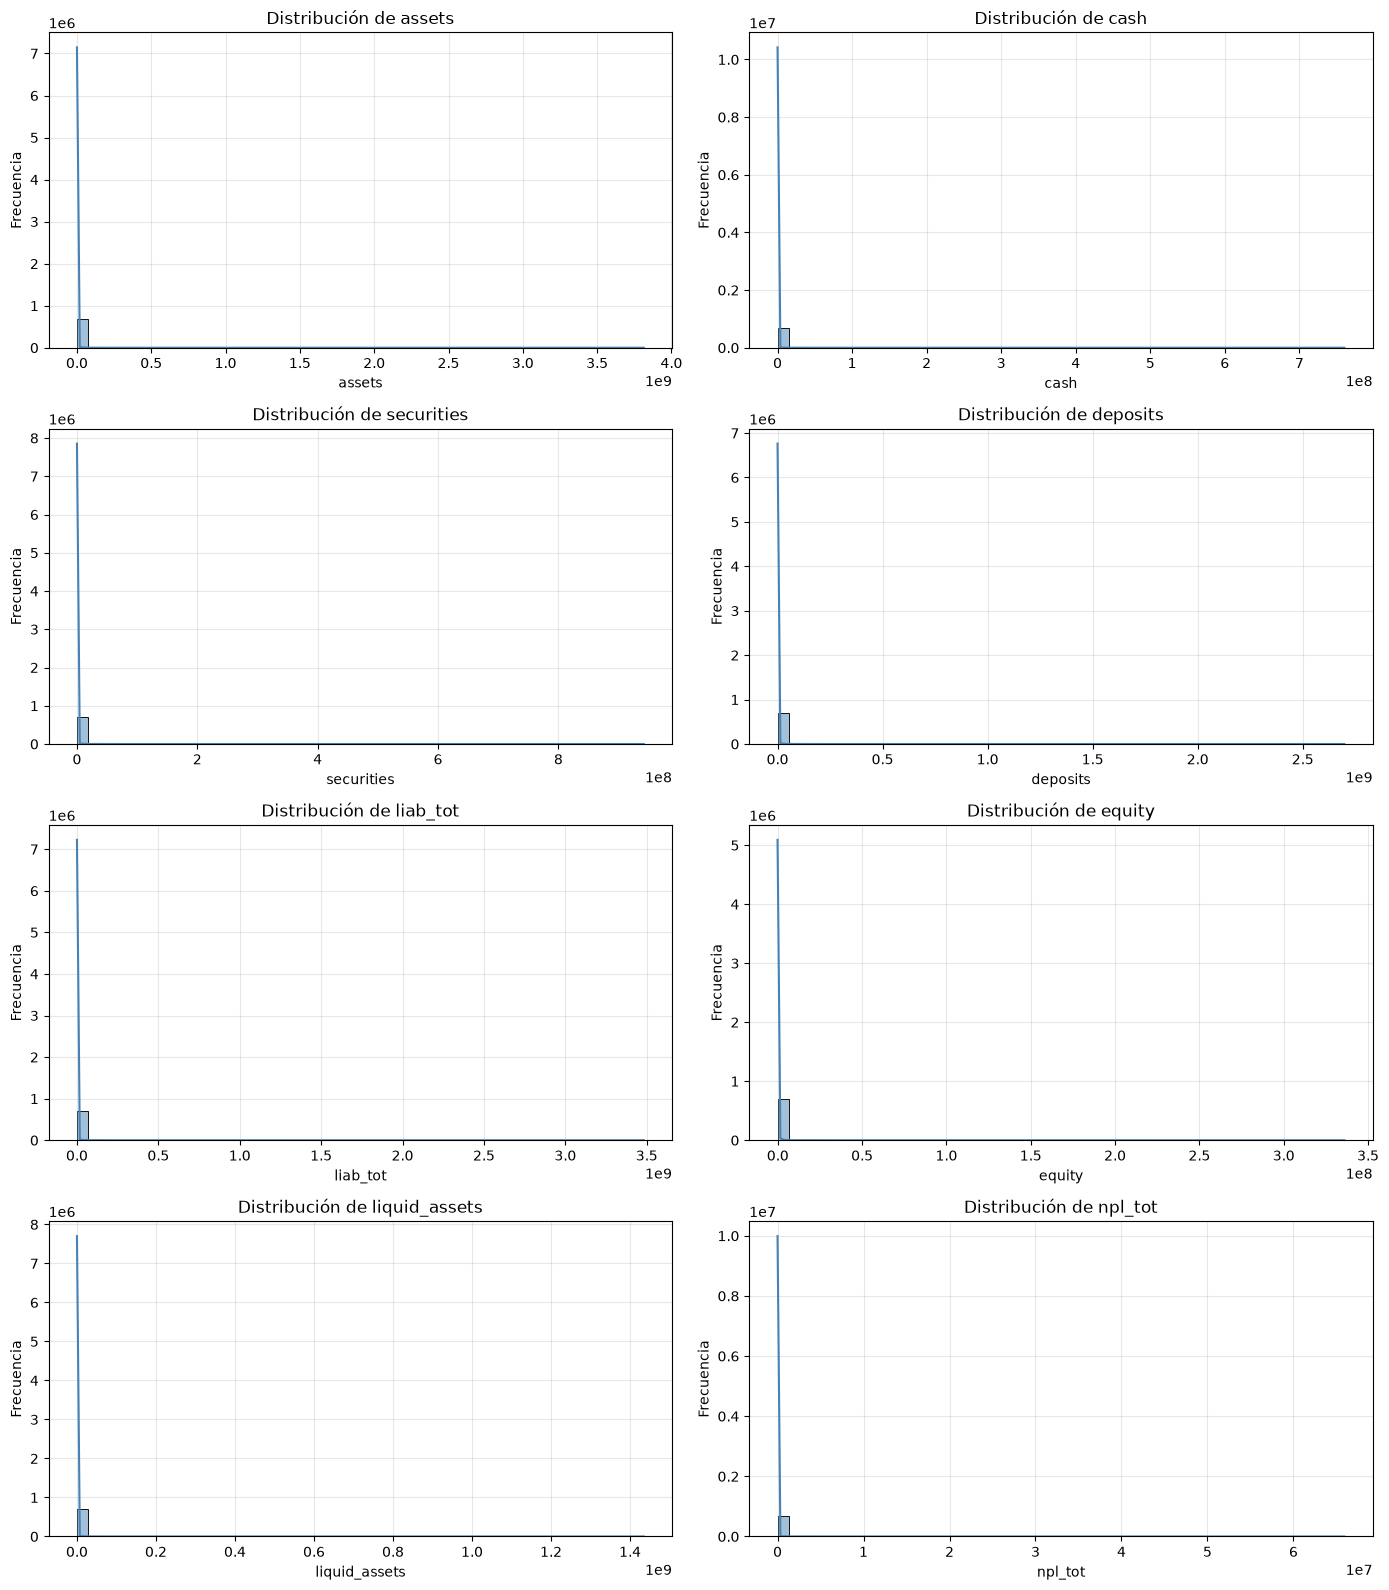

In [10]:
# ============================================
# DISTRIBUCIÓN DE VARIABLES ORIGINALES - GRÁFICO
# ============================================

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for ax, variable in zip(axes.flatten(), variables_originales):
    datos = base_liquidez[variable].dropna()
    sns.histplot(datos, bins=50, kde=True, ax=ax, color='steelblue')
    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Distribución de Variables Financieras Originales

<div style="text-align: justify;">

Se analiza la distribución de las principales **variables financieras originales** de las instituciones: activos, efectivo, valores, depósitos, pasivos, patrimonio, activos líquidos y cartera en mora. Estas variables representan la información financiera base sobre la cual se construyen los indicadores de liquidez.

El análisis de su distribución permitirá identificar diferencias de escala, asimetrías y posibles valores extremos entre instituciones de distinto tamaño, aspectos relevantes para comprender el comportamiento de la información antes de evaluar los indicadores candidatos y su utilización en el modelo de `LiquiditySense`.

</div>


In [11]:
# ============================================
# DISTRIBUCIÓN DE LOSINDICADORES
# ============================================

distribucion_indicadores = (
    base_liquidez[variables_indicadores]
    .describe(percentiles=[0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999])
    .T
)

print("=" * 60)
print("DISTRIBUCIÓN DE LOS 33 INDICADORES")
print("=" * 60)
print(distribucion_indicadores)

DISTRIBUCIÓN DE LOS 33 INDICADORES
                                count   mean       std       min    0.1%  \
liquidez_inmediata        691277.0000 2.0586  302.2416    0.0000  0.0111   
cash_deposits             691277.0000 0.9896  182.4399   -0.0031  0.0006   
securities_deposits       691277.0000 1.0690  223.7429    0.0000  0.0000   
loan_deposit              691277.0000 5.7241  453.0499    0.0000  0.0000   
loan_assets               698178.0000 0.6239    0.1790    0.0000  0.0000   
deposits_assets           698178.0000 0.8187    0.1303    0.0000  0.0000   
brokered_deposits_ratio   691277.0000 0.0312    0.1445    0.0000  0.0000   
insured_deposits_ratio    691255.0000 0.6620    0.1685    0.0000  0.0000   
time_deposits_ratio       691277.0000 0.4019    0.1834    0.0000  0.0000   
demand_deposits_ratio     691277.0000 0.1699    0.1206    0.0000  0.0000   
leverage_ratio            698178.0000 0.8775    0.1031    0.0000  0.0088   
liquid_assets_liabilities 698014.0000 0.9432   45.286

## 10. Asimetría de los Indicadores

<div style="text-align: justify;">

Se calcula el **coeficiente de asimetría (skewness)** de los 33 indicadores candidatos para evaluar el grado en que sus distribuciones se alejan de una distribución simétrica. Este análisis permite identificar indicadores con concentraciones de valores hacia uno de los extremos y detectar posibles colas largas.

La evaluación es relevante en `LiquiditySense`, debido a que los ratios de liquidez y, especialmente, los indicadores de crecimiento **YoY y QoQ**, pueden presentar distribuciones fuertemente asimétricas. Estas características pueden influir en el tratamiento de las variables y en su comportamiento durante las etapas posteriores de modelado.

Los indicadores se ordenan de mayor a menor asimetría para facilitar la identificación de las variables que presentan los comportamientos distributivos más extremos.

</div>


In [12]:
# ============================================
# ASIMETRÍA DE LOS 33 INDICADORES
# ============================================

asimetria = base_liquidez[variables_indicadores].skew().sort_values(ascending=False)

tabla_asimetria = asimetria.reset_index()
tabla_asimetria.columns = ["variable", "asimetria"]

print("=" * 60)
print("ASIMETRÍA DE LOS INDICADORES")
print("=" * 60)
print(tabla_asimetria)

ASIMETRÍA DE LOS INDICADORES
                     variable  asimetria
0           equity_growth_qoq   825.8891
1         loans_liquid_assets   767.5449
2       securities_growth_yoy   618.5264
3         securities_deposits   574.5244
4           assets_growth_qoq   526.3361
5               cash_deposits   514.2288
6             cash_growth_qoq   512.1945
7             loan_growth_qoq   473.0274
8      liabilities_growth_qoq   462.2997
9          deposit_growth_qoq   452.9332
10   liquid_assets_growth_yoy   425.3363
11      securities_growth_qoq   414.9959
12         liquidez_inmediata   399.1972
13     liabilities_growth_yoy   392.1083
14   liquid_assets_growth_qoq   390.1248
15          assets_growth_yoy   387.8365
16            loan_growth_yoy   320.3054
17    brokered_deposits_ratio   304.9196
18            cash_growth_yoy   283.6236
19         deposit_growth_yoy   235.7287
20  liquid_assets_liabilities   187.5254
21               loan_deposit   174.0884
22                  npl_rati

### 10.1. Resultado

<div style="text-align: justify;">

Los resultados muestran una **asimetría elevada en una parte importante de los indicadores**, principalmente en las variables de crecimiento y algunos ratios. Los valores más altos corresponden a `equity_growth_qoq` (825,8891), `loans_liquid_assets` (767,5449), `securities_growth_yoy` (618,5264) y `securities_deposits` (574,5244), evidenciando distribuciones con colas derechas muy pronunciadas.

En contraste, variables como `time_deposits_ratio` (0,2065), `time_deposits_assets` (0,0875) presentan una distribución cercana a la simetría, mientras que `insured_deposits_ratio`, `loan_assets`, `deposits_assets` y `leverage_ratio` presentan **asimetría negativa**.

La elevada asimetría confirma que varios indicadores no siguen una distribución aproximadamente normal y que existen observaciones extremas. Por ello, estos indicadores deberán ser revisados mediante percentiles y visualizaciones antes de definir su tratamiento para el modelo de `LiquiditySense`.

</div>


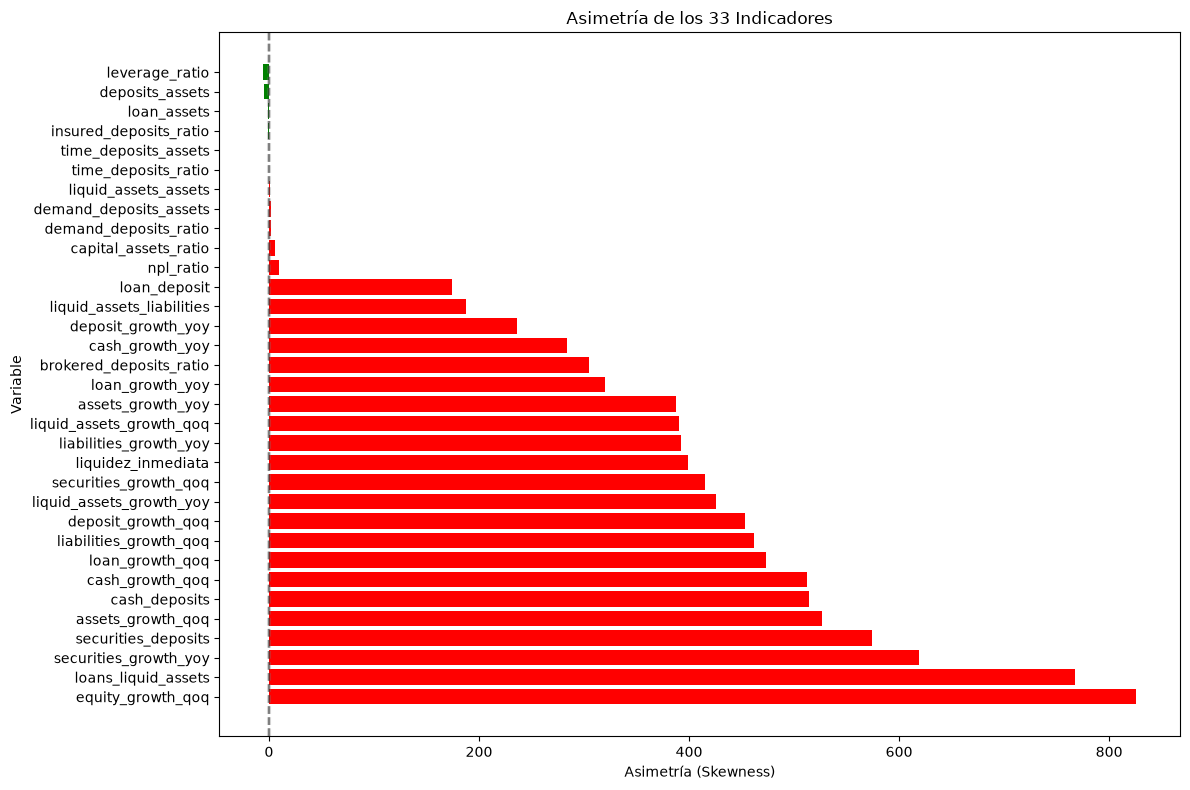

In [13]:
# Gráfico de asimetría
plt.figure(figsize=(12, 8))
colores = ['green' if x < 0 else 'red' if x > 1 else 'orange' for x in tabla_asimetria['asimetria']]
plt.barh(tabla_asimetria['variable'], tabla_asimetria['asimetria'], color=colores)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='gray', linestyle='--', alpha=0.3)
plt.axvline(x=-1, color='gray', linestyle='--', alpha=0.3)
plt.xlabel("Asimetría (Skewness)")
plt.ylabel("Variable")
plt.title("Asimetría de los 33 Indicadores")
plt.tight_layout()
plt.show()

## 11. Detección de Outliers mediante IQR

<div style="text-align: justify;">

Se aplica el criterio del **rango intercuartílico (IQR)** para identificar observaciones potencialmente atípicas en los 33 indicadores. Para cada variable se calculan el primer cuartil (Q1), tercer cuartil (Q3), IQR y los límites inferior y superior definidos como \(Q1 - 1,5\times IQR\) y \(Q3 + 1,5\times IQR\).

El porcentaje de outliers obtenido permite comparar la presencia de valores extremos entre indicadores, considerando que un valor identificado como outlier **no implica necesariamente un error**. En el contexto bancario puede representar situaciones reales asociadas al tamaño de una institución, cambios significativos en su estructura financiera o episodios particulares de liquidez.

Este análisis permitirá determinar posteriormente qué variables requieren un tratamiento específico, evitando eliminar automáticamente información potencialmente relevante para la identificación del riesgo de liquidez.

</div>


In [14]:
# ============================================
# DETECCIÓN DE OUTLIERS - CRITERIO IQR
#    33 INDICADORES
# ============================================

resultados_outliers = []

for variable in variables_indicadores:
    serie = pd.to_numeric(base_liquidez[variable], errors="coerce").dropna()

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mascara_outliers = (serie < limite_inferior) | (serie > limite_superior)
    cantidad_outliers = mascara_outliers.sum()
    porcentaje_outliers = cantidad_outliers / len(serie) * 100

    resultados_outliers.append({
        "variable": variable,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "outliers": cantidad_outliers,
        "porcentaje_outliers": porcentaje_outliers
    })

tabla_outliers = (
    pd.DataFrame(resultados_outliers)
    .sort_values("porcentaje_outliers", ascending=False)
    .reset_index(drop=True)
)

print("=" * 60)
print("OUTLIERS — CRITERIO IQR")
print("=" * 60)
print(tabla_outliers)

OUTLIERS — CRITERIO IQR
                     variable      Q1     Q3    IQR  limite_inferior  \
0     brokered_deposits_ratio  0.0000 0.0204 0.0204          -0.0306   
1       securities_growth_qoq -0.0460 0.0527 0.0987          -0.1940   
2           equity_growth_qoq -0.0021 0.0321 0.0342          -0.0534   
3       securities_growth_yoy -0.1072 0.1843 0.2915          -0.5445   
4    liquid_assets_growth_qoq -0.0548 0.0795 0.1343          -0.2563   
5      liabilities_growth_yoy -0.0004 0.1185 0.1190          -0.1789   
6           assets_growth_yoy  0.0037 0.1132 0.1095          -0.1605   
7          deposit_growth_yoy  0.0000 0.1188 0.1188          -0.1782   
8                   npl_ratio  0.0018 0.0164 0.0145          -0.0200   
9             cash_growth_yoy -0.1843 0.4378 0.6221          -1.1175   
10              cash_deposits  0.0348 0.1118 0.0771          -0.0808   
11   liquid_assets_growth_yoy -0.0824 0.2060 0.2884          -0.5149   
12     liabilities_growth_qoq -0.0119 0.

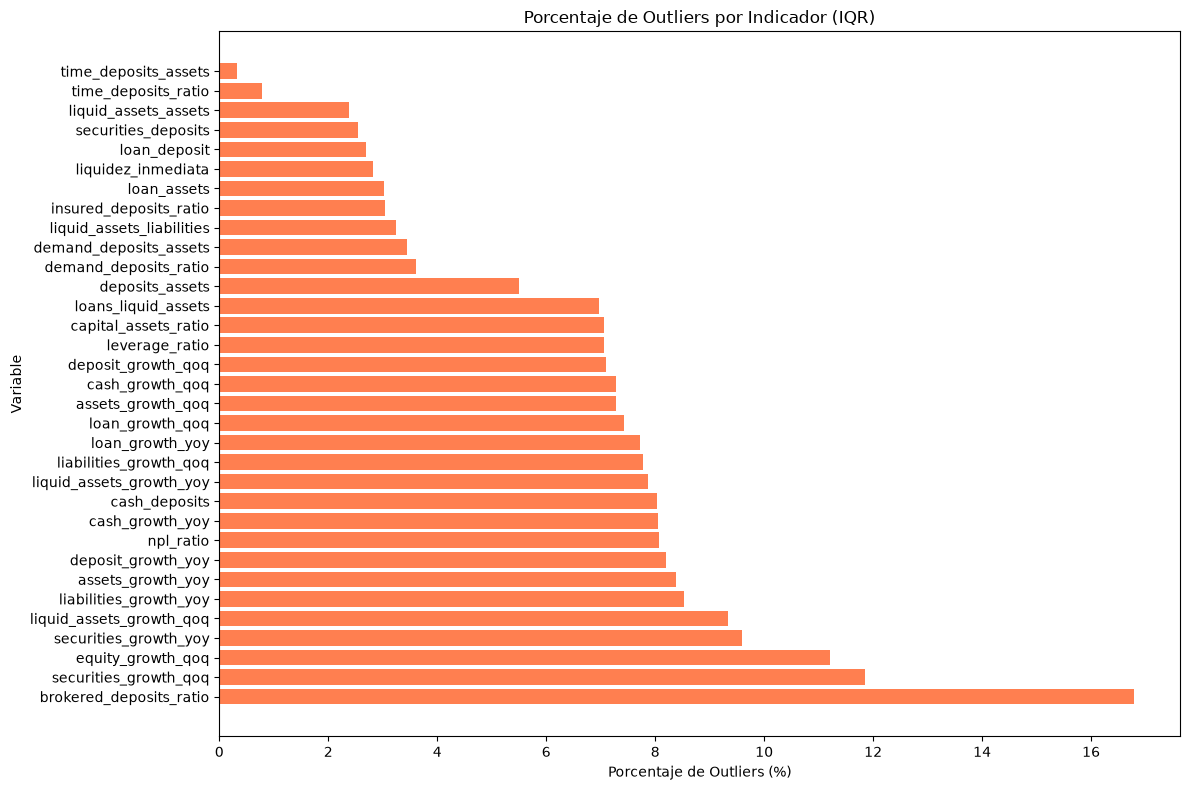

In [15]:
# Gráfico de porcentaje de outliers
plt.figure(figsize=(12, 8))
tabla_outliers_plot = tabla_outliers[tabla_outliers['porcentaje_outliers'] > 0].copy()
plt.barh(tabla_outliers_plot['variable'], tabla_outliers_plot['porcentaje_outliers'], color='coral')
plt.xlabel("Porcentaje de Outliers (%)")
plt.ylabel("Variable")
plt.title("Porcentaje de Outliers por Indicador (IQR)")
plt.tight_layout()
plt.show()

### 11.1. Resultado

<div style="text-align: justify;">

Se aplica el criterio **IQR (Rango Intercuartílico)** para identificar observaciones potencialmente atípicas en los 33 indicadores candidatos. Los resultados muestran que `brokered_deposits_ratio` presenta la mayor proporción de outliers, con **116.075 observaciones (16,7914%)**, seguido de `securities_growth_qoq` con **79.294 (11,8490%)**, `equity_growth_qoq` con **76.917 (11,1987%)**, `securities_growth_yoy` con **61.085 (9,5860%)** y `liquid_assets_growth_qoq` con **64.078 (9,3341%)**. También destacan `liabilities_growth_yoy` (8,5224%), `assets_growth_yoy` (8,3876%), `deposit_growth_yoy` (8,1950%), `npl_ratio` (8,0634%) y `cash_growth_yoy` (8,0457%). En contraste, `time_deposits_ratio` presenta **5.365 observaciones (0,7761%)** y `time_deposits_assets` **2.326 (0,3332%)**, siendo los indicadores con menor proporción de valores extremos.

La concentración de outliers en los indicadores de crecimiento **QoQ y YoY**, junto con algunos indicadores de estructura de fondeo y calidad de cartera, es consistente con la elevada asimetría observada previamente. Sin embargo, estos valores no se consideran automáticamente errores, ya que pueden representar cambios financieros reales entre instituciones y períodos. Por ello, para `LiquiditySense` se evitará una eliminación automática de los outliers y su tratamiento será definido posteriormente considerando su naturaleza financiera, estabilidad y posible aporte predictivo al modelo.

</div>


## 12. Valores Extremos

<div style="text-align: justify;">

Se realiza un análisis específico de los **valores extremos** de los 33 indicadores candidatos mediante estadísticos descriptivos ampliados, incorporando los percentiles **0,1%, 1%, 5%, 50%, 95%, 99% y 99,9%**. Esta evaluación permite examinar con mayor detalle el comportamiento de las colas de las distribuciones y complementar el análisis de asimetría y detección de outliers realizado previamente.

La revisión de estos percentiles resulta especialmente relevante para `LiquiditySense`, debido a que algunos indicadores financieros pueden presentar valores muy alejados de su comportamiento central como consecuencia de diferencias en el tamaño de las instituciones, cambios significativos entre períodos o situaciones financieras particulares. En este sentido, los percentiles extremos permiten identificar la magnitud y dirección de estas observaciones sin asumir automáticamente que corresponden a errores de datos.

Este análisis permitirá determinar qué indicadores presentan una mayor concentración de valores extremos y evaluar posteriormente si requieren algún tratamiento específico, como transformaciones, winsorización o técnicas robustas, manteniendo aquellos valores que puedan contener información relevante para la identificación del deterioro del riesgo de liquidez.

</div>


In [16]:
# ============================================
# ANÁLISIS DE VALORES EXTREMOS
# ============================================

estadisticos_extremos = (
    base_liquidez[variables_indicadores]
    .describe(percentiles=[0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999])
    .T
)

print("=" * 60)
print("VALORES EXTREMOS")
print("=" * 60)
print(estadisticos_extremos)

VALORES EXTREMOS
                                count   mean       std       min    0.1%  \
liquidez_inmediata        691277.0000 2.0586  302.2416    0.0000  0.0111   
cash_deposits             691277.0000 0.9896  182.4399   -0.0031  0.0006   
securities_deposits       691277.0000 1.0690  223.7429    0.0000  0.0000   
loan_deposit              691277.0000 5.7241  453.0499    0.0000  0.0000   
loan_assets               698178.0000 0.6239    0.1790    0.0000  0.0000   
deposits_assets           698178.0000 0.8187    0.1303    0.0000  0.0000   
brokered_deposits_ratio   691277.0000 0.0312    0.1445    0.0000  0.0000   
insured_deposits_ratio    691255.0000 0.6620    0.1685    0.0000  0.0000   
time_deposits_ratio       691277.0000 0.4019    0.1834    0.0000  0.0000   
demand_deposits_ratio     691277.0000 0.1699    0.1206    0.0000  0.0000   
leverage_ratio            698178.0000 0.8775    0.1031    0.0000  0.0088   
liquid_assets_liabilities 698014.0000 0.9432   45.2866    0.0000  0.002

### 12.1. Resultados

<div style="text-align: justify;">

El análisis de los percentiles extremos evidencia una **alta dispersión en determinados indicadores de liquidez y, especialmente, en las variables de crecimiento**. En los ratios de liquidez, `liquidez_inmediata` presenta una mediana de **0,3254**, mientras que su percentil 99,9% alcanza **108,4826** y su máximo **165.143**. De forma similar, `cash_deposits` pasa de una mediana de **0,0579** a **46,3866** en el percentil 99,9%, mientras que `securities_deposits` alcanza **29,2032** y `loan_deposit` **28,4378** en dicho percentil.

En los indicadores estructurales se observa un comportamiento más estable. Por ejemplo, `loan_assets` presenta una mediana de **0,6547** y un percentil 99,9% de **0,9663**, mientras que `deposits_assets` alcanza una mediana de **0,8488** y un percentil 99,9% de **0,9721**. En contraste, `loans_liquid_assets` presenta una mediana de **2,4030**, pero alcanza **132,3439** en el percentil 99,9% y un máximo de **1.725.036**, evidenciando una fuerte presencia de valores extremos.

Los indicadores de crecimiento presentan la mayor variabilidad. `securities_growth_yoy` alcanza **40,8545** en el percentil 99,9% y un máximo de **1.792.808,2**; `deposit_growth_yoy` llega a **11,3623** y **54.258**, respectivamente; mientras que `loan_growth_yoy` alcanza **14,4047** en el percentil 99,9% y **29.955,3333** como máximo. En los indicadores QoQ también se observan valores extremos, destacando `deposit_growth_qoq` con **2,6978** en el percentil 99,9% y un máximo de **34.706,298**, así como `equity_growth_qoq`, cuyo máximo alcanza **10.257**.

Estos resultados confirman que los valores extremos se concentran principalmente en **ratios con denominadores pequeños y variables de crecimiento**, donde cambios relativamente reducidos en las magnitudes base pueden generar variaciones porcentuales muy elevadas. Por ello, estos valores no serán considerados automáticamente como errores ni eliminados de forma indiscriminada. Su tratamiento deberá evaluarse posteriormente considerando su origen financiero, estabilidad temporal y posible aporte predictivo al modelo `LiquiditySense`.

</div>


## 13. Evaluación Temporal

<div style="text-align: justify;">

Para evaluar la evolución temporal del riesgo de liquidez se seleccionan seis indicadores: `liquidez_inmediata`, `cash_deposits`, `securities_deposits`, `loan_deposit`, `liquid_assets_assets` y `npl_ratio`. Estos indicadores permiten analizar diferentes dimensiones de la posición financiera de las instituciones, considerando la disponibilidad de recursos líquidos, la estructura de los depósitos, la relación entre cartera y depósitos, la proporción de activos líquidos y la calidad de la cartera.

La selección busca identificar cambios, tendencias y posibles períodos de deterioro a lo largo del tiempo. Este análisis es relevante para `LiquiditySense`, debido a que la evolución de los indicadores puede proporcionar información adicional sobre cambios en la posición de liquidez que no necesariamente son identificables mediante el análisis de un único período.

Los indicadores seleccionados serán utilizados en las siguientes visualizaciones para analizar su comportamiento temporal y determinar la existencia de patrones relevantes para las etapas posteriores del proyecto.

</div>


In [17]:
# ============================================
# EVOLUCIÓN TEMPORAL
# ============================================

variables_temporales = [
    'liquidez_inmediata',
    'cash_deposits',
    'securities_deposits',
    'loan_deposit',
    'liquid_assets_assets',
    'npl_ratio'
]

print("Indicadores seleccionados para análisis temporal:")
for variable in variables_temporales:
    print(f"  - {variable}")

Indicadores seleccionados para análisis temporal:
  - liquidez_inmediata
  - cash_deposits
  - securities_deposits
  - loan_deposit
  - liquid_assets_assets
  - npl_ratio


In [18]:
# ============================================
# MEDIANA DE INDICADORES POR FECHA
# ============================================

evolucion_temporal = (
    base_liquidez
    .groupby("date")[variables_temporales]
    .median()
    .reset_index()
)

print(f"Registros temporales: {len(evolucion_temporal)}")
print(f"Fecha inicial: {evolucion_temporal['date'].min()}")
print(f"Fecha final: {evolucion_temporal['date'].max()}")

Registros temporales: 104
Fecha inicial: 2000-01-01 00:00:00
Fecha final: 2025-10-01 00:00:00


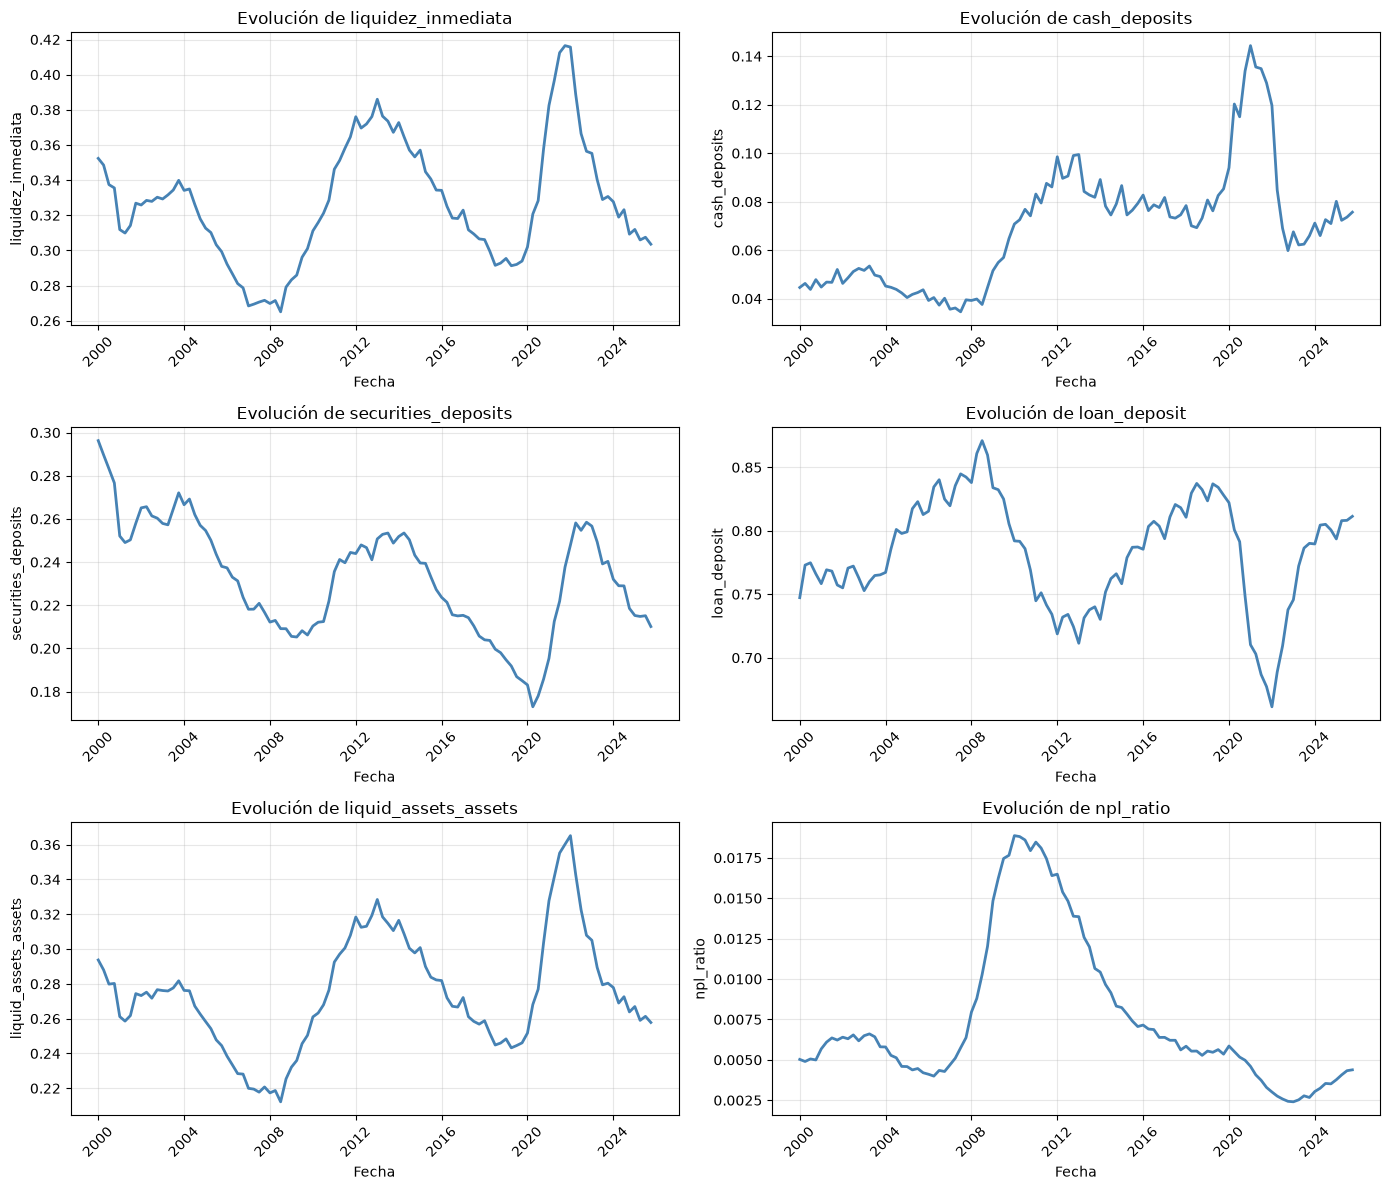

In [19]:
# Gráfico de evolución temporal
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, variable in enumerate(variables_temporales):
    ax = axes[i]
    ax.plot(evolucion_temporal['date'], evolucion_temporal[variable], linewidth=2, color='steelblue')
    ax.set_title(f"Evolución de {variable}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(variable)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 14. Análisis de Correlación

<div style="text-align: justify;">

Se calcula la **matriz de correlación de Pearson** para los 33 indicadores candidatos, con el objetivo de evaluar la relación lineal existente entre las variables. Este análisis permite identificar indicadores que presentan comportamientos similares y detectar posibles relaciones fuertes entre variables que podrían aportar información redundante al modelo.

La evaluación de correlaciones es relevante para `LiquiditySense`, debido a que varios indicadores se construyen a partir de componentes financieros relacionados. Por ejemplo, diferentes ratios pueden compartir denominadores o variables base, mientras que los indicadores de crecimiento pueden presentar relaciones entre sí debido a que miden la evolución de partidas financieras relacionadas.

La matriz obtenida será utilizada para identificar **pares o grupos de variables con alta correlación**, evaluar posibles problemas de redundancia y apoyar posteriormente la selección de variables. No obstante, una correlación elevada no implica causalidad ni será utilizada por sí sola para descartar variables, ya que la decisión final deberá considerar también su estabilidad temporal, interpretación financiera y capacidad predictiva.

</div>


In [20]:
# ============================================
# 7.2 MATRIZ DE CORRELACIÓN - TODOS LOS INDICADORES
# ============================================

matriz_corr = base_liquidez[variables_indicadores].corr(method="pearson")

print("=" * 60)
print("MATRIZ DE CORRELACIÓN — 33 INDICADORES")
print("=" * 60)
print(matriz_corr)

MATRIZ DE CORRELACIÓN — 33 INDICADORES
                           liquidez_inmediata  cash_deposits  \
liquidez_inmediata                     1.0000         0.6762   
cash_deposits                          0.6762         1.0000   
securities_deposits                    0.7995         0.0981   
loan_deposit                           0.0350         0.0444   
loan_assets                           -0.0194        -0.0156   
deposits_assets                       -0.0456        -0.0399   
brokered_deposits_ratio               -0.0012        -0.0010   
insured_deposits_ratio                 0.0010         0.0020   
time_deposits_ratio                   -0.0041        -0.0027   
demand_deposits_ratio                  0.0235         0.0190   
leverage_ratio                        -0.0403        -0.0379   
liquid_assets_liabilities              0.0195         0.0265   
capital_assets_ratio                   0.0403         0.0379   
npl_ratio                              0.0025         0.0031   
l

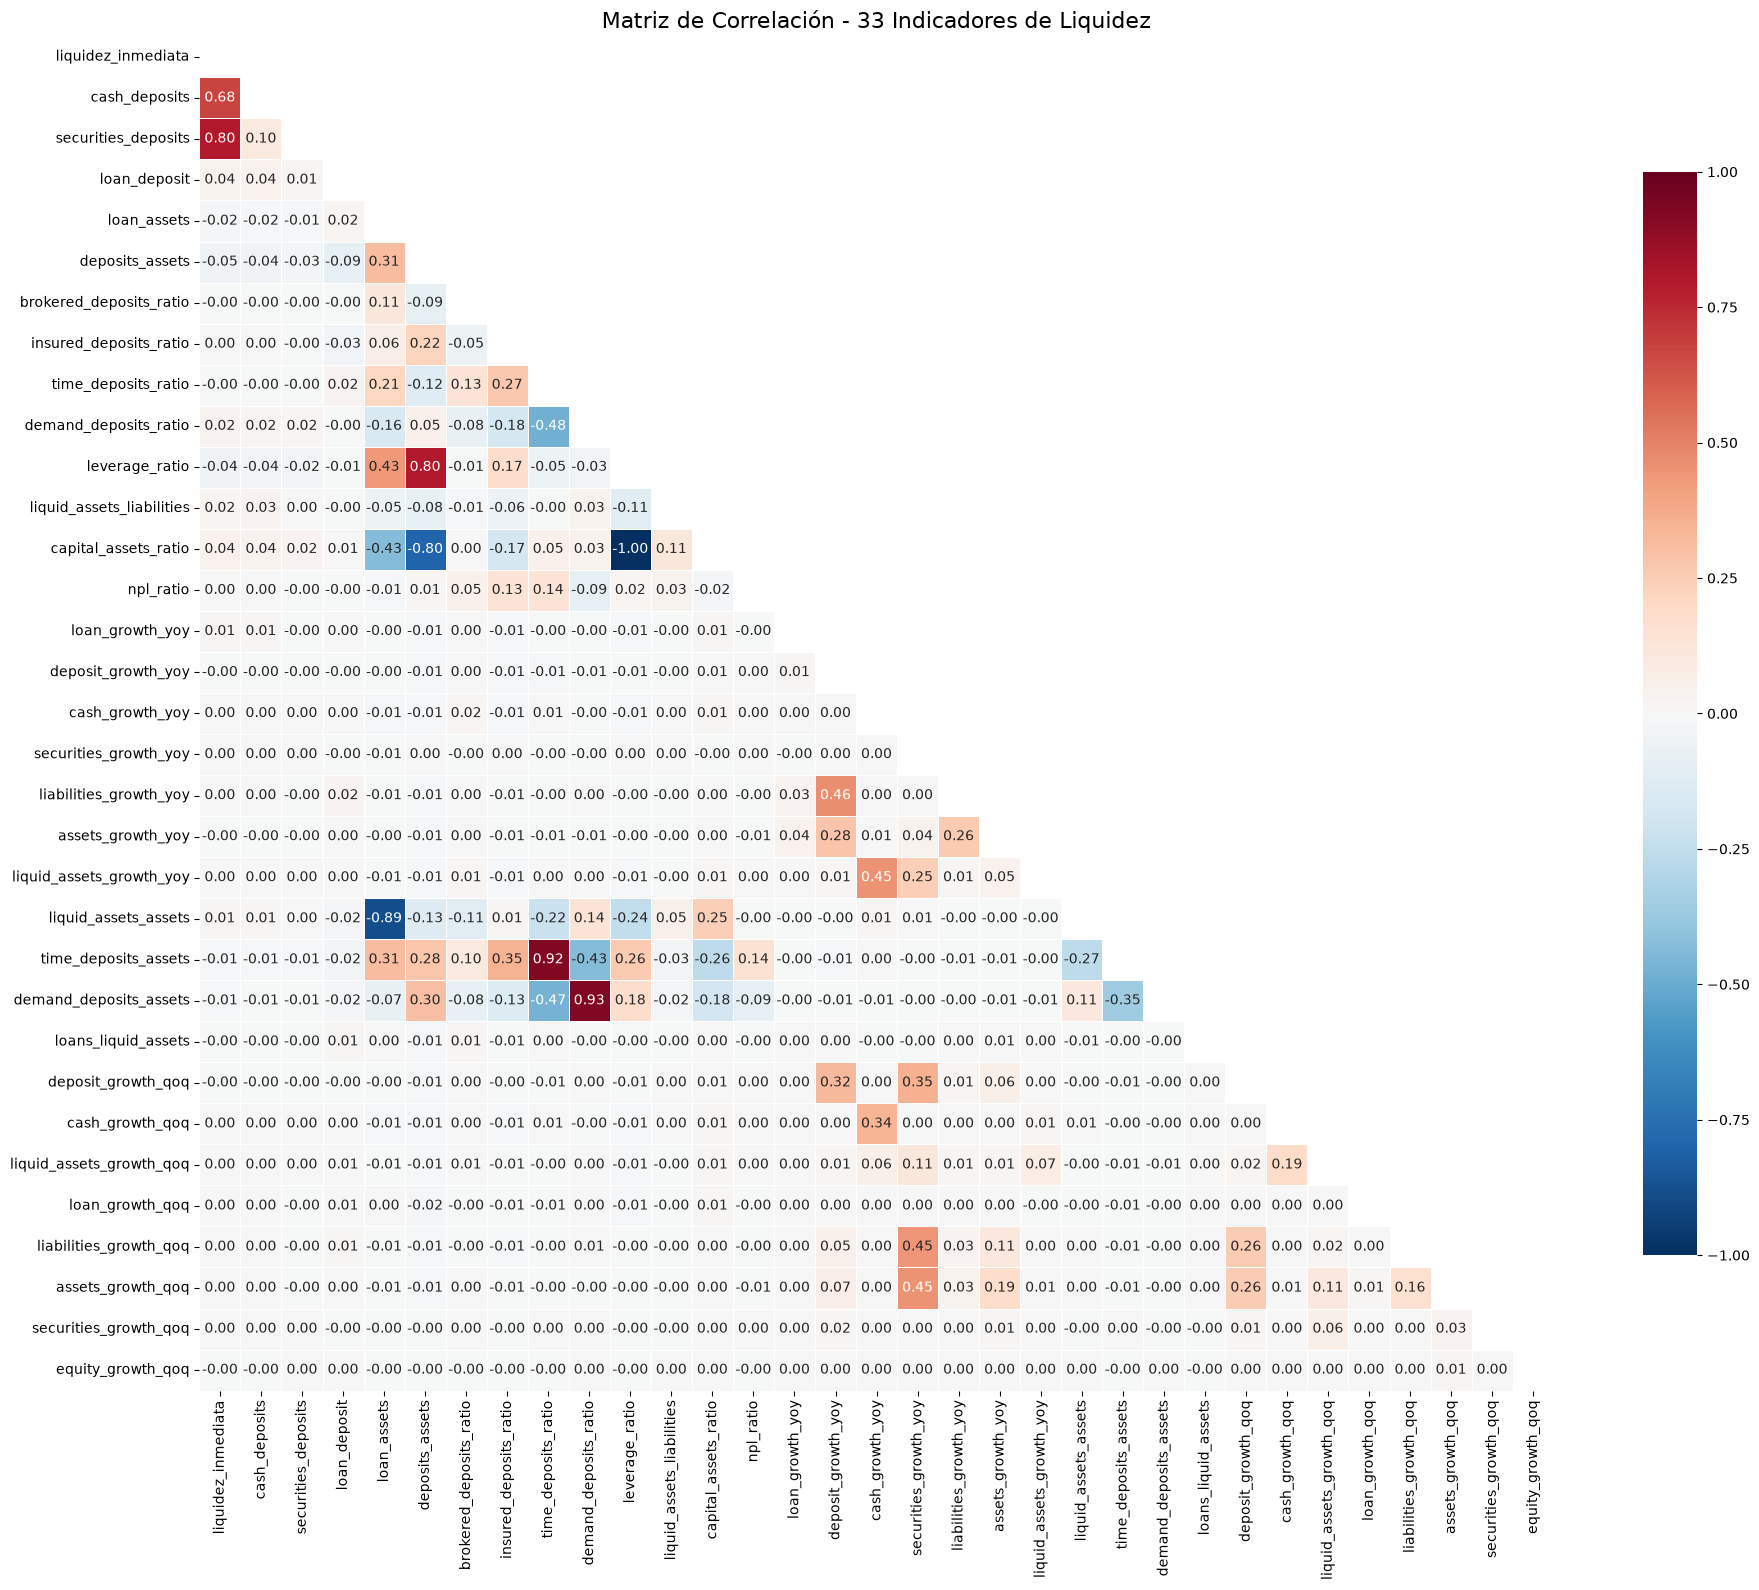

In [21]:
# Heatmap de correlación
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(
    matriz_corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de Correlación - 33 Indicadores de Liquidez", fontsize=16)
plt.tight_layout()
plt.show()


<div style="text-align: justify;">

### 14.1. Correlaciones más elevadas

La matriz de correlación de Pearson permite identificar el grado de relación lineal entre los **33 indicadores candidatos**. Para facilitar la interpretación, se presentan a continuación las relaciones más relevantes identificadas en la matriz.


| Indicador 1             | Indicador 2              | Correlación |
| ----------------------- | ------------------------ | ----------: |
| `leverage_ratio`        | `capital_assets_ratio`   | **-0,9999** |
| `demand_deposits_ratio` | `demand_deposits_assets` |  **0,9282** |
| `time_deposits_ratio`   | `time_deposits_assets`   |  **0,9243** |
| `loan_assets`           | `liquid_assets_assets`   | **-0,8887** |
| `deposits_assets`       | `capital_assets_ratio`   | **-0,8009** |
| `deposits_assets`       | `leverage_ratio`         |  **0,8014** |
| `liquidez_inmediata`    | `securities_deposits`    |  **0,7995** |
| `liquidez_inmediata`    | `cash_deposits`          |  **0,6762** |

Las correlaciones más elevadas se concentran principalmente entre indicadores estructurales que utilizan componentes financieros relacionados o que representan dimensiones similares. Destaca la relación prácticamente perfecta entre `leverage_ratio` y `capital_assets_ratio` (**-0,9999**), así como las relaciones superiores a **0,90** entre `time_deposits_ratio` y `time_deposits_assets`, y entre `demand_deposits_ratio` y `demand_deposits_assets`. Asimismo, `loan_assets` presenta una correlación negativa elevada con `liquid_assets_assets` (**-0,8887**), mientras que `deposits_assets` mantiene relaciones fuertes con los indicadores de apalancamiento.

### 14.2. Correlaciones moderadas relevantes

| Indicador 1             | Indicador 2                | Correlación |
| ----------------------- | -------------------------- | ----------: |
| `deposit_growth_yoy`    | `liabilities_growth_yoy`   |  **0,4621** |
| `securities_growth_yoy` | `assets_growth_qoq`        |  **0,4500** |
| `cash_growth_yoy`       | `liquid_assets_growth_yoy` |  **0,4487** |
| `securities_growth_yoy` | `liabilities_growth_qoq`   |  **0,4451** |
| `deposit_growth_qoq`    | `deposit_growth_yoy`       |  **0,3249** |
| `cash_growth_qoq`       | `cash_growth_yoy`          |  **0,3401** |

En los indicadores de crecimiento se observan relaciones de magnitud moderada. La mayor corresponde a `deposit_growth_yoy` con `liabilities_growth_yoy` (**0,4621**), seguida de `securities_growth_yoy` con `assets_growth_qoq` (**0,4500**) y `cash_growth_yoy` con `liquid_assets_growth_yoy` (**0,4487**). Estas relaciones indican que determinados movimientos de las partidas financieras evolucionan conjuntamente, aunque sin alcanzar los niveles de asociación observados entre algunos indicadores estructurales.

### 14.3. Interpretación para la selección de variables

Los resultados evidencian la existencia de **redundancia potencial entre determinados indicadores**, especialmente aquellos construidos a partir de componentes financieros comunes. Las correlaciones cercanas a ±1, como la observada entre `leverage_ratio` y `capital_assets_ratio`, indican que ambas variables contienen información prácticamente equivalente desde el punto de vista lineal.

Por otro lado, la mayoría de las correlaciones entre los indicadores estructurales y los indicadores de crecimiento presentan valores relativamente bajos, lo que sugiere que estos grupos capturan **dimensiones diferentes del comportamiento financiero**.

Esta evidencia será considerada en la etapa posterior de selección de variables de `LiquiditySense`. Sin embargo, una correlación elevada no será utilizada como criterio único para eliminar variables, debido a que la selección deberá considerar también la interpretación financiera, estabilidad temporal y capacidad predictiva de cada indicador.

</div>


## 15. Correlaciones Fuertes

<div style="text-align: justify;">

A partir de la matriz de correlación se ordenan los pares de variables según el **valor absoluto de su correlación**, considerando tanto asociaciones positivas como negativas. Este procedimiento permite identificar las relaciones lineales más fuertes entre los 33 indicadores candidatos y detectar posibles casos de redundancia de información.

### 15.1. Principales correlaciones

| N.º | Indicador 1             | Indicador 2              | Correlación |
| :-: | ----------------------- | ------------------------ | ----------: |
|  1  | `leverage_ratio`        | `capital_assets_ratio`   | **-0,9999** |
|  2  | `demand_deposits_ratio` | `demand_deposits_assets` |  **0,9282** |
|  3  | `time_deposits_ratio`   | `time_deposits_assets`   |  **0,9243** |
|  4  | `loan_assets`           | `liquid_assets_assets`   | **-0,8887** |
|  5  | `deposits_assets`       | `leverage_ratio`         |  **0,8014** |
|  6  | `deposits_assets`       | `capital_assets_ratio`   | **-0,8009** |
|  7  | `liquidez_inmediata`    | `securities_deposits`    |  **0,7995** |
|  8  | `liquidez_inmediata`    | `cash_deposits`          |  **0,6762** |

Las correlaciones más elevadas corresponden principalmente a indicadores estructurales que comparten componentes financieros o representan conceptos estrechamente relacionados. Destaca la relación prácticamente perfecta e inversa entre `leverage_ratio` y `capital_assets_ratio` (**-0,9999**), mientras que `demand_deposits_ratio` con `demand_deposits_assets` (**0,9282**) y `time_deposits_ratio` con `time_deposits_assets` (**0,9243**) presentan asociaciones positivas muy elevadas.

Asimismo, `loan_assets` y `liquid_assets_assets` presentan una correlación negativa de **-0,8887**, mientras que `deposits_assets` mantiene relaciones elevadas con `leverage_ratio` (**0,8014**) y `capital_assets_ratio` (**-0,8009**). En los indicadores de liquidez, `liquidez_inmediata` presenta relaciones importantes con `securities_deposits` (**0,7995**) y `cash_deposits` (**0,6762**).

### 15.2. Consideración para `LiquiditySense`

Las correlaciones identificadas evidencian la existencia de **posible redundancia entre determinados indicadores**, especialmente en aquellos pares cuya correlación se aproxima a ±1. Esta situación deberá ser considerada en la selección posterior de variables, debido a que mantener simultáneamente indicadores que contienen información prácticamente equivalente podría aportar poca información adicional al modelo.

Sin embargo, la correlación no será utilizada como único criterio de eliminación. La selección definitiva deberá considerar conjuntamente la **interpretación financiera, estabilidad temporal, comportamiento de los valores extremos y capacidad predictiva** de cada indicador dentro de `LiquiditySense`.

</div>



In [22]:
# ============================================
# CORRELACIONES FUERTES
# ============================================

corr_pares = (
    matriz_corr
    .where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pares.columns = ["variable_1", "variable_2", "correlacion"]
corr_pares["correlacion_abs"] = corr_pares["correlacion"].abs()
corr_pares = corr_pares.sort_values("correlacion_abs", ascending=False).reset_index(drop=True)

print("=" * 60)
print("CORRELACIONES MÁS FUERTES")
print("=" * 60)
print(corr_pares.head(30))

CORRELACIONES MÁS FUERTES
                variable_1                variable_2  correlacion  \
0           leverage_ratio      capital_assets_ratio      -0.9999   
1    demand_deposits_ratio    demand_deposits_assets       0.9282   
2      time_deposits_ratio      time_deposits_assets       0.9243   
3              loan_assets      liquid_assets_assets      -0.8887   
4          deposits_assets            leverage_ratio       0.8014   
5          deposits_assets      capital_assets_ratio      -0.8009   
6       liquidez_inmediata       securities_deposits       0.7995   
7       liquidez_inmediata             cash_deposits       0.6762   
8      time_deposits_ratio     demand_deposits_ratio      -0.4777   
9      time_deposits_ratio    demand_deposits_assets      -0.4692   
10      deposit_growth_yoy    liabilities_growth_yoy       0.4621   
11   securities_growth_yoy         assets_growth_qoq       0.4500   
12         cash_growth_yoy  liquid_assets_growth_yoy       0.4487   
13   sec

## 16. Identificación de Redundancia

<div style="text-align: justify;">

Para identificar posibles variables redundantes se establece como criterio una **correlación absoluta igual o superior a 0,80**. Este umbral permite detectar pares de indicadores con una asociación lineal elevada, que podrían estar aportando información similar al modelo. A partir de este criterio se obtienen los siguientes pares:

### 16.1. Pares de indicadores altamente correlacionados

| N.º | Indicador 1             | Indicador 2              | Correlación |
| :-: | ----------------------- | ------------------------ | ----------: |
|  1  | `leverage_ratio`        | `capital_assets_ratio`   | **-0,9999** |
|  2  | `demand_deposits_ratio` | `demand_deposits_assets` |  **0,9282** |
|  3  | `time_deposits_ratio`   | `time_deposits_assets`   |  **0,9243** |
|  4  | `deposits_assets`       | `leverage_ratio`         |  **0,8014** |
|  5  | `loan_assets`           | `liquid_assets_assets`   | **-0,8887** |
|  6  | `deposits_assets`       | `capital_assets_ratio`   | **-0,8009** |

Los resultados muestran **seis pares de indicadores** con una correlación absoluta igual o superior a **0,80**. La relación más elevada corresponde a `leverage_ratio` y `capital_assets_ratio`, con **-0,9999**, lo que evidencia una asociación lineal prácticamente perfecta e inversa. También destacan `demand_deposits_ratio` con `demand_deposits_assets` (**0,9282**) y `time_deposits_ratio` con `time_deposits_assets` (**0,9243**).

Estas relaciones sugieren que determinados indicadores pueden presentar **redundancia de información**, especialmente cuando se construyen a partir de componentes financieros similares. Por ejemplo, los indicadores relacionados con la estructura de depósitos presentan asociaciones elevadas entre sí, mientras que `leverage_ratio` y `capital_assets_ratio` muestran un comportamiento prácticamente equivalente desde el punto de vista lineal.

La identificación de estos pares **no implica la eliminación automática de ninguna variable**. En `LiquiditySense`, cada indicador será evaluado considerando adicionalmente su interpretación financiera, estabilidad temporal y aporte predictivo. Este análisis servirá como criterio de apoyo para evitar incorporar simultáneamente variables que proporcionen información prácticamente duplicada y favorecer una representación más eficiente de los factores asociados al riesgo de liquidez.

</div>


In [23]:
# ============================================
# IDENTIFICACIÓN DE VARIABLES REDUNDANTES
# ============================================

umbral_correlacion = 0.80

pares_altamente_correlacionados = (
    corr_pares[corr_pares["correlacion_abs"] >= umbral_correlacion]
    .copy()
)

print("=" * 60)
print(f"PARES CON |CORRELACIÓN| >= {umbral_correlacion}")
print("=" * 60)
print(pares_altamente_correlacionados)

PARES CON |CORRELACIÓN| >= 0.8
              variable_1              variable_2  correlacion  correlacion_abs
0         leverage_ratio    capital_assets_ratio      -0.9999           0.9999
1  demand_deposits_ratio  demand_deposits_assets       0.9282           0.9282
2    time_deposits_ratio    time_deposits_assets       0.9243           0.9243
3            loan_assets    liquid_assets_assets      -0.8887           0.8887
4        deposits_assets          leverage_ratio       0.8014           0.8014
5        deposits_assets    capital_assets_ratio      -0.8009           0.8009


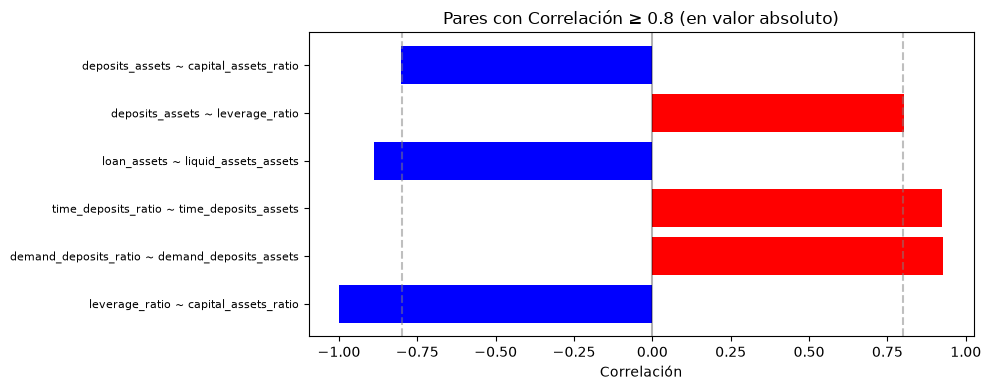

In [24]:
# Visualización de pares altamente correlacionados
if len(pares_altamente_correlacionados) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(pares_altamente_correlacionados) * 0.3)))
    colores = ['red' if x > 0 else 'blue' for x in pares_altamente_correlacionados['correlacion']]
    etiquetas = [f"{a} ~ {b}" for a, b in zip(pares_altamente_correlacionados['variable_1'], 
                                              pares_altamente_correlacionados['variable_2'])]
    y_pos = range(len(etiquetas))
    ax.barh(y_pos, pares_altamente_correlacionados['correlacion'], color=colores)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(etiquetas, fontsize=8)
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    ax.axvline(x=umbral_correlacion, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=-umbral_correlacion, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel("Correlación")
    ax.set_title(f"Pares con Correlación ≥ {umbral_correlacion} (en valor absoluto)")
    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontraron pares con correlación ≥ {umbral_correlacion}")

## 17. Datos Faltantes en Indicadores

<div style="text-align: justify;">

Se cuantifican los valores faltantes de los **33 indicadores candidatos**, considerando tanto el número absoluto de observaciones como su porcentaje respecto al total de registros. Los indicadores se presentan ordenados de mayor a menor porcentaje de datos faltantes, permitiendo identificar aquellos que requieren mayor atención en las etapas posteriores.

### 17.1. Valores faltantes por indicador

| N.º | Indicador                   | Faltantes | % Faltantes |
| :-: | --------------------------- | --------: | ----------: |
|  1  | `securities_growth_yoy`     |    60.955 | **8,7305%** |
|  2  | `loan_growth_yoy`           |    54.516 | **7,8083%** |
|  3  | `deposit_growth_yoy`        |    50.707 | **7,2627%** |
|  4  | `cash_growth_yoy`           |    45.227 | **6,4778%** |
|  5  | `liquid_assets_growth_yoy`  |    44.865 | **6,4260%** |
|  6  | `liabilities_growth_yoy`    |    44.674 | **6,3986%** |
|  7  | `assets_growth_yoy`         |    44.543 | **6,3798%** |
|  8  | `securities_growth_qoq`     |    28.983 | **4,1511%** |
|  9  | `loan_growth_qoq`           |    22.134 | **3,1711%** |
|  10 | `deposit_growth_qoq`        |    18.026 | **2,5810%** |
|  11 | `cash_growth_qoq`           |    12.080 | **1,7299%** |
|  12 | `liquid_assets_growth_qoq`  |    11.693 | **1,6745%** |
|  13 | `liabilities_growth_qoq`    |    11.496 | **1,6463%** |
|  14 | `equity_growth_qoq`         |    11.345 | **1,6248%** |
|  15 | `assets_growth_qoq`         |    11.344 | **1,6246%** |
|  16 | `npl_ratio`                 |    11.117 | **1,5921%** |
|  17 | `liquidez_inmediata`        |     6.900 | **0,9883%** |
|  18 | `cash_deposits`             |     6.900 | **0,9883%** |
|  19 | `securities_deposits`       |     6.900 | **0,9883%** |
|  20 | `loan_deposit`              |     6.900 | **0,9883%** |
|  21 | `loan_assets`               |     6.900 | **0,9883%** |
|  22 | `deposits_assets`           |     6.900 | **0,9883%** |
|  23 | `brokered_deposits_ratio`   |     6.900 | **0,9883%** |
|  24 | `insured_deposits_ratio`    |     6.900 | **0,9883%** |
|  25 | `time_deposits_ratio`       |     6.900 | **0,9883%** |
|  26 | `demand_deposits_ratio`     |     6.900 | **0,9883%** |
|  27 | `leverage_ratio`            |     6.900 | **0,9883%** |
|  28 | `capital_assets_ratio`      |     6.900 | **0,9883%** |
|  29 | `liquid_assets_liabilities` |       170 | **0,0243%** |
|  30 | `loans_liquid_assets`       |       363 | **0,0520%** |
|  31 | `liquid_assets_assets`      |     6.900 | **0,9883%** |
|  32 | `time_deposits_assets`      |     6.900 | **0,9883%** |
|  33 | `demand_deposits_assets`    |     6.900 | **0,9883%** |

Los valores faltantes se concentran principalmente en los **indicadores de crecimiento**, especialmente en las variables YoY. `securities_growth_yoy` presenta el mayor porcentaje de faltantes (**8,7305%**), seguido de `loan_growth_yoy` (**7,8083%**) y `deposit_growth_yoy` (**7,2627%**). Este comportamiento es consistente con la construcción temporal de estos indicadores, debido a que el cálculo interanual requiere disponer de información correspondiente a períodos anteriores.

Los indicadores QoQ presentan porcentajes inferiores a los observados en los indicadores YoY, mientras que la mayoría de los ratios estructurales mantienen niveles de faltantes cercanos al **0,99%**. Por su parte, `liquid_assets_liabilities` (**0,0243%**) y `loans_liquid_assets` (**0,0520%**) presentan una ausencia de información considerablemente menor.

En consecuencia, los datos faltantes presentan un comportamiento **heterogéneo según la naturaleza del indicador**. Los faltantes asociados a los indicadores de crecimiento deberán analizarse principalmente como un efecto de la estructura temporal de la base, mientras que los faltantes de los ratios deberán relacionarse con la disponibilidad de sus variables componentes y las condiciones de sus denominadores. Por ello, en `LiquiditySense` no se aplicará un tratamiento uniforme a todos los valores faltantes; su manejo deberá definirse considerando su origen y su impacto sobre la información predictiva.

</div>


In [25]:
# ============================================
# VALORES FALTANTES - 33 INDICADORES
# ============================================

faltantes_indicadores = pd.DataFrame({
    "variable": variables_indicadores,
    "faltantes": [base_liquidez[v].isna().sum() for v in variables_indicadores]
})

faltantes_indicadores["porcentaje_faltantes"] = (
    faltantes_indicadores["faltantes"] / len(base_liquidez) * 100
)

faltantes_indicadores = (
    faltantes_indicadores
    .sort_values("porcentaje_faltantes", ascending=False)
    .reset_index(drop=True)
)

print("=" * 60)
print("VALORES FALTANTES — 33 INDICADORES")
print("=" * 60)
print(faltantes_indicadores)

VALORES FALTANTES — 33 INDICADORES
                     variable  faltantes  porcentaje_faltantes
0       securities_growth_yoy      60955                8.7305
1             loan_growth_yoy      54516                7.8083
2          deposit_growth_yoy      50707                7.2627
3             cash_growth_yoy      45227                6.4778
4    liquid_assets_growth_yoy      44865                6.4260
5      liabilities_growth_yoy      44674                6.3986
6           assets_growth_yoy      44543                6.3798
7       securities_growth_qoq      28982                4.1511
8             loan_growth_qoq      22140                3.1711
9          deposit_growth_qoq      18020                2.5810
10            cash_growth_qoq      12078                1.7299
11   liquid_assets_growth_qoq      11691                1.6745
12     liabilities_growth_qoq      11494                1.6463
13          equity_growth_qoq      11344                1.6248
14          assets_g

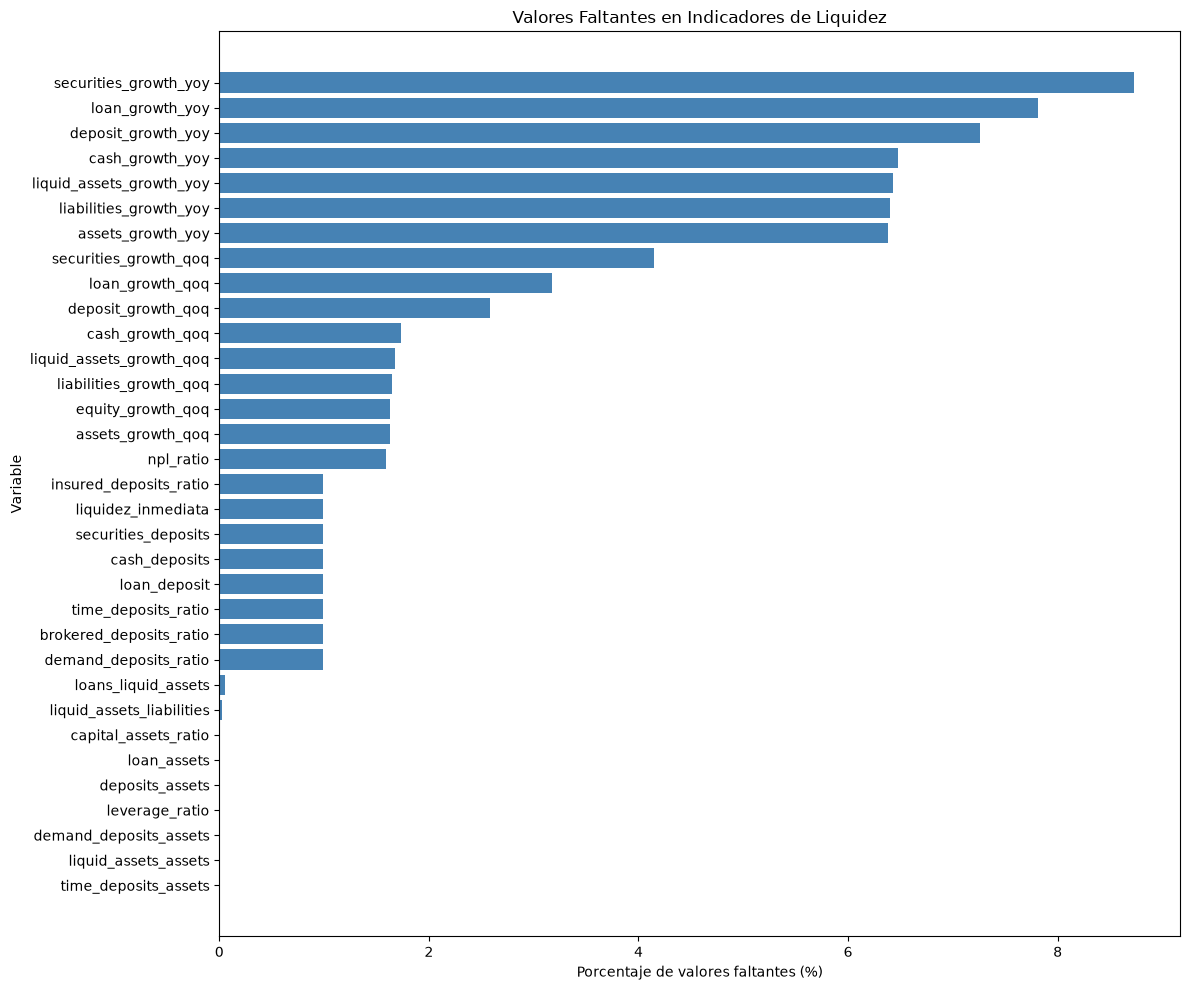

In [26]:
# Gráfico de valores faltantes en indicadores
plt.figure(figsize=(12, 10))
faltantes_plot = faltantes_indicadores[faltantes_indicadores['faltantes'] > 0].copy()
if len(faltantes_plot) > 0:
    colores = ['coral' if x > 50 else 'orange' if x > 20 else 'steelblue' 
               for x in faltantes_plot['porcentaje_faltantes']]
    plt.barh(faltantes_plot['variable'], faltantes_plot['porcentaje_faltantes'], color=colores)
    plt.xlabel("Porcentaje de valores faltantes (%)")
    plt.ylabel("Variable")
    plt.title("Valores Faltantes en Indicadores de Liquidez")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No hay valores faltantes en los indicadores.")

## 18. Diagnóstico de Valores Faltantes

<div style="text-align: justify;">

Con el propósito de determinar el origen de los valores faltantes, los 33 indicadores se clasifican en tres grupos según su naturaleza: **indicadores estructurales o ratios, indicadores de crecimiento interanual (YoY) e indicadores de crecimiento trimestral (QoQ)**. Esta clasificación permite diferenciar los faltantes derivados de la construcción temporal de aquellos asociados a la disponibilidad de información financiera o al cálculo de los ratios.

### 18.1. Clasificación de los indicadores

| Grupo                              | Número de indicadores | Característica                                             |
| ---------------------------------- | --------------------: | ---------------------------------------------------------- |
| Indicadores estructurales / ratios |                **13** | Miden niveles, composición y relaciones financieras        |
| Indicadores YoY                    |                 **7** | Miden variaciones respecto al período equivalente anterior |
| Indicadores QoQ                    |                 **8** | Miden variaciones respecto al período anterior             |

### 18.2. Faltantes en indicadores estructurales

| Indicador                   | Faltantes | % Faltantes |
| --------------------------- | --------: | ----------: |
| `liquidez_inmediata`        |         — |           — |
| `cash_deposits`             |         — |           — |
| `securities_deposits`       |         — |           — |
| `loan_deposit`              |         — |           — |
| `loan_assets`               |         — |           — |
| `deposits_assets`           |         — |           — |
| `brokered_deposits_ratio`   |         — |           — |
| `insured_deposits_ratio`    |         — |           — |
| `time_deposits_ratio`       |         — |           — |
| `demand_deposits_ratio`     |         — |           — |
| `leverage_ratio`            |         — |           — |
| `liquid_assets_liabilities` |         — |           — |
| `capital_assets_ratio`      |         — |           — |

Los indicadores estructurales presentan faltantes asociados principalmente a la disponibilidad de las variables financieras utilizadas en su construcción y a las condiciones necesarias para calcular determinados ratios. Estos valores deberán diferenciarse de los faltantes estructurales generados por la dimensión temporal.

### 18.3. Faltantes en indicadores YoY

| Indicador                  |  Faltantes | % Faltantes |
| -------------------------- | ---------: | ----------: |
| `securities_growth_yoy`    | **60.955** | **8,7305%** |
| `loan_growth_yoy`          | **54.516** | **7,8083%** |
| `deposit_growth_yoy`       | **50.707** | **7,2627%** |
| `cash_growth_yoy`          | **45.227** | **6,4778%** |
| `liquid_assets_growth_yoy` | **44.865** | **6,4260%** |
| `liabilities_growth_yoy`   | **44.674** | **6,3986%** |
| `assets_growth_yoy`        | **44.543** | **6,3798%** |

Los indicadores YoY concentran los mayores porcentajes de valores faltantes. Este comportamiento es consistente con su construcción, debido a que requieren disponer de información del mismo indicador en un período anterior. Por tanto, una parte importante de estos faltantes puede considerarse **estructural y derivada de la disponibilidad temporal de información**, en lugar de representar necesariamente un problema de calidad de datos.

### 18.4. Faltantes en indicadores QoQ

| Indicador                  |  Faltantes | % Faltantes |
| -------------------------- | ---------: | ----------: |
| `securities_growth_qoq`    | **28.983** | **4,1511%** |
| `loan_growth_qoq`          | **22.134** | **3,1711%** |
| `deposit_growth_qoq`       | **18.026** | **2,5810%** |
| `cash_growth_qoq`          | **12.080** | **1,7299%** |
| `liquid_assets_growth_qoq` | **11.693** | **1,6745%** |
| `liabilities_growth_qoq`   | **11.496** | **1,6463%** |
| `equity_growth_qoq`        | **11.345** | **1,6248%** |
| `assets_growth_qoq`        | **11.344** | **1,6246%** |

Los indicadores QoQ presentan porcentajes de faltantes inferiores a los observados en los indicadores YoY, aunque mantienen el mismo patrón general: la ausencia de información se encuentra relacionada con la necesidad de disponer del período anterior para calcular la variación.

En conjunto, el diagnóstico confirma que los valores faltantes **no presentan un único origen**. Los indicadores YoY y QoQ muestran un componente temporal claramente asociado a su construcción, mientras que los indicadores estructurales requieren analizar la disponibilidad de sus variables componentes y las condiciones de cálculo de cada ratio. Esta diferenciación será utilizada posteriormente para definir el tratamiento de los faltantes en `LiquiditySense`, evitando aplicar una estrategia uniforme que pueda alterar la información financiera o introducir sesgos en el modelo.

</div>


In [27]:
# ============================================
# DIAGNÓSTICO DE VALORES FALTANTES
# ============================================

print("============================================")
print("DIAGNÓSTICO DE VALORES FALTANTES")
print("============================================")

# --------------------------------------------
# 1. Clasificación de indicadores
# --------------------------------------------

indicadores_yoy = [
    'loan_growth_yoy',
    'deposit_growth_yoy',
    'cash_growth_yoy',
    'securities_growth_yoy',
    'liabilities_growth_yoy',
    'assets_growth_yoy',
    'liquid_assets_growth_yoy'
]

indicadores_qoq = [
    'deposit_growth_qoq',
    'cash_growth_qoq',
    'liquid_assets_growth_qoq',
    'loan_growth_qoq',
    'liabilities_growth_qoq',
    'assets_growth_qoq',
    'securities_growth_qoq',
    'equity_growth_qoq'
]

indicadores_ratios = [
    v for v in variables_indicadores
    if v not in indicadores_yoy
    and v not in indicadores_qoq
]

print("\nIndicadores estructurales/ratios:")
print(len(indicadores_ratios))

print("\nIndicadores YoY:")
print(len(indicadores_yoy))

print("\nIndicadores QoQ:")
print(len(indicadores_qoq))


# --------------------------------------------
# 2. Faltantes por grupo
# --------------------------------------------

def resumen_faltantes(lista_variables, nombre_grupo):

    resultado = pd.DataFrame({
        "variable": lista_variables,
        "faltantes": [
            base_liquidez[v].isna().sum()
            for v in lista_variables
        ]
    })

    resultado["porcentaje_faltantes"] = (
        resultado["faltantes"]
        / len(base_liquidez)
        * 100
    )

    resultado = (
        resultado
        .sort_values(
            "porcentaje_faltantes",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\n============================================")
    print(nombre_grupo)
    print("============================================")

    print(resultado)

    return resultado


faltantes_ratios = resumen_faltantes(
    indicadores_ratios,
    "FALTANTES — INDICADORES ESTRUCTURALES"
)

faltantes_yoy = resumen_faltantes(
    indicadores_yoy,
    "FALTANTES — INDICADORES YoY"
)

faltantes_qoq = resumen_faltantes(
    indicadores_qoq,
    "FALTANTES — INDICADORES QoQ"
)

DIAGNÓSTICO DE VALORES FALTANTES

Indicadores estructurales/ratios:
18

Indicadores YoY:
7

Indicadores QoQ:
8

FALTANTES — INDICADORES ESTRUCTURALES
                     variable  faltantes  porcentaje_faltantes
0                   npl_ratio      11116                1.5921
1      insured_deposits_ratio       6929                0.9924
2               cash_deposits       6907                0.9893
3          liquidez_inmediata       6907                0.9893
4     brokered_deposits_ratio       6907                0.9893
5         securities_deposits       6907                0.9893
6         time_deposits_ratio       6907                0.9893
7       demand_deposits_ratio       6907                0.9893
8                loan_deposit       6907                0.9893
9         loans_liquid_assets        363                0.0520
10  liquid_assets_liabilities        170                0.0243
11            deposits_assets          6                0.0009
12                loan_assets  

## 19. Origen Temporal de los Valores Faltantes

<div style="text-align: justify;">

Para determinar si los valores faltantes de los indicadores de crecimiento presentan un origen temporal, se analiza la antigüedad de cada institución dentro de la base. Para ello, se identifica la primera y última fecha disponible para cada banco y se calcula el número de meses transcurridos desde el inicio de su historial hasta cada observación.

Este procedimiento permite verificar si los faltantes de los indicadores **YoY y QoQ** se concentran en los primeros períodos de información de cada institución, condición esperable debido a que estos indicadores requieren disponer de observaciones históricas previas para calcular las variaciones.

### 19.1. Historial temporal de las instituciones

Como referencia, se observa que algunas instituciones presentan un historial completo desde **enero de 2000 hasta octubre de 2025**, equivalente a **104 períodos**, mientras que otras cuentan con historiales más cortos. Por ejemplo:

| `id_rssd` | Fecha de inicio | Fecha de fin | Períodos |
| --------: | --------------- | ------------ | -------: |
|        37 | 2000-01-01      | 2025-10-01   |      104 |
|       242 | 2000-01-01      | 2025-10-01   |      104 |
|       279 | 2000-01-01      | 2025-10-01   |      104 |
|       354 | 2000-01-01      | 2025-10-01   |      104 |
|       439 | 2000-01-01      | 2007-04-01   |       30 |

La existencia de instituciones con diferentes longitudes de historial constituye un elemento importante para interpretar los valores faltantes de los indicadores de crecimiento, debido a que no todas las entidades disponen de la misma cantidad de información histórica.

### 19.2. Faltantes YoY según antigüedad del banco

| Indicador                  | Faltantes | Mediana meses desde inicio | Máximo meses desde inicio |
| -------------------------- | --------: | -------------------------: | ------------------------: |
| `securities_growth_yoy`    |    60.955 |                      **6** |                       309 |
| `loan_growth_yoy`          |    54.516 |                      **6** |                       309 |
| `deposit_growth_yoy`       |    50.707 |                      **6** |                       309 |
| `cash_growth_yoy`          |    45.227 |                      **6** |                       297 |
| `liquid_assets_growth_yoy` |    44.865 |                      **3** |                       297 |
| `liabilities_growth_yoy`   |    44.674 |                      **3** |                       297 |
| `assets_growth_yoy`        |    44.543 |                      **3** |                       153 |

Los resultados muestran que los faltantes YoY presentan una **mediana de antigüedad de 3 a 6 meses desde el inicio del historial**. Este patrón es consistente con la existencia de períodos iniciales en los que todavía no se dispone de la información histórica necesaria para calcular una variación interanual.

No obstante, el máximo de meses desde el inicio alcanza hasta **309 meses** en algunas variables. Esto indica que, aunque una parte importante de los faltantes se concentra al inicio del historial, también existen faltantes en períodos posteriores que deberán analizarse de manera específica para determinar si corresponden a interrupciones de información, cambios en la disponibilidad de datos u otras condiciones.

### 19.3. Faltantes QoQ según antigüedad del banco

| Indicador                  | Faltantes | Mediana meses desde inicio | Máximo meses desde inicio |
| -------------------------- | --------: | -------------------------: | ------------------------: |
| `deposit_growth_qoq`       |    18.020 |                      **0** |                       309 |
| `cash_growth_qoq`          |    12.078 |                      **0** |                       297 |
| `liquid_assets_growth_qoq` |    11.691 |                      **0** |                       297 |
| `loan_growth_qoq`          |    22.140 |                      **0** |                       309 |
| `liabilities_growth_qoq`   |    11.494 |                      **0** |                       297 |
| `assets_growth_qoq`        |    11.343 |                      **0** |                       153 |
| `securities_growth_qoq`    |    28.982 |                     **21** |                       309 |
| `equity_growth_qoq`        |    11.344 |                      **0** |                       153 |

En los indicadores QoQ se observa un patrón aún más evidente: **seis de los ocho indicadores presentan una mediana de 0 meses desde el inicio del historial**. Esto indica que, en términos centrales, los faltantes se concentran en las primeras observaciones de cada institución, comportamiento compatible con la necesidad de disponer de un período previo para calcular la variación trimestral.

Una excepción relevante es `securities_growth_qoq`, cuya mediana alcanza **21 meses**. Este comportamiento indica que sus valores faltantes no se concentran exclusivamente en el inicio del historial y, por tanto, requieren una revisión adicional para determinar las causas específicas de su ausencia.

### 19.4. Interpretación del diagnóstico temporal

El análisis proporciona evidencia de que una parte importante de los valores faltantes en los indicadores de crecimiento tiene un **origen temporal o estructural**. La concentración de los faltantes al inicio del historial es especialmente clara en los indicadores QoQ, donde la mediana es de **0 meses**, y también se observa en los indicadores YoY, con medianas de **3 y 6 meses**.

Por tanto, estos faltantes no deben interpretarse automáticamente como problemas de calidad de datos ni ser imputados de manera indiscriminada. En particular, los faltantes generados porque todavía no existe información histórica suficiente para calcular una variación constituyen una característica inherente a la construcción de los indicadores.

Sin embargo, la existencia de faltantes con antigüedades considerablemente mayores —hasta **309 meses**— demuestra que no todos pueden atribuirse exclusivamente a la falta de períodos iniciales. En consecuencia, antes del tratamiento definitivo será necesario diferenciar los **faltantes estructurales de origen temporal** de aquellos que puedan responder a interrupciones o ausencia de información en períodos intermedios.

Esta diferenciación será fundamental para `LiquiditySense`, ya que permite preservar la estructura temporal de la información y evitar que un tratamiento inadecuado de los valores faltantes introduzca información artificial o genere sesgos en las etapas posteriores de selección y modelización.

</div>


In [28]:
# ============================================
# ORIGEN TEMPORAL DE LOS VALORES FALTANTES
# ============================================

print("============================================")
print("ORIGEN TEMPORAL DE LOS VALORES FALTANTES")
print("============================================")


# --------------------------------------------
# 1. Fecha mínima y máxima por banco
# --------------------------------------------

historial_bancos = (
    base_liquidez
    .groupby("id_rssd")["date"]
    .agg(
        fecha_inicio="min",
        fecha_fin="max",
        periodos="count"
    )
    .reset_index()
)

print("\nHistorial temporal de los bancos:")
print(historial_bancos.head())


# --------------------------------------------
# 2. Incorporar fecha de inicio del banco
# --------------------------------------------

base_diagnostico = base_liquidez[
    ["id_rssd", "date"]
].copy()

base_diagnostico = base_diagnostico.merge(
    historial_bancos[
        ["id_rssd", "fecha_inicio"]
    ],
    on="id_rssd",
    how="left"
)

# Meses desde el inicio de la historia
base_diagnostico["meses_desde_inicio"] = (
    (
        base_diagnostico["date"].dt.year
        - base_diagnostico["fecha_inicio"].dt.year
    ) * 12
    +
    (
        base_diagnostico["date"].dt.month
        - base_diagnostico["fecha_inicio"].dt.month
    )
)


# --------------------------------------------
# 3. Analizar faltantes YoY
# --------------------------------------------

print("\n============================================")
print("FALTANTES YoY SEGÚN ANTIGÜEDAD DEL BANCO")
print("============================================")

for variable in indicadores_yoy:

    mascara = base_liquidez[variable].isna()

    datos = base_diagnostico.loc[
        mascara,
        ["id_rssd", "date", "fecha_inicio", "meses_desde_inicio"]
    ].copy()

    print(f"\nVariable: {variable}")

    print(
        "Cantidad de faltantes:",
        len(datos)
    )

    print(
        "Mediana de meses desde inicio:",
        datos["meses_desde_inicio"].median()
    )

    print(
        "Máximo de meses desde inicio:",
        datos["meses_desde_inicio"].max()
    )


# --------------------------------------------
# 4. Analizar faltantes QoQ
# --------------------------------------------

print("\n============================================")
print("FALTANTES QoQ SEGÚN ANTIGÜEDAD DEL BANCO")
print("============================================")

for variable in indicadores_qoq:

    mascara = base_liquidez[variable].isna()

    datos = base_diagnostico.loc[
        mascara,
        ["id_rssd", "date", "fecha_inicio", "meses_desde_inicio"]
    ].copy()

    print(f"\nVariable: {variable}")

    print(
        "Cantidad de faltantes:",
        len(datos)
    )

    print(
        "Mediana de meses desde inicio:",
        datos["meses_desde_inicio"].median()
    )

    print(
        "Máximo de meses desde inicio:",
        datos["meses_desde_inicio"].max()
    )

ORIGEN TEMPORAL DE LOS VALORES FALTANTES

Historial temporal de los bancos:
   id_rssd fecha_inicio  fecha_fin  periodos
0       37   2000-01-01 2025-10-01       104
1      242   2000-01-01 2025-10-01       104
2      279   2000-01-01 2025-10-01       104
3      354   2000-01-01 2025-10-01       104
4      439   2000-01-01 2007-04-01        30

FALTANTES YoY SEGÚN ANTIGÜEDAD DEL BANCO

Variable: loan_growth_yoy
Cantidad de faltantes: 54516
Mediana de meses desde inicio: 6.0
Máximo de meses desde inicio: 309

Variable: deposit_growth_yoy
Cantidad de faltantes: 50707
Mediana de meses desde inicio: 6.0
Máximo de meses desde inicio: 309

Variable: cash_growth_yoy
Cantidad de faltantes: 45227
Mediana de meses desde inicio: 6.0
Máximo de meses desde inicio: 297

Variable: securities_growth_yoy
Cantidad de faltantes: 60955
Mediana de meses desde inicio: 6.0
Máximo de meses desde inicio: 309

Variable: liabilities_growth_yoy
Cantidad de faltantes: 44674
Mediana de meses desde inicio: 3.0
Máxim

## 20. Diagnóstico de Tratamiento

<div style="text-align: justify;">

Una vez identificados y caracterizados los valores faltantes, se realiza un diagnóstico orientado a determinar **su naturaleza y el tratamiento que corresponde aplicar**. El objetivo es diferenciar los faltantes que son consecuencia de la propia construcción temporal de los indicadores de aquellos que aparecen en períodos donde, en principio, ya debería existir información suficiente para realizar el cálculo.

Esta diferenciación es fundamental para `LiquiditySense`, debido a que una imputación indiscriminada podría introducir información artificial en los indicadores financieros y alterar la dinámica temporal de las instituciones. Por ello, el tratamiento de los valores faltantes se define a partir de su posición dentro del historial de cada banco.

### 20.1. Clasificación de Datos Faltantes

Los indicadores se clasifican en tres grupos según su naturaleza:

| Grupo                     | N.º de indicadores | Característica                                                                      |
| ------------------------- | -----------------: | ----------------------------------------------------------------------------------- |
| Indicadores estructurales |             **18** | Ratios e indicadores calculados a partir de variables financieras del mismo período |
| Indicadores YoY           |              **7** | Variación respecto al mismo período del año anterior                                |
| Indicadores QoQ           |              **8** | Variación respecto al período trimestral anterior                                   |
| **Total**                 |             **33** | Indicadores candidatos                                                              |

Los **18 indicadores estructurales** corresponden principalmente a ratios de liquidez, estructura financiera, calidad de cartera y composición de activos y pasivos. Los **7 indicadores YoY** y **8 indicadores QoQ** incorporan una dimensión temporal y, por tanto, pueden presentar valores faltantes de carácter estructural cuando no existe información histórica suficiente para calcular la variación.

Esta clasificación constituye la base para definir posteriormente estrategias de tratamiento diferenciadas, evitando aplicar un único procedimiento de imputación a indicadores con naturalezas distintas.

### 20.2. Diagnóstico de Faltantes al Inicio de Cada Banco

Para determinar la posición temporal de cada valor faltante, se ordenan las observaciones por `id_rssd` y `date` y se asigna a cada registro un número de período dentro del historial de la institución mediante `periodo_banco`.

De esta manera, `periodo_banco = 0` representa la primera observación disponible para un banco, mientras que valores posteriores representan períodos sucesivos dentro de su historial.

Este procedimiento permite analizar los valores faltantes **en función de la antigüedad de cada institución**, evitando comparar únicamente fechas calendario. Esta consideración es importante porque los bancos no necesariamente comienzan a reportar información en el mismo período.

### 20.3. Faltantes YoY por Posición Temporal

Para los indicadores YoY se clasifican los valores faltantes según tres intervalos de antigüedad dentro del historial de cada banco:

| Intervalo            | Interpretación                                       |
| -------------------- | ---------------------------------------------------- |
| `periodo_banco` 0–3  | Primeros períodos de información                     |
| `periodo_banco` 4–11 | Período inicial posterior                            |
| `periodo_banco` ≥ 12 | Observaciones posteriores al primer año de historial |

Esta clasificación permite determinar si los faltantes YoY se concentran en las primeras observaciones de cada institución. Dado que una variación interanual requiere disponer de información correspondiente a un período anterior, los faltantes observados durante la etapa inicial pueden considerarse **estructurales**, siempre que su ausencia sea consistente con la disponibilidad histórica.

En cambio, los faltantes que aparecen cuando el banco ya cuenta con al menos doce meses de historial requieren una revisión adicional, debido a que podrían representar interrupciones de información, ausencia de datos en períodos intermedios u otras situaciones que no están directamente explicadas por la construcción inicial del indicador.

### 20.4. Faltantes QoQ por Posición Temporal

Para los indicadores QoQ se utiliza una clasificación más directa:

| Posición            | Interpretación                      |
| ------------------- | ----------------------------------- |
| `periodo_banco = 0` | Primera observación disponible      |
| `periodo_banco ≥ 1` | Observaciones posteriores al inicio |

Los faltantes correspondientes al primer período de cada institución pueden considerarse **estructurales**, debido a que el cálculo de una variación QoQ requiere necesariamente disponer de una observación anterior.

Por el contrario, los faltantes que aparecen después del primer período deben analizarse como posibles **faltantes no estructurales**, ya que en condiciones normales el indicador debería poder calcularse si existe continuidad en la información financiera.

Este análisis permite diferenciar la ausencia esperada de información inicial de posibles interrupciones dentro de las series temporales.

### 20.5. Análisis de Faltantes No Estructurales

Después de identificar los faltantes asociados a la etapa inicial de cada institución, se realiza un análisis específico de aquellos que aparecen posteriormente. Para ello, se calcula `meses_desde_inicio`, que representa el tiempo transcurrido entre la primera fecha disponible del banco y cada observación.

En los indicadores YoY se consideran como potencialmente no estructurales aquellos valores faltantes correspondientes a observaciones con **12 meses o más desde el inicio del historial**. En los indicadores QoQ, se consideran potencialmente no estructurales los faltantes registrados después del primer período.

Este procedimiento permite cuantificar qué parte de los valores faltantes permanece una vez descontada la ausencia esperada derivada de la construcción temporal de los indicadores.

Los resultados de este diagnóstico serán utilizados para separar conceptualmente los faltantes en dos categorías:

| Tipo de faltante   | Criterio general                                                                 | Tratamiento esperado                  |
| ------------------ | -------------------------------------------------------------------------------- | ------------------------------------- |
| **Estructural**    | Asociado a la falta de períodos históricos necesarios para calcular el indicador | No imputar automáticamente            |
| **No estructural** | Aparece después del período en que el indicador debería poder calcularse         | Analizar origen y definir tratamiento |

La identificación de faltantes no estructurales constituye un paso especialmente importante antes de realizar cualquier imputación o eliminación. En `LiquiditySense`, estos registros deberán ser evaluados considerando la continuidad temporal de cada institución y la naturaleza de la variable financiera involucrada.

En consecuencia, **no se aplicará una imputación generalizada sobre todos los valores faltantes**. Primero se diferenciarán los faltantes estructurales de aquellos potencialmente asociados a ausencia de información. Posteriormente, los faltantes no estructurales podrán ser evaluados según su frecuencia, distribución temporal y relevancia para el modelo, procurando preservar la integridad de las series financieras y evitar la introducción de información artificial.

</div>


In [29]:
# ============================================
# DIAGNÓSTICO PARA TRATAMIENTO
# CLASIFICACIÓN DE VALORES FALTANTES
# ============================================

indicadores_estructurales = [
    'liquidez_inmediata',
    'cash_deposits',
    'securities_deposits',
    'loan_deposit',
    'loan_assets',
    'deposits_assets',
    'brokered_deposits_ratio',
    'insured_deposits_ratio',
    'time_deposits_ratio',
    'demand_deposits_ratio',
    'leverage_ratio',
    'liquid_assets_liabilities',
    'capital_assets_ratio',
    'npl_ratio',
    'liquid_assets_assets',
    'time_deposits_assets',
    'demand_deposits_assets',
    'loans_liquid_assets'
]

indicadores_yoy = [
    'loan_growth_yoy',
    'deposit_growth_yoy',
    'cash_growth_yoy',
    'securities_growth_yoy',
    'liabilities_growth_yoy',
    'assets_growth_yoy',
    'liquid_assets_growth_yoy'
]

indicadores_qoq = [
    'deposit_growth_qoq',
    'cash_growth_qoq',
    'liquid_assets_growth_qoq',
    'loan_growth_qoq',
    'liabilities_growth_qoq',
    'assets_growth_qoq',
    'securities_growth_qoq',
    'equity_growth_qoq'
]

print("============================================")
print("CLASIFICACIÓN DE INDICADORES")
print("============================================")

print(
    f"\nIndicadores estructurales: "
    f"{len(indicadores_estructurales)}"
)

print(
    f"Indicadores YoY: "
    f"{len(indicadores_yoy)}"
)

print(
    f"Indicadores QoQ: "
    f"{len(indicadores_qoq)}"
)

print(
    f"\nTotal: "
    f"{len(indicadores_estructurales) + len(indicadores_yoy) + len(indicadores_qoq)}"
)

CLASIFICACIÓN DE INDICADORES

Indicadores estructurales: 18
Indicadores YoY: 7
Indicadores QoQ: 8

Total: 33


In [30]:
# ============================================
# FALTANTES SEGÚN POSICIÓN TEMPORAL
# ============================================

base_ordenada = (
    base_liquidez
    .sort_values(
        ['id_rssd', 'date']
    )
    .copy()
)

# Número de período dentro de cada banco
base_ordenada['periodo_banco'] = (
    base_ordenada
    .groupby('id_rssd')
    .cumcount()
)

print("Base ordenada correctamente.")
print(
    f"Registros: {len(base_ordenada):,}"
)

Base ordenada correctamente.
Registros: 698,184


In [31]:
# ============================================
# FALTANTES YoY POR POSICIÓN
# ============================================

resultado_yoy = []

for variable in indicadores_yoy:

    faltantes = base_ordenada[
        base_ordenada[variable].isna()
    ]

    resultado_yoy.append({
        'variable': variable,
        'faltantes': len(faltantes),
        'faltantes_periodo_0_3': (
            faltantes['periodo_banco'] <= 3
        ).sum(),
        'faltantes_periodo_4_11': (
            (faltantes['periodo_banco'] >= 4) &
            (faltantes['periodo_banco'] <= 11)
        ).sum(),
        'faltantes_periodo_12_mas': (
            faltantes['periodo_banco'] >= 12
        ).sum()
    })

diagnostico_yoy = pd.DataFrame(resultado_yoy)

print("============================================")
print("DIAGNÓSTICO DE FALTANTES YoY")
print("============================================")

print(diagnostico_yoy)

DIAGNÓSTICO DE FALTANTES YoY
                   variable  faltantes  faltantes_periodo_0_3  \
0           loan_growth_yoy      54516                  44538   
1        deposit_growth_yoy      50707                  44538   
2           cash_growth_yoy      45227                  44538   
3     securities_growth_yoy      60955                  44538   
4    liabilities_growth_yoy      44674                  44538   
5         assets_growth_yoy      44543                  44538   
6  liquid_assets_growth_yoy      44865                  44538   

   faltantes_periodo_4_11  faltantes_periodo_12_mas  
0                    1864                      8114  
1                    1099                      5070  
2                     159                       530  
3                    3352                     13065  
4                      45                        91  
5                       4                         1  
6                      59                       268  


In [32]:
# ============================================
# FALTANTES QoQ POR POSICIÓN
# ============================================

resultado_qoq = []

for variable in indicadores_qoq:

    faltantes = base_ordenada[
        base_ordenada[variable].isna()
    ]

    resultado_qoq.append({
        'variable': variable,
        'faltantes': len(faltantes),
        'faltantes_periodo_0': (
            faltantes['periodo_banco'] == 0
        ).sum(),
        'faltantes_periodo_1_mas': (
            faltantes['periodo_banco'] >= 1
        ).sum()
    })

diagnostico_qoq = pd.DataFrame(resultado_qoq)

print("============================================")
print("DIAGNÓSTICO DE FALTANTES QoQ")
print("============================================")

print(diagnostico_qoq)

DIAGNÓSTICO DE FALTANTES QoQ
                   variable  faltantes  faltantes_periodo_0  \
0        deposit_growth_qoq      18020                11339   
1           cash_growth_qoq      12078                11339   
2  liquid_assets_growth_qoq      11691                11339   
3           loan_growth_qoq      22140                11339   
4    liabilities_growth_qoq      11494                11339   
5         assets_growth_qoq      11343                11339   
6     securities_growth_qoq      28982                11339   
7         equity_growth_qoq      11344                11339   

   faltantes_periodo_1_mas  
0                     6681  
1                      739  
2                      352  
3                    10801  
4                      155  
5                        4  
6                    17643  
7                        5  


In [33]:
# ============================================
# ANÁLISIS DE FALTANTES NO ESTRUCTURALES
# ============================================

print("============================================")
print("FALTANTES NO ESTRUCTURALES")
print("============================================")

# ------------------------------------------------
# 1. CALCULAR ANTIGÜEDAD DEL BANCO
# ------------------------------------------------

base_analisis = base_liquidez.copy()

fecha_inicio_banco = (
    base_analisis
    .groupby("id_rssd")["date"]
    .transform("min")
)

base_analisis["meses_desde_inicio"] = (
    (
        base_analisis["date"].dt.year
        - fecha_inicio_banco.dt.year
    ) * 12
    +
    (
        base_analisis["date"].dt.month
        - fecha_inicio_banco.dt.month
    )
)

# ------------------------------------------------
# 2. DEFINIR INDICADORES
# ------------------------------------------------

indicadores_yoy = [
    'loan_growth_yoy',
    'deposit_growth_yoy',
    'cash_growth_yoy',
    'securities_growth_yoy',
    'liabilities_growth_yoy',
    'assets_growth_yoy',
    'liquid_assets_growth_yoy'
]

indicadores_qoq = [
    'deposit_growth_qoq',
    'cash_growth_qoq',
    'liquid_assets_growth_qoq',
    'loan_growth_qoq',
    'liabilities_growth_qoq',
    'assets_growth_qoq',
    'securities_growth_qoq',
    'equity_growth_qoq'
]

# ------------------------------------------------
# 3. FALTANTES YoY DESPUÉS DEL PERÍODO INICIAL
# ------------------------------------------------

print("\n============================================")
print("FALTANTES YoY DESPUÉS DEL PERÍODO INICIAL")
print("============================================")

resultados_yoy_no_estructurales = []

for variable in indicadores_yoy:

    faltantes_no_estructurales = (
        base_analisis[variable].isna()
        &
        (base_analisis["meses_desde_inicio"] >= 12)
    )

    cantidad = faltantes_no_estructurales.sum()

    porcentaje = (
        cantidad / len(base_analisis) * 100
    )

    resultados_yoy_no_estructurales.append({
        "variable": variable,
        "faltantes_no_estructurales": cantidad,
        "porcentaje_base": porcentaje
    })

tabla_yoy_no_estructurales = (
    pd.DataFrame(
        resultados_yoy_no_estructurales
    )
    .sort_values(
        "faltantes_no_estructurales",
        ascending=False
    )
    .reset_index(drop=True)
)

print(tabla_yoy_no_estructurales)


# ------------------------------------------------
# 4. FALTANTES QoQ DESPUÉS DEL PRIMER PERÍODO
# ------------------------------------------------

print("\n============================================")
print("FALTANTES QoQ DESPUÉS DEL PERÍODO INICIAL")
print("============================================")

resultados_qoq_no_estructurales = []

for variable in indicadores_qoq:

    faltantes_no_estructurales = (
        base_analisis[variable].isna()
        &
        (base_analisis["meses_desde_inicio"] > 0)
    )

    cantidad = faltantes_no_estructurales.sum()

    porcentaje = (
        cantidad / len(base_analisis) * 100
    )

    resultados_qoq_no_estructurales.append({
        "variable": variable,
        "faltantes_no_estructurales": cantidad,
        "porcentaje_base": porcentaje
    })

tabla_qoq_no_estructurales = (
    pd.DataFrame(
        resultados_qoq_no_estructurales
    )
    .sort_values(
        "faltantes_no_estructurales",
        ascending=False
    )
    .reset_index(drop=True)
)

print(tabla_qoq_no_estructurales)

FALTANTES NO ESTRUCTURALES

FALTANTES YoY DESPUÉS DEL PERÍODO INICIAL
                   variable  faltantes_no_estructurales  porcentaje_base
0     securities_growth_yoy                       16425           2.3525
1           loan_growth_yoy                        9986           1.4303
2        deposit_growth_yoy                        6177           0.8847
3           cash_growth_yoy                         697           0.0998
4  liquid_assets_growth_yoy                         335           0.0480
5    liabilities_growth_yoy                         144           0.0206
6         assets_growth_yoy                          13           0.0019

FALTANTES QoQ DESPUÉS DEL PERÍODO INICIAL
                   variable  faltantes_no_estructurales  porcentaje_base
0     securities_growth_qoq                       17643           2.5270
1           loan_growth_qoq                       10801           1.5470
2        deposit_growth_qoq                        6681           0.9569
3          

## 21. Investigación de la causa de los faltantes no estructurales

<div style="text-align: justify;">

Una vez identificados los valores faltantes potencialmente no estructurales, se realiza una investigación adicional para determinar sus posibles causas. El análisis considera cuatro dimensiones: **concentración de faltantes por institución, comportamiento temporal de los faltantes, existencia de denominadores iguales a cero y validación matemática de las fórmulas de crecimiento**.

El objetivo es determinar si los faltantes corresponden a situaciones propias de la información financiera, a condiciones matemáticas que impiden el cálculo de determinados indicadores o a posibles inconsistencias en la construcción de las variables. Esta evaluación permitirá definir posteriormente un tratamiento adecuado sin modificar artificialmente la información original.

### 21.1. Bancos con Mayor Cantidad de Faltantes

Se calcula la cantidad total de valores faltantes de los indicadores de crecimiento **YoY y QoQ** para cada institución identificada mediante `id_rssd`. Para ello, se contabilizan los valores nulos existentes en los 15 indicadores de crecimiento y posteriormente se agregan por banco.

El análisis permite identificar si los faltantes se encuentran concentrados en un grupo reducido de instituciones o si presentan una distribución más generalizada entre los bancos de la muestra.

La identificación de instituciones con una elevada cantidad de faltantes es relevante porque una concentración excesiva podría indicar problemas particulares de disponibilidad o continuidad de información para determinados bancos. En estos casos, será necesario revisar posteriormente el historial de cada institución antes de decidir si las observaciones deben conservarse, excluirse o recibir algún tratamiento específico.

### 21.2. Faltantes por Fecha

Se analiza la distribución temporal de los valores faltantes de los indicadores YoY y QoQ mediante su agregación por `date`. Este procedimiento permite identificar períodos en los cuales se concentra la ausencia de información y determinar si existen patrones temporales comunes entre diferentes instituciones.

Una concentración de faltantes en determinadas fechas podría estar asociada a períodos específicos de reporte, cambios en la disponibilidad de información o interrupciones generalizadas en determinadas variables. Por el contrario, una distribución aislada entre diferentes fechas e instituciones podría sugerir situaciones particulares de cada banco.

Este análisis complementa la evaluación realizada anteriormente sobre la antigüedad de las instituciones y permite determinar si los faltantes potencialmente no estructurales presentan algún patrón temporal común.

### 21.3. Porcentaje de Bancos con Faltantes por Fecha

Para profundizar el análisis temporal, se calcula el porcentaje de instituciones que presentan valores faltantes para cada indicador y cada fecha. El porcentaje se obtiene relacionando el número de bancos con faltantes respecto al total de bancos disponibles en cada período.

| Medida               | Interpretación                                                                        |
| -------------------- | ------------------------------------------------------------------------------------- |
| Bancos con faltante  | Número de instituciones que presentan ausencia del indicador en una fecha determinada |
| Total de bancos      | Número de instituciones disponibles en esa fecha                                      |
| Porcentaje de bancos | Proporción de instituciones afectadas                                                 |

Este indicador permite distinguir entre faltantes **aislados** y faltantes **generalizados**. Si un porcentaje elevado de instituciones presenta el mismo faltante en una fecha determinada, podría existir una causa común relacionada con la disponibilidad o reporte de información. En cambio, porcentajes reducidos y distribuidos irregularmente serían más compatibles con situaciones específicas de determinadas instituciones.

Por tanto, el porcentaje de bancos afectados por fecha constituye un criterio adicional para investigar si los faltantes no estructurales responden a un patrón sistemático o a eventos particulares.

### 21.4. Verificación de Faltantes Asociados a Denominadores Iguales a Cero

Debido a que los indicadores de crecimiento se calculan mediante una relación entre el valor actual y un valor histórico, un caso particularmente relevante corresponde a situaciones donde el **valor del período de referencia es igual a cero**.

Para los indicadores YoY se utiliza como referencia el valor registrado cuatro períodos anteriores mediante `shift(4),` mientras que para los indicadores QoQ se utiliza el período inmediatamente anterior mediante `shift(1)`.

El análisis compara cada valor faltante del indicador con el valor histórico utilizado como denominador, permitiendo determinar qué proporción de los faltantes puede explicarse por la existencia de un denominador igual a cero.

| Situación                                                | Interpretación                                              |
| -------------------------------------------------------- | ----------------------------------------------------------- |
| Indicador faltante + denominador histórico = 0           | El cálculo porcentual no es matemáticamente válido          |
| Indicador faltante + denominador histórico distinto de 0 | El faltante requiere investigar otra causa                  |
| Indicador no faltante                                    | El cálculo pudo realizarse bajo las condiciones disponibles |

Esta validación es importante porque un denominador igual a cero **no representa necesariamente un problema de calidad de datos**. Puede corresponder a una situación financiera real en la que una determinada partida no presentaba saldo en el período de referencia. En consecuencia, estos casos no deben imputarse automáticamente como si fueran valores faltantes convencionales.

La proporción de faltantes explicados por denominadores iguales a cero permitirá determinar cuánto del problema identificado anteriormente tiene una **causa matemática asociada a la construcción de los indicadores**.

### 21.5. Validación de las Fórmulas de Crecimiento

Finalmente, se verifica la consistencia matemática de los indicadores de crecimiento mediante el recálculo independiente de las fórmulas QoQ y YoY para `ln_tot` y `deposits`.

La lógica utilizada corresponde a:

* **QoQ:** valor actual dividido entre el valor del período anterior, menos uno.
* **YoY:** valor actual dividido entre el valor registrado cuatro períodos anteriores, menos uno.

Posteriormente, se calculan las diferencias entre los indicadores originalmente construidos y los valores recalculados. La evaluación de estas diferencias permite comprobar si las variables de crecimiento fueron construidas de acuerdo con la metodología definida.

| Indicador            | Frecuencia | Período de referencia                   |
| -------------------- | ---------- | --------------------------------------- |
| `loan_growth_qoq`    | QoQ        | Período anterior (`shift(1)`)           |
| `loan_growth_yoy`    | YoY        | Cuatro períodos anteriores (`shift(4)`) |
| `deposit_growth_qoq` | QoQ        | Período anterior (`shift(1)`)           |
| `deposit_growth_yoy` | YoY        | Cuatro períodos anteriores (`shift(4)`) |

La comparación entre los valores originales y recalculados permite identificar posibles discrepancias derivadas de errores en la fórmula, ordenamiento temporal o agrupación por institución. Si las diferencias son nulas o se encuentran dentro de niveles atribuibles al redondeo numérico, se obtiene evidencia de consistencia en la construcción de los indicadores.

Este control es especialmente importante antes de realizar cualquier tratamiento de valores faltantes, debido a que permite asegurar que los indicadores sobre los cuales se está investigando su ausencia fueron previamente construidos de manera consistente.

### 21.6. Integración del Diagnóstico

La investigación realizada permite abordar los faltantes no estructurales desde diferentes perspectivas: **institucional, temporal y matemática**. La concentración por banco permite identificar entidades con problemas particulares de disponibilidad; el análisis por fecha permite detectar posibles patrones generalizados; la revisión de denominadores iguales a cero permite explicar faltantes derivados de la propia fórmula de crecimiento; y la validación matemática permite comprobar la consistencia de los indicadores construidos.

En conjunto, estos análisis proporcionan los elementos necesarios para diferenciar los faltantes que pueden explicarse por condiciones inherentes a la construcción de los indicadores de aquellos que requieren un tratamiento específico.

Para `LiquiditySense`, esta diferenciación será utilizada como criterio previo a la etapa de tratamiento definitivo. Se evitará imputar automáticamente valores cuya ausencia tenga una explicación financiera o matemática válida, mientras que los faltantes que no puedan ser explicados mediante estos factores deberán evaluarse según su frecuencia, distribución temporal e impacto potencial sobre el análisis y el posterior modelo de Machine Learning.

</div>


In [34]:
# ============================================
# INVESTIGACIÓN DE FALTANTES
# BANCOS CON MAYOR CANTIDAD DE FALTANTES
# ============================================

print("============================================")
print("BANCOS CON MAYOR CANTIDAD DE FALTANTES")
print("============================================")

# Indicadores YoY + QoQ
indicadores_crecimiento = (
    indicadores_yoy +
    indicadores_qoq
)

# Crear contador de faltantes
base_faltantes = base_analisis[
    [
        "id_rssd",
        "date",
        "meses_desde_inicio"
    ] +
    indicadores_crecimiento
].copy()

base_faltantes["total_faltantes"] = (
    base_faltantes[
        indicadores_crecimiento
    ]
    .isna()
    .sum(axis=1)
)

# Cantidad de faltantes por banco
faltantes_por_banco = (
    base_faltantes
    .groupby("id_rssd")["total_faltantes"]
    .sum()
    .sort_values(
        ascending=False
    )
    .reset_index()
)

print(
    faltantes_por_banco.head(20)
)

BANCOS CON MAYOR CANTIDAD DE FALTANTES
    id_rssd  total_faltantes
0   2337335             1105
1   3229875              651
2   2916963              625
3    692704              621
4   2600039              621
5     93619              619
6    812164              602
7   2567123              600
8   2667920              597
9   4146830              589
10  4149037              589
11    52719              527
12  2531991              495
13  2122997              474
14  3045383              459
15  2797210              436
16  2973041              435
17  2719810              434
18  2328285              430
19  2757951              429


In [35]:
# ============================================
# FALTANTES POR FECHA
# ============================================

print("============================================")
print("FALTANTES POR FECHA")
print("============================================")

faltantes_por_fecha = (
    base_faltantes
    .groupby("date")[indicadores_crecimiento]
    .apply(
        lambda x: x.isna().sum()
    )
)

print(
    faltantes_por_fecha.head(20)
)

FALTANTES POR FECHA
            loan_growth_yoy  deposit_growth_yoy  cash_growth_yoy  \
date                                                               
2000-01-01             9055                9055             9055   
2000-04-01             9011                9011             9011   
2000-07-01             8906                8906             8906   
2000-10-01             8836                8836             8836   
2001-01-01              335                 295              294   
2001-04-01              309                 270              263   
2001-07-01              304                 261              257   
2001-10-01              293                 253              248   
2002-01-01              269                 222              152   
2002-04-01              266                 217              147   
2002-07-01              257                 208              135   
2002-10-01              238                 188              122   
2003-01-01              247 

In [36]:
# ============================================
# PORCENTAJE DE BANCOS CON FALTANTES
# ============================================

print("============================================")
print("PORCENTAJE DE BANCOS CON FALTANTES")
print("============================================")

total_bancos_fecha = (
    base_faltantes
    .groupby("date")["id_rssd"]
    .nunique()
)

faltantes_bancos_fecha = []

for variable in indicadores_crecimiento:

    tabla = (
        base_faltantes
        .groupby("date")
        .apply(
            lambda x: x[variable].isna().sum()
        )
        .to_frame("bancos_con_faltante")
    )

    tabla["total_bancos"] = (
        total_bancos_fecha
    )

    tabla["porcentaje_bancos"] = (
        tabla["bancos_con_faltante"]
        /
        tabla["total_bancos"]
        * 100
    )

    tabla["variable"] = variable

    faltantes_bancos_fecha.append(
        tabla.reset_index()
    )

diagnostico_temporal = pd.concat(
    faltantes_bancos_fecha,
    ignore_index=True
)

print(
    diagnostico_temporal
    .sort_values(
        "porcentaje_bancos",
        ascending=False
    )
    .head(30)
)

PORCENTAJE DE BANCOS CON FALTANTES


C:\Users\LENOVO YOGA\AppData\Local\Temp\ipykernel_9976\2562159495.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\LENOVO YOGA\AppData\Local\Temp\ipykernel_9976\2562159495.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\LENOVO YOGA\AppData\Local\Temp\ipykernel_9976\2562159495.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This b

           date  bancos_con_faltante  total_bancos  porcentaje_bancos  \
1456 2000-01-01                 9055          9055           100.0000   
627  2000-10-01                 8836          8836           100.0000   
523  2000-10-01                 8836          8836           100.0000   
522  2000-07-01                 8906          8906           100.0000   
521  2000-04-01                 9011          9011           100.0000   
520  2000-01-01                 9055          9055           100.0000   
419  2000-10-01                 8836          8836           100.0000   
1144 2000-01-01                 9055          9055           100.0000   
1248 2000-01-01                 9055          9055           100.0000   
1040 2000-01-01                 9055          9055           100.0000   
832  2000-01-01                 9055          9055           100.0000   
728  2000-01-01                 9055          9055           100.0000   
936  2000-01-01                 9055          9055 

C:\Users\LENOVO YOGA\AppData\Local\Temp\ipykernel_9976\2562159495.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [37]:
# ============================================
# FALTANTES ASOCIADOS A VALORES PREVIOS = 0
# ============================================

print("============================================")
print("FALTANTES POR DENOMINADOR IGUAL A CERO")
print("============================================")

# ------------------------------------------------
# VARIABLES BASE Y SUS CRECIMIENTOS
# ------------------------------------------------

relaciones_yoy = {
    "loan_growth_yoy": "ln_tot",
    "deposit_growth_yoy": "deposits",
    "cash_growth_yoy": "cash",
    "securities_growth_yoy": "securities",
    "liabilities_growth_yoy": "liab_tot",
    "assets_growth_yoy": "assets",
    "liquid_assets_growth_yoy": "liquid_assets"
}

relaciones_qoq = {
    "loan_growth_qoq": "ln_tot",
    "deposit_growth_qoq": "deposits",
    "cash_growth_qoq": "cash",
    "securities_growth_qoq": "securities",
    "liabilities_growth_qoq": "liab_tot",
    "assets_growth_qoq": "assets",
    "liquid_assets_growth_qoq": "liquid_assets",
    "equity_growth_qoq": "equity"
}

# ------------------------------------------------
# ORDENAR BASE
# ------------------------------------------------

base_crecimiento = (
    base_liquidez
    .sort_values(
        ["id_rssd", "date"]
    )
    .copy()
)

resultados_denominador = []

# ------------------------------------------------
# ANALIZAR YoY
# ------------------------------------------------

for indicador, variable_base in relaciones_yoy.items():

    # Valor anterior a 4 trimestres
    valor_anterior = (
        base_crecimiento
        .groupby("id_rssd")[variable_base]
        .shift(4)
    )

    faltante = (
        base_crecimiento[indicador].isna()
    )

    denominador_cero = (
        valor_anterior == 0
    )

    caso = (
        faltante &
        denominador_cero
    )

    resultados_denominador.append({
        "indicador": indicador,
        "frecuencia": "YoY",
        "faltante_total": faltante.sum(),
        "denominador_cero": caso.sum(),
        "porcentaje_faltantes_exp_y0": (
            caso.sum() /
            faltante.sum() *
            100
            if faltante.sum() > 0 else 0
        )
    })

# ------------------------------------------------
# ANALIZAR QoQ
# ------------------------------------------------

for indicador, variable_base in relaciones_qoq.items():

    # Valor anterior a 1 trimestre
    valor_anterior = (
        base_crecimiento
        .groupby("id_rssd")[variable_base]
        .shift(1)
    )

    faltante = (
        base_crecimiento[indicador].isna()
    )

    denominador_cero = (
        valor_anterior == 0
    )

    caso = (
        faltante &
        denominador_cero
    )

    resultados_denominador.append({
        "indicador": indicador,
        "frecuencia": "QoQ",
        "faltante_total": faltante.sum(),
        "denominador_cero": caso.sum(),
        "porcentaje_faltantes_exp_y0": (
            caso.sum() /
            faltante.sum() *
            100
            if faltante.sum() > 0 else 0
        )
    })

tabla_denominadores = (
    pd.DataFrame(
        resultados_denominador
    )
    .sort_values(
        [
            "frecuencia",
            "porcentaje_faltantes_exp_y0"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print(
    tabla_denominadores
)

FALTANTES POR DENOMINADOR IGUAL A CERO
                   indicador frecuencia  faltante_total  denominador_cero  \
0      securities_growth_qoq        QoQ           28982             17640   
1            loan_growth_qoq        QoQ           22140             10798   
2         deposit_growth_qoq        QoQ           18020              6677   
3            cash_growth_qoq        QoQ           12078               735   
4   liquid_assets_growth_qoq        QoQ           11691               348   
5     liabilities_growth_qoq        QoQ           11494               151   
6          equity_growth_qoq        QoQ           11344                 1   
7          assets_growth_qoq        QoQ           11343                 0   
8      securities_growth_yoy        YoY           60955             16414   
9            loan_growth_yoy        YoY           54516              9975   
10        deposit_growth_yoy        YoY           50707              6164   
11           cash_growth_yoy        Y

In [38]:
# ============================================
# VALIDACIÓN DE FÓRMULAS DE CRECIMIENTO
# ============================================

print("============================================")
print("VALIDACIÓN DE FÓRMULAS DE CRECIMIENTO")
print("============================================")

# ------------------------------------------------
# VARIABLES BASE
# ------------------------------------------------

variables_base = [
    "ln_tot",
    "deposits",
    "cash",
    "securities",
    "liab_tot",
    "assets",
    "liquid_assets",
    "equity"
]

print("\n============================================")
print("ESTADÍSTICOS DE VARIABLES BASE")
print("============================================")

print(
    base_liquidez[variables_base]
    .describe()
    .T
)

VALIDACIÓN DE FÓRMULAS DE CRECIMIENTO

ESTADÍSTICOS DE VARIABLES BASE
                    count         mean           std          min        25%  \
ln_tot        698181.0000 1200922.2174 18742072.4614       0.0000 39217.0000   
deposits      698181.0000 1660488.1781 31070080.3682       0.0000 56826.0000   
cash          698181.0000  220957.1273  5843768.7579    -178.0000  3250.0000   
securities    698181.0000  463036.3893  9424512.8529       0.0000 10247.0000   
liab_tot      698181.0000 1981622.6378 37636815.8537       0.0000 60400.0000   
assets        698181.0000 2214073.1638 41657697.7353       0.0000 68871.0000   
liquid_assets 698181.0000  683993.5165 14713286.8060       0.0000 17236.0000   
equity        698181.0000  231023.0303  4058713.4992 -161976.0000  7494.0000   

                      50%         75%             max  
ln_tot         95293.0000 247687.0000 1497490000.0000  
deposits      126706.0000 310840.0000 2697842000.0000  
cash            8244.0000  22437.0000  76

In [39]:
# ============================================
# VALIDACIÓN MATEMÁTICA DE CRECIMIENTOS
# ============================================

base_validacion = (
    base_liquidez
    .sort_values(
        ["id_rssd", "date"]
    )
    .copy()
)

# ------------------------------------------------
# CRECIMIENTOS CALCULADOS NUEVAMENTE
# ------------------------------------------------

base_validacion["loan_growth_qoq_calc"] = (
    base_validacion["ln_tot"]
    /
    base_validacion
    .groupby("id_rssd")["ln_tot"]
    .shift(1)
    - 1
)

base_validacion["loan_growth_yoy_calc"] = (
    base_validacion["ln_tot"]
    /
    base_validacion
    .groupby("id_rssd")["ln_tot"]
    .shift(4)
    - 1
)

base_validacion["deposit_growth_qoq_calc"] = (
    base_validacion["deposits"]
    /
    base_validacion
    .groupby("id_rssd")["deposits"]
    .shift(1)
    - 1
)

base_validacion["deposit_growth_yoy_calc"] = (
    base_validacion["deposits"]
    /
    base_validacion
    .groupby("id_rssd")["deposits"]
    .shift(4)
    - 1
)

# ------------------------------------------------
# DIFERENCIAS
# ------------------------------------------------

base_validacion["dif_loan_qoq"] = (
    base_validacion["loan_growth_qoq"]
    -
    base_validacion["loan_growth_qoq_calc"]
)

base_validacion["dif_loan_yoy"] = (
    base_validacion["loan_growth_yoy"]
    -
    base_validacion["loan_growth_yoy_calc"]
)

base_validacion["dif_deposit_qoq"] = (
    base_validacion["deposit_growth_qoq"]
    -
    base_validacion["deposit_growth_qoq_calc"]
)

base_validacion["dif_deposit_yoy"] = (
    base_validacion["deposit_growth_yoy"]
    -
    base_validacion["deposit_growth_yoy_calc"]
)

print("\n============================================")
print("DIFERENCIAS ENTRE CRECIMIENTO ORIGINAL Y RECALCULADO")
print("============================================")

print(
    base_validacion[
        [
            "dif_loan_qoq",
            "dif_loan_yoy",
            "dif_deposit_qoq",
            "dif_deposit_yoy"
        ]
    ]
    .describe()
)


DIFERENCIAS ENTRE CRECIMIENTO ORIGINAL Y RECALCULADO
       dif_loan_qoq  dif_loan_yoy  dif_deposit_qoq  dif_deposit_yoy
count   676044.0000   643668.0000      680164.0000      647477.0000
mean        -0.0000       -0.0000          -0.0000          -0.0000
std          0.0000        0.0000           0.0000           0.0000
min         -0.0000       -0.0000          -0.0000          -0.0000
25%         -0.0000       -0.0000          -0.0000          -0.0000
50%         -0.0000       -0.0000          -0.0000          -0.0000
75%          0.0000        0.0000           0.0000           0.0000
max          0.0000        0.0000           0.0000           0.0000


## 22. Tratamiento de Faltantes Estructurales

<div style="text-align: justify;">

Una vez identificada la naturaleza de los valores faltantes, se procede al tratamiento específico de aquellos que presentan un **origen estructural**, es decir, que se producen por la ausencia de períodos históricos necesarios para calcular los indicadores de crecimiento.

En esta etapa no se realiza imputación ni eliminación de registros. Los faltantes estructurales se **identifican, clasifican y marcan mediante variables auxiliares**, manteniendo el valor original como `NaN`. Esta decisión permite conservar la naturaleza real de la información y evitar la generación artificial de tasas de crecimiento para períodos en los que matemáticamente no existe una referencia histórica disponible.

### 22.1. Identificación de Faltantes Estructurales

La identificación se realiza considerando la posición temporal de cada observación dentro del historial de cada institución mediante `periodo_banco`.

Para los indicadores **YoY**, se consideran estructurales los faltantes correspondientes a los primeros **cuatro períodos trimestrales** de cada banco, debido a que el cálculo interanual requiere disponer de una observación ubicada cuatro períodos atrás.

Para los indicadores **QoQ**, se considera estructural el faltante correspondiente al **primer período** de cada institución, debido a que en dicha observación no existe un período trimestral anterior con el cual realizar la comparación.

| Indicador | Períodos considerados estructurales | Razón                                       |
| --------- | ----------------------------------- | ------------------------------------------- |
| YoY       | `periodo_banco < 4`                 | No existe información cuatro períodos atrás |
| QoQ       | `periodo_banco == 0`                | No existe un período anterior               |

Este procedimiento permite identificar los faltantes estructurales de manera individual para cada indicador, respetando el historial disponible de cada institución. La identificación se realiza sobre los valores que efectivamente se encuentran como `NaN`, evitando clasificar como faltantes estructurales observaciones que sí cuentan con un valor calculado.

### 22.2. Marcación de los Faltantes Estructurales

Una vez identificados los faltantes estructurales, se crean **marcadores específicos** que permiten conservar esta información para las siguientes etapas del proyecto.

Se generan indicadores generales para distinguir las observaciones correspondientes al período estructural YoY y QoQ, así como marcadores individuales para cada uno de los indicadores de crecimiento.

Esta estrategia permite mantener separadas dos características diferentes de la información:

1. El valor original del indicador, que permanece como `NaN`.
2. La condición que identifica que dicho `NaN` tiene un **origen estructural conocido**.

La utilización de marcadores resulta especialmente útil para `LiquiditySense`, ya que posteriormente permitirá diferenciar entre un valor faltante esperado por la construcción temporal y un faltante cuya causa no haya sido identificada.

### 22.3. Conservación de los Datos Originales

Los faltantes estructurales **no son imputados, reemplazados ni eliminados**. Se mantienen como `NaN` debido a que no existe un valor financieramente válido que pueda asignarse a una tasa de crecimiento cuando no se dispone del período de referencia requerido.

Esta decisión evita introducir valores artificiales en las series temporales y preserva la trazabilidad de la información. Además, permite que las siguientes etapas puedan aplicar estrategias específicas según la variable y el tipo de faltante, en lugar de utilizar una imputación generalizada.

Por tanto, el tratamiento aplicado en esta etapa consiste en **clasificar y documentar el faltante, no modificar su valor**.

### 22.4. Validación Final del Tratamiento

Como control de calidad, se verifica que la aplicación de los marcadores no haya modificado la estructura fundamental de la base. Se comprueba el número de registros, cantidad de instituciones, período temporal disponible y existencia de duplicados a nivel de `id_rssd` y `date`.

También se cuantifican los faltantes estructurales identificados para YoY y QoQ. Esta validación permite confirmar que el proceso de tratamiento se limitó a incorporar información auxiliar para clasificar los faltantes, sin eliminar observaciones ni alterar los valores financieros originales.

| Control                     | Objetivo                                         |
| --------------------------- | ------------------------------------------------ |
| Número de registros         | Verificar que no se eliminaron observaciones     |
| Número de bancos            | Confirmar que no se excluyeron instituciones     |
| Fecha inicial y final       | Verificar conservación del período de análisis   |
| Duplicados `id_rssd`–`date` | Mantener la unicidad de la unidad de observación |
| Faltantes estructurales YoY | Cuantificar los casos identificados              |
| Faltantes estructurales QoQ | Cuantificar los casos identificados              |

La validación final constituye un control fundamental antes de continuar con el tratamiento de los faltantes no estructurales. Si la cantidad de registros, instituciones y período de análisis se mantiene y no aparecen duplicados adicionales, se confirma que el procedimiento de clasificación **no alteró la estructura de la información**.

En consecuencia, los faltantes estructurales quedan correctamente identificados mediante marcadores y permanecen como `NaN`, manteniendo la información original y evitando imputaciones que podrían introducir sesgos en la dinámica temporal de los indicadores. Esta estructura permitirá abordar posteriormente los faltantes no estructurales mediante un tratamiento diferenciado y técnicamente justificable.

</div>


In [40]:
# ============================================
# TRATAMIENTO DE FALTANTES ESTRUCTURALES
# IDENTIFICACIÓN
# ============================================

print("============================================")
print("FALTANTES ESTRUCTURALES")
print("============================================")

# --------------------------------------------
# Indicadores de crecimiento
# --------------------------------------------

indicadores_yoy = [
    'loan_growth_yoy',
    'deposit_growth_yoy',
    'cash_growth_yoy',
    'securities_growth_yoy',
    'liabilities_growth_yoy',
    'assets_growth_yoy',
    'liquid_assets_growth_yoy'
]

indicadores_qoq = [
    'deposit_growth_qoq',
    'cash_growth_qoq',
    'liquid_assets_growth_qoq',
    'loan_growth_qoq',
    'liabilities_growth_qoq',
    'assets_growth_qoq',
    'securities_growth_qoq',
    'equity_growth_qoq'
]

# --------------------------------------------
# Orden temporal
# --------------------------------------------

base_liquidez = (
    base_liquidez
    .sort_values(
        ['id_rssd', 'date']
    )
    .reset_index(drop=True)
)

# --------------------------------------------
# Período de observación dentro de cada banco
# --------------------------------------------

base_liquidez['periodo_banco'] = (
    base_liquidez
    .groupby('id_rssd')
    .cumcount()
)

# --------------------------------------------
# Faltantes estructurales YoY
#
# Los primeros 4 períodos trimestrales
# corresponden a los primeros 12 meses.
# --------------------------------------------

faltantes_yoy_estructurales = []

for variable in indicadores_yoy:

    mascara = (
        (base_liquidez['periodo_banco'] < 4) &
        (base_liquidez[variable].isna())
    )

    cantidad = mascara.sum()

    faltantes_yoy_estructurales.append({
        'variable': variable,
        'faltantes_estructurales': cantidad,
        'porcentaje_base': (
            cantidad / len(base_liquidez) * 100
        )
    })

tabla_yoy_estructurales = pd.DataFrame(
    faltantes_yoy_estructurales
)

print("\n============================================")
print("FALTANTES ESTRUCTURALES — YoY")
print("============================================")

print(tabla_yoy_estructurales)


# --------------------------------------------
# Faltantes estructurales QoQ
#
# El primer período no tiene período anterior.
# --------------------------------------------

faltantes_qoq_estructurales = []

for variable in indicadores_qoq:

    mascara = (
        (base_liquidez['periodo_banco'] == 0) &
        (base_liquidez[variable].isna())
    )

    cantidad = mascara.sum()

    faltantes_qoq_estructurales.append({
        'variable': variable,
        'faltantes_estructurales': cantidad,
        'porcentaje_base': (
            cantidad / len(base_liquidez) * 100
        )
    })

tabla_qoq_estructurales = pd.DataFrame(
    faltantes_qoq_estructurales
)

print("\n============================================")
print("FALTANTES ESTRUCTURALES — QoQ")
print("============================================")

print(tabla_qoq_estructurales)

FALTANTES ESTRUCTURALES

FALTANTES ESTRUCTURALES — YoY
                   variable  faltantes_estructurales  porcentaje_base
0           loan_growth_yoy                    44538           6.3791
1        deposit_growth_yoy                    44538           6.3791
2           cash_growth_yoy                    44538           6.3791
3     securities_growth_yoy                    44538           6.3791
4    liabilities_growth_yoy                    44538           6.3791
5         assets_growth_yoy                    44538           6.3791
6  liquid_assets_growth_yoy                    44538           6.3791

FALTANTES ESTRUCTURALES — QoQ
                   variable  faltantes_estructurales  porcentaje_base
0        deposit_growth_qoq                    11339           1.6241
1           cash_growth_qoq                    11339           1.6241
2  liquid_assets_growth_qoq                    11339           1.6241
3           loan_growth_qoq                    11339           1.6241
4   

In [41]:
# ============================================
# 20.3 MARCADORES DE FALTANTES ESTRUCTURALES
# ============================================

print("============================================")
print("CREACIÓN DE MARCADORES")
print("============================================")

# --------------------------------------------
# Crear identificador general
# --------------------------------------------

base_liquidez['faltante_estructural_yoy'] = (
    base_liquidez['periodo_banco'] < 4
)

base_liquidez['faltante_estructural_qoq'] = (
    base_liquidez['periodo_banco'] == 0
)

# --------------------------------------------
# Indicadores individuales
# --------------------------------------------

for variable in indicadores_yoy:

    nombre_marcador = (
        f'{variable}_faltante_estructural'
    )

    base_liquidez[nombre_marcador] = (
        (
            base_liquidez['periodo_banco'] < 4
        ) &
        (
            base_liquidez[variable].isna()
        )
    )


for variable in indicadores_qoq:

    nombre_marcador = (
        f'{variable}_faltante_estructural'
    )

    base_liquidez[nombre_marcador] = (
        (
            base_liquidez['periodo_banco'] == 0
        ) &
        (
            base_liquidez[variable].isna()
        )
    )

print("\nMarcadores creados correctamente.")

CREACIÓN DE MARCADORES

Marcadores creados correctamente.


In [42]:
# ============================================
# ============================================
# VALIDACIÓN FINAL
# ============================================

print("============================================")
print("VALIDACIÓN FINAL DEL TRATAMIENTO")
print("============================================")

print(
    f"Registros: "
    f"{len(base_liquidez):,}"
)

print(
    f"Bancos: "
    f"{base_liquidez['id_rssd'].nunique():,}"
)

print(
    f"Fecha inicial: "
    f"{base_liquidez['date'].min()}"
)

print(
    f"Fecha final: "
    f"{base_liquidez['date'].max()}"
)

# --------------------------------------------
# Duplicados banco-fecha
# --------------------------------------------

duplicados_final = (
    base_liquidez
    .duplicated(
        subset=['id_rssd', 'date']
    )
    .sum()
)

print(
    f"Duplicados banco-fecha: "
    f"{duplicados_final:,}"
)

# --------------------------------------------
# Faltantes estructurales
# --------------------------------------------

faltantes_yoy_final = (
    base_liquidez[
        'faltante_estructural_yoy'
    ].sum()
)

faltantes_qoq_final = (
    base_liquidez[
        'faltante_estructural_qoq'
    ].sum()
)

print("\n============================================")
print("FALTANTES ESTRUCTURALES IDENTIFICADOS")
print("============================================")

print(
    f"Faltantes estructurales YoY: "
    f"{faltantes_yoy_final:,}"
)

print(
    f"Faltantes estructurales QoQ: "
    f"{faltantes_qoq_final:,}"
)

print("\nTratamiento:")
print("Los faltantes estructurales se conservan como NaN.")
print("No se realiza imputación en este punto.")

VALIDACIÓN FINAL DEL TRATAMIENTO
Registros: 698,184
Bancos: 11,339
Fecha inicial: 2000-01-01 00:00:00
Fecha final: 2025-10-01 00:00:00
Duplicados banco-fecha: 0

FALTANTES ESTRUCTURALES IDENTIFICADOS
Faltantes estructurales YoY: 44,538
Faltantes estructurales QoQ: 11,339

Tratamiento:
Los faltantes estructurales se conservan como NaN.
No se realiza imputación en este punto.


## 23. Tratamiento de Faltantes por Denominador Cero

<div style="text-align: justify;">

Como parte del diagnóstico de los faltantes no estructurales, se analiza específicamente la posibilidad de que algunos valores `NaN` sean consecuencia de un **denominador histórico igual a cero**. Esta situación es relevante para los indicadores de crecimiento, debido a que sus fórmulas requieren dividir el valor actual entre el valor observado en un período anterior.

Cuando el valor histórico utilizado como referencia es igual a cero, la tasa de crecimiento porcentual no puede calcularse mediante la fórmula convencional. Por esta razón, estos casos no deben interpretarse automáticamente como errores de calidad de datos ni ser tratados mediante una imputación convencional.

El objetivo de esta etapa es identificar, cuantificar y diferenciar los faltantes producidos por esta condición matemática de aquellos que permanecen sin una explicación identificada.

### 23.1. Definición de Variables Base

Se establece una correspondencia entre cada indicador de crecimiento y la variable financiera utilizada como base para su cálculo.

| Indicador                                              | Variable base   |
| ------------------------------------------------------ | --------------- |
| `loan_growth_qoq`, `loan_growth_yoy`                   | `ln_tot`        |
| `deposit_growth_qoq`, `deposit_growth_yoy`             | `deposits`      |
| `cash_growth_qoq`, `cash_growth_yoy`                   | `cash`          |
| `securities_growth_qoq`, `securities_growth_yoy`       | `securities`    |
| `liabilities_growth_qoq`, `liabilities_growth_yoy`     | `liab_tot`      |
| `assets_growth_qoq`, `assets_growth_yoy`               | `assets`        |
| `liquid_assets_growth_qoq`, `liquid_assets_growth_yoy` | `liquid_assets` |
| `equity_growth_qoq`                                    | `equity`        |

Esta correspondencia permite identificar exactamente qué variable financiera debe utilizarse como denominador histórico para cada indicador y evita aplicar un tratamiento genérico que pueda generar inconsistencias.

### 23.2. Construcción de los Denominadores Históricos

Antes de realizar el diagnóstico, la base se ordena por `id_rssd` y `date`, garantizando que las comparaciones temporales se realicen dentro de cada institución y respetando la secuencia cronológica.

Para los indicadores **QoQ**, el denominador corresponde al valor de la variable base del período inmediatamente anterior, obtenido mediante `shift(1)`. Para los indicadores **YoY**, el denominador corresponde al valor registrado cuatro períodos anteriores, obtenido mediante `shift(4)`.

| Frecuencia | Denominador utilizado | Referencia temporal              |
| ---------- | --------------------- | -------------------------------- |
| QoQ        | `shift(1)`            | Trimestre anterior               |
| YoY        | `shift(4)`            | Mismo trimestre del año anterior |

La construcción explícita de estos denominadores permite posteriormente determinar si un `NaN` del indicador puede explicarse por la ausencia del período de referencia, por un denominador igual a cero o por otra causa.

### 23.3. Diagnóstico de los Faltantes

Para cada indicador se clasifican los valores faltantes en función de la causa identificada. Se consideran inicialmente los faltantes totales y aquellos previamente clasificados como estructurales. Posteriormente, dentro de los faltantes no estructurales, se verifica el estado del denominador histórico.

El diagnóstico contempla las siguientes categorías:

| Categoría               | Definición                                                                        |
| ----------------------- | --------------------------------------------------------------------------------- |
| Faltante total          | Indicador cuyo valor es `NaN`                                                     |
| Faltante estructural    | Faltante asociado a la posición inicial del historial                             |
| Faltante no estructural | Faltante que permanece después de excluir los casos estructurales                 |
| Denominador = 0         | Faltante no estructural explicado por un valor histórico igual a cero             |
| Denominador = `NaN`     | Faltante no estructural cuyo período de referencia tampoco dispone de información |
| Otros faltantes         | Faltantes no estructurales que no se explican por las condiciones anteriores      |

Esta clasificación permite realizar una **trazabilidad del origen de los faltantes**, evitando agrupar bajo una misma categoría situaciones que tienen causas diferentes.

En particular, los casos identificados como `denominador_cero` representan situaciones en las que el indicador no puede calcularse mediante la fórmula porcentual convencional porque el valor de referencia es cero. Estos casos deberán conservarse diferenciados de los faltantes cuya causa todavía no haya sido determinada.

### 23.4. Porcentaje de Faltantes Explicados por Denominador Cero

Para evaluar la importancia de esta causa, se calcula el porcentaje de faltantes no estructurales que puede ser explicado por un denominador histórico igual a cero.

El indicador se obtiene como:

**Porcentaje explicado = (Faltantes con denominador = 0 / Faltantes no estructurales) × 100**

Este porcentaje permite determinar qué proporción de los faltantes que inicialmente parecían no estructurales tiene en realidad una explicación matemática asociada a la fórmula de crecimiento.

La interpretación debe realizarse de manera individual para cada indicador, debido a que la incidencia de denominadores iguales a cero puede variar según la naturaleza de la partida financiera. Un porcentaje elevado indicaría que una parte importante de los faltantes responde a la imposibilidad matemática de calcular la tasa de crecimiento, mientras que un porcentaje reducido implicaría que existen otras causas que requieren investigación.

Los casos con **denominador histórico nulo** también se mantienen identificados, debido a que la ausencia del período de referencia constituye una situación diferente del denominador igual a cero y puede requerir un tratamiento específico.

### 23.5. Validación del Crecimiento de Préstamos

Como control específico, se valida el comportamiento de los indicadores `loan_growth_qoq` y `loan_growth_yoy`, utilizando `ln_tot` como variable financiera base.

Para cada indicador se revisan cuatro elementos:

| Control                 | Objetivo                                                         |
| ----------------------- | ---------------------------------------------------------------- |
| Faltantes totales       | Determinar la magnitud general del problema                      |
| Faltantes estructurales | Identificar la parte explicada por la posición inicial del banco |
| Denominador = 0         | Identificar faltantes derivados de una condición matemática      |
| Denominador = `NaN`     | Identificar ausencia de información en el período de referencia  |

Esta validación permite comprobar específicamente si los faltantes observados en los indicadores de crecimiento de préstamos pueden explicarse por las condiciones esperadas de construcción temporal o por valores históricos iguales a cero.

### 23.6. Criterio de Tratamiento

Los resultados de este análisis permiten establecer un criterio diferenciado para el tratamiento de los faltantes:

* Los faltantes **estructurales** se conservan como `NaN` y permanecen identificados mediante sus marcadores correspondientes.
* Los faltantes asociados a un **denominador histórico igual a cero** no se imputan automáticamente, debido a que representan una condición matemática en la que la tasa de crecimiento porcentual no está definida mediante la fórmula convencional.
* Los casos donde el **denominador histórico es `NaN`** se mantienen diferenciados para determinar si corresponden a una ausencia de información heredada del período de referencia.
* Los **otros faltantes no estructurales** requieren continuar con la investigación de su origen antes de definir cualquier tratamiento.

Por tanto, en esta etapa el objetivo principal no es reemplazar los valores faltantes, sino **explicar su origen y preservar su trazabilidad**. Esta estrategia resulta particularmente importante para `LiquiditySense`, ya que evita introducir valores artificiales en las tasas de crecimiento y permite que el tratamiento posterior se base en evidencia sobre la causa real de cada tipo de faltante.

</div>


In [43]:
# ============================================
# VARIABLES BASE DE LOS INDICADORES
# ============================================

variables_base_crecimiento = {

    # ----------------------------------------
    # Préstamos
    # ----------------------------------------
    'loan_growth_qoq': 'ln_tot',
    'loan_growth_yoy': 'ln_tot',

    # ----------------------------------------
    # Depósitos
    # ----------------------------------------
    'deposit_growth_qoq': 'deposits',
    'deposit_growth_yoy': 'deposits',

    # ----------------------------------------
    # Efectivo
    # ----------------------------------------
    'cash_growth_qoq': 'cash',
    'cash_growth_yoy': 'cash',

    # ----------------------------------------
    # Valores negociables
    # ----------------------------------------
    'securities_growth_qoq': 'securities',
    'securities_growth_yoy': 'securities',

    # ----------------------------------------
    # Pasivos
    # ----------------------------------------
    'liabilities_growth_qoq': 'liab_tot',
    'liabilities_growth_yoy': 'liab_tot',

    # ----------------------------------------
    # Activos
    # ----------------------------------------
    'assets_growth_qoq': 'assets',
    'assets_growth_yoy': 'assets',

    # ----------------------------------------
    # Activos líquidos
    # ----------------------------------------
    'liquid_assets_growth_qoq': 'liquid_assets',
    'liquid_assets_growth_yoy': 'liquid_assets',

    # ----------------------------------------
    # Patrimonio
    # Solo existe crecimiento QoQ
    # ----------------------------------------
    'equity_growth_qoq': 'equity'
}

print("============================================")
print("VARIABLES BASE DE CRECIMIENTO")
print("============================================")

for indicador, variable_base in variables_base_crecimiento.items():

    print(
        f"{indicador:<35} → {variable_base}"
    )

VARIABLES BASE DE CRECIMIENTO
loan_growth_qoq                     → ln_tot
loan_growth_yoy                     → ln_tot
deposit_growth_qoq                  → deposits
deposit_growth_yoy                  → deposits
cash_growth_qoq                     → cash
cash_growth_yoy                     → cash
securities_growth_qoq               → securities
securities_growth_yoy               → securities
liabilities_growth_qoq              → liab_tot
liabilities_growth_yoy              → liab_tot
assets_growth_qoq                   → assets
assets_growth_yoy                   → assets
liquid_assets_growth_qoq            → liquid_assets
liquid_assets_growth_yoy            → liquid_assets
equity_growth_qoq                   → equity


In [44]:
# ============================================
# ORDEN TEMPORAL
# ============================================

base_liquidez = (
    base_liquidez
    .sort_values(
        ['id_rssd', 'date']
    )
    .reset_index(drop=True)
)

print("Base ordenada correctamente por banco y fecha.")

Base ordenada correctamente por banco y fecha.


In [45]:
# ============================================
# DENOMINADORES HISTÓRICOS
# ============================================

for indicador, variable_base in variables_base_crecimiento.items():

    if indicador.endswith('_qoq'):

        base_liquidez[
            f'{indicador}_denominador'
        ] = (
            base_liquidez
            .groupby('id_rssd')[variable_base]
            .shift(1)
        )

    elif indicador.endswith('_yoy'):

        base_liquidez[
            f'{indicador}_denominador'
        ] = (
            base_liquidez
            .groupby('id_rssd')[variable_base]
            .shift(4)
        )

print("Denominadores históricos calculados correctamente.")

Denominadores históricos calculados correctamente.


In [46]:
# ============================================
# DIAGNÓSTICO DE FALTANTES
# ============================================

resultados_diagnostico = []

for indicador in variables_base_crecimiento.keys():

    columna_denominador = (
        f'{indicador}_denominador'
    )

    columna_estructural = (
        f'{indicador}_faltante_estructural'
    )

    # Faltante del indicador
    faltante = (
        base_liquidez[indicador].isna()
    )

    # Faltante estructural ya identificado
    estructural = (
        base_liquidez[columna_estructural] == True
    )

    # Denominador igual a cero
    denominador_cero = (
        base_liquidez[columna_denominador] == 0
    )

    # Denominador nulo
    denominador_nulo = (
        base_liquidez[columna_denominador].isna()
    )

    # Faltante no estructural
    faltante_no_estructural = (
        faltante &
        ~estructural
    )

    # Faltante no estructural explicado por denominador cero
    faltante_denominador_cero = (
        faltante_no_estructural &
        denominador_cero
    )

    # Faltante no estructural explicado por denominador nulo
    faltante_denominador_nulo = (
        faltante_no_estructural &
        denominador_nulo
    )

    # Faltantes que todavía no tienen explicación
    otros_faltantes = (
        faltante_no_estructural &
        ~denominador_cero &
        ~denominador_nulo
    )

    resultados_diagnostico.append({

        'indicador': indicador,

        'faltante_total':
            faltante.sum(),

        'faltante_estructural':
            estructural.sum(),

        'faltante_no_estructural':
            faltante_no_estructural.sum(),

        'denominador_cero':
            faltante_denominador_cero.sum(),

        'denominador_nulo':
            faltante_denominador_nulo.sum(),

        'otros_faltantes':
            otros_faltantes.sum()
    })


tabla_diagnostico_faltantes = (
    pd.DataFrame(
        resultados_diagnostico
    )
    .sort_values(
        'faltante_no_estructural',
        ascending=False
    )
    .reset_index(drop=True)
)

print("============================================")
print("21.3. DIAGNÓSTICO DE FALTANTES")
print("============================================")

print(
    tabla_diagnostico_faltantes
)

21.3. DIAGNÓSTICO DE FALTANTES
                   indicador  faltante_total  faltante_estructural  \
0      securities_growth_qoq           28982                 11339   
1      securities_growth_yoy           60955                 44538   
2            loan_growth_qoq           22140                 11339   
3            loan_growth_yoy           54516                 44538   
4         deposit_growth_qoq           18020                 11339   
5         deposit_growth_yoy           50707                 44538   
6            cash_growth_qoq           12078                 11339   
7            cash_growth_yoy           45227                 44538   
8   liquid_assets_growth_qoq           11691                 11339   
9   liquid_assets_growth_yoy           44865                 44538   
10    liabilities_growth_qoq           11494                 11339   
11    liabilities_growth_yoy           44674                 44538   
12         assets_growth_yoy           44543               

In [47]:
# ============================================
# PORCENTAJE EXPLICADO
# ============================================

tabla_diagnostico_faltantes[
    'porcentaje_explicado_denominador_cero'
] = np.where(

    tabla_diagnostico_faltantes[
        'faltante_no_estructural'
    ] > 0,

    tabla_diagnostico_faltantes[
        'denominador_cero'
    ]
    /
    tabla_diagnostico_faltantes[
        'faltante_no_estructural'
    ]
    * 100,

    0
)

print("============================================")
print("PORCENTAJE DE FALTANTES EXPLICADOS")
print("============================================")

print(
    tabla_diagnostico_faltantes[
        [
            'indicador',
            'faltante_no_estructural',
            'denominador_cero',
            'denominador_nulo',
            'otros_faltantes',
            'porcentaje_explicado_denominador_cero'
        ]
    ]
)

PORCENTAJE DE FALTANTES EXPLICADOS
                   indicador  faltante_no_estructural  denominador_cero  \
0      securities_growth_qoq                    17643             17640   
1      securities_growth_yoy                    16417             16414   
2            loan_growth_qoq                    10801             10798   
3            loan_growth_yoy                     9978              9975   
4         deposit_growth_qoq                     6681              6677   
5         deposit_growth_yoy                     6169              6164   
6            cash_growth_qoq                      739               735   
7            cash_growth_yoy                      689               684   
8   liquid_assets_growth_qoq                      352               348   
9   liquid_assets_growth_yoy                      327               322   
10    liabilities_growth_qoq                      155               151   
11    liabilities_growth_yoy                      136            

In [48]:
# ============================================
# VALIDACIÓN DE CRECIMIENTO DE PRÉSTAMOS
# ============================================

print("============================================")
print("VALIDACIÓN — PRÉSTAMOS")
print("============================================")

for indicador in [
    'loan_growth_qoq',
    'loan_growth_yoy'
]:

    columna_denominador = (
        f'{indicador}_denominador'
    )

    columna_estructural = (
        f'{indicador}_faltante_estructural'
    )

    print(f"\nIndicador: {indicador}")

    print(
        "Faltantes totales:",
        base_liquidez[indicador].isna().sum()
    )

    print(
        "Faltantes estructurales:",
        (
            base_liquidez[
                columna_estructural
            ] == True
        ).sum()
    )

    print(
        "Denominador = 0:",
        (
            base_liquidez[
                columna_denominador
            ] == 0
        ).sum()
    )

    print(
        "Denominador = NaN:",
        base_liquidez[
            columna_denominador
        ].isna().sum()
    )

VALIDACIÓN — PRÉSTAMOS

Indicador: loan_growth_qoq
Faltantes totales: 22140
Faltantes estructurales: 11339
Denominador = 0: 10798
Denominador = NaN: 11341

Indicador: loan_growth_yoy
Faltantes totales: 54516
Faltantes estructurales: 44538
Denominador = 0: 9975
Denominador = NaN: 44540


## 24. Investigación de Faltantes no Explicados

<div style="text-align: justify;">

Después de identificar los faltantes estructurales y aquellos asociados a denominadores históricos iguales a cero o nulos, se realiza una investigación específica de los valores que **permanecen sin una causa identificada**.

Estos casos corresponden a observaciones en las que el indicador de crecimiento es `NaN`, pero que no cumplen las condiciones previamente establecidas para ser considerados faltantes estructurales y cuyo denominador histórico tampoco es igual a cero ni `NaN`.

El objetivo de esta etapa es determinar si estos registros responden a problemas específicos de disponibilidad de información, discontinuidades temporales, ausencia de determinadas partidas financieras u otras condiciones particulares de las instituciones.

### 24.1. Definición de Registros No Explicados

Se construye un conjunto específico de registros que cumplen simultáneamente las siguientes condiciones:

1. El indicador de crecimiento presenta un valor `NaN`.
2. El registro no corresponde a un faltante estructural previamente identificado.
3. El denominador histórico no es igual a cero.
4. El denominador histórico tampoco es `NaN`.

Por tanto, los registros seleccionados representan aquellos casos en los que **la fórmula debería disponer de una referencia histórica válida, pero el indicador no presenta un valor calculado**.

Para cada caso se conserva información sobre `id_rssd`, `date`, `periodo_banco`, el indicador afectado y su denominador histórico. Esta estructura permite realizar posteriormente una revisión individual y mantener la trazabilidad del diagnóstico.

### 24.2. Resumen por Indicador

Los registros no explicados se agrupan por indicador para determinar en qué variables se concentra este tipo de faltante.

Este resumen permite identificar si el fenómeno está concentrado en determinados indicadores o si se distribuye entre diferentes variables de crecimiento. Una concentración elevada en un indicador específico podría sugerir una particularidad relacionada con la variable financiera utilizada como base, mientras que una distribución amplia podría indicar una condición más general de la información.

El número de casos no explicados por indicador será utilizado como criterio para priorizar la investigación de las variables que presenten mayor incidencia.

### 24.3. Revisión de los Bancos Afectados

Posteriormente, los casos no explicados se agrupan por `id_rssd` para identificar las instituciones que concentran estas observaciones.

Esta revisión permite determinar si los faltantes corresponden a un fenómeno general de la base o si están asociados principalmente a determinadas instituciones. En caso de existir una concentración importante en pocos bancos, se deberá analizar su historial financiero y la continuidad de sus registros para identificar posibles particularidades en la información reportada.

La revisión por institución también permite evitar conclusiones generales basadas únicamente en el comportamiento agregado de la base.

### 24.4. Análisis de la Secuencia Temporal

Para cada caso identificado se revisa el contexto temporal de la institución, considerando las observaciones inmediatamente anteriores y posteriores al período donde aparece el faltante.

Se analiza una ventana temporal alrededor de cada observación para revisar conjuntamente las principales variables financieras originales, entre ellas `ln_tot`, `deposits`, `cash`, `securities`, `liab_tot`, `assets`, `liquid_assets` y `equity`.

Este procedimiento permite determinar si el `NaN` aparece de forma aislada dentro de una serie que presenta continuidad o si forma parte de una interrupción más amplia de la información.

| Patrón observado                                                      | Posible interpretación                                               |
| --------------------------------------------------------------------- | -------------------------------------------------------------------- |
| Faltante aislado entre períodos con información                       | Posible ausencia puntual de una variable o inconsistencia de reporte |
| Varios períodos consecutivos faltantes                                | Posible interrupción temporal de información                         |
| Faltante acompañado de ausencia en variables base                     | Posible ausencia de información financiera                           |
| Variables base disponibles y denominador válido, pero indicador `NaN` | Requiere revisar la construcción del indicador                       |
| Reaparición del indicador después del faltante                        | Posible interrupción puntual                                         |

La revisión de la secuencia temporal es particularmente importante porque permite analizar el faltante **en su contexto financiero**, en lugar de evaluarlo únicamente como un valor aislado.

### 24.5. Identificación de Bancos para Revisión Específica

Como resultado del diagnóstico se identifican determinadas instituciones que requieren una revisión individual de su continuidad temporal. En el procedimiento desarrollado se consideran específicamente los bancos `2160654` y `3388419`.

Para estas instituciones se construye una ventana de observación de hasta **seis meses antes y seis meses después** de los períodos identificados, permitiendo comparar la evolución de las variables financieras alrededor del evento.

La revisión busca determinar si los faltantes corresponden a una interrupción real de la información o si existe alguna condición particular en los datos que explique la ausencia del indicador.

Esta revisión individual constituye un control de calidad adicional antes de tomar una decisión definitiva sobre el tratamiento de estos registros.

### 24.6. Criterio de Tratamiento Final

Los faltantes no explicados no serán imputados ni eliminados automáticamente durante esta etapa. Primero se realiza la revisión de su comportamiento temporal y de las variables financieras que intervienen en su construcción.

La decisión de tratamiento deberá seguir una lógica de trazabilidad:

| Situación identificada                              | Tratamiento                                        |
| --------------------------------------------------- | -------------------------------------------------- |
| Faltante con causa estructural confirmada           | Mantener `NaN`                                     |
| Faltante explicado por denominador = 0              | Mantener identificado y no imputar automáticamente |
| Faltante explicado por denominador = `NaN`          | Mantener identificado para tratamiento específico  |
| Faltante aislado sin causa financiera evidente      | Revisar antes de cualquier imputación              |
| Faltante asociado a una interrupción de información | Evaluar según continuidad y frecuencia             |
| Inconsistencia en la construcción del indicador     | Corregir la construcción antes del tratamiento     |

En consecuencia, el objetivo de esta etapa es **explicar los casos residuales antes de modificar los datos**. Esto permite evitar imputaciones arbitrarias y conservar la integridad de las series financieras.

Para `LiquiditySense`, esta investigación es especialmente relevante porque los indicadores de crecimiento constituyen variables temporales que podrían aportar señales de deterioro de liquidez. Alterar incorrectamente sus valores podría modificar artificialmente la dinámica de las instituciones y afectar tanto el análisis exploratorio como el posterior proceso de entrenamiento y validación del modelo.

</div>


In [49]:
# ============================================
# INVESTIGACIÓN DE FALTANTES NO EXPLICADOS
# ============================================

print("============================================")
print("INVESTIGACIÓN DE FALTANTES NO EXPLICADOS")
print("============================================")

registros_no_explicados = []

for indicador in variables_base_crecimiento.keys():

    columna_denominador = (
        f'{indicador}_denominador'
    )

    columna_estructural = (
        f'{indicador}_faltante_estructural'
    )

    faltante = (
        base_liquidez[indicador].isna()
    )

    estructural = (
        base_liquidez[columna_estructural] == True
    )

    denominador_cero = (
        base_liquidez[columna_denominador] == 0
    )

    denominador_nulo = (
        base_liquidez[columna_denominador].isna()
    )

    no_explicado = (
        faltante &
        ~estructural &
        ~denominador_cero &
        ~denominador_nulo
    )

    columnas_mostrar = [
        'id_rssd',
        'date',
        'periodo_banco',
        indicador,
        columna_denominador
    ]

    casos = (
        base_liquidez.loc[
            no_explicado,
            columnas_mostrar
        ]
        .copy()
    )

    if len(casos) > 0:

        casos['indicador'] = indicador

        registros_no_explicados.append(
            casos
        )


if registros_no_explicados:

    faltantes_no_explicados = pd.concat(
        registros_no_explicados,
        ignore_index=True
    )

else:

    faltantes_no_explicados = pd.DataFrame()


print(
    f"Total de registros no explicados: "
    f"{len(faltantes_no_explicados):,}"
)

print("\nDetalle:")

print(
    faltantes_no_explicados
)

INVESTIGACIÓN DE FALTANTES NO EXPLICADOS
Total de registros no explicados: 31

Detalle:
    id_rssd       date  periodo_banco  loan_growth_qoq  \
0   3388419 2018-07-01             51              NaN   
1   3388419 2018-07-01             51              NaN   
2   2160654 2001-07-01              6              NaN   
3   3388419 2018-07-01             51              NaN   
4   2160654 2001-07-01              6              NaN   
5   2160654 2001-10-01              7              NaN   
6   3388419 2018-07-01             51              NaN   
7   2160654 2001-07-01              6              NaN   
8   3388419 2018-07-01             51              NaN   
9   2160654 2001-07-01              6              NaN   
10  2160654 2001-10-01              7              NaN   
11  3388419 2018-07-01             51              NaN   
12  3388419 2018-07-01             51              NaN   
13  3388419 2018-07-01             51              NaN   
14  2160654 2001-07-01              6     

In [50]:
# ============================================
# RESUMEN DE FALTANTES NO EXPLICADOS
# ============================================

print("============================================")
print("RESUMEN POR INDICADOR")
print("============================================")

if len(faltantes_no_explicados) > 0:

    resumen_no_explicados = (
        faltantes_no_explicados
        .groupby('indicador')
        .size()
        .reset_index(
            name='casos_no_explicados'
        )
        .sort_values(
            'casos_no_explicados',
            ascending=False
        )
    )

else:

    resumen_no_explicados = pd.DataFrame(
        columns=[
            'indicador',
            'casos_no_explicados'
        ]
    )

print(
    resumen_no_explicados
)

RESUMEN POR INDICADOR
                   indicador  casos_no_explicados
1          assets_growth_yoy                    3
5         deposit_growth_yoy                    3
3            cash_growth_yoy                    3
10  liquid_assets_growth_yoy                    3
8     liabilities_growth_yoy                    3
2            cash_growth_qoq                    2
0          assets_growth_qoq                    2
6          equity_growth_qoq                    2
4         deposit_growth_qoq                    2
7     liabilities_growth_qoq                    2
9   liquid_assets_growth_qoq                    2
11           loan_growth_qoq                    1
12           loan_growth_yoy                    1
13     securities_growth_qoq                    1
14     securities_growth_yoy                    1


In [51]:
# ============================================
# BANCOS AFECTADOS
# ============================================

print("============================================")
print("BANCOS CON FALTANTES NO EXPLICADOS")
print("============================================")

if len(faltantes_no_explicados) > 0:

    bancos_no_explicados = (
        faltantes_no_explicados
        .groupby('id_rssd')
        .size()
        .reset_index(
            name='casos_no_explicados'
        )
        .sort_values(
            'casos_no_explicados',
            ascending=False
        )
    )

else:

    bancos_no_explicados = pd.DataFrame(
        columns=[
            'id_rssd',
            'casos_no_explicados'
        ]
    )

print(
    bancos_no_explicados
)

BANCOS CON FALTANTES NO EXPLICADOS
   id_rssd  casos_no_explicados
0  2160654                   16
1  3388419                   15


In [52]:
# ============================================
# CONTEXTO TEMPORAL
# ============================================

print("============================================")
print("CONTEXTO TEMPORAL DE CASOS NO EXPLICADOS")
print("============================================")

if len(faltantes_no_explicados) > 0:

    for _, fila in faltantes_no_explicados.iterrows():

        banco = fila['id_rssd']
        fecha = fila['date']
        indicador = fila['indicador']

        print("\n--------------------------------------------")
        print(
            f"Banco: {banco}"
        )
        print(
            f"Fecha: {fecha}"
        )
        print(
            f"Indicador: {indicador}"
        )

        historial = (
            base_liquidez[
                base_liquidez['id_rssd'] == banco
            ]
            .sort_values('date')
        )

        posicion = (
            historial.index[
                historial['date'] == fecha
            ]
        )

        if len(posicion) > 0:

            idx = posicion[0]

            fila_posicion = (
                historial.index.get_loc(idx)
            )

            inicio = max(
                0,
                fila_posicion - 2
            )

            fin = min(
                len(historial),
                fila_posicion + 3
            )

            contexto = (
                historial
                .iloc[inicio:fin]
                [
                    [
                        'id_rssd',
                        'date',
                        'periodo_banco',
                        'ln_tot',
                        'deposits',
                        'cash',
                        'securities',
                        'liab_tot',
                        'assets',
                        'liquid_assets',
                        'equity',
                        indicador
                    ]
                ]
            )

            print(contexto)

CONTEXTO TEMPORAL DE CASOS NO EXPLICADOS

--------------------------------------------
Banco: 3388419
Fecha: 2018-07-01 00:00:00
Indicador: loan_growth_qoq
        id_rssd       date  periodo_banco     ln_tot   deposits      cash  \
672775  3388419 2018-01-01             49 65124.0000 77790.0000 6712.0000   
672776  3388419 2018-04-01             50 68575.0000 80057.0000 6270.0000   
672777  3388419 2018-07-01             51        NaN        NaN       NaN   

        securities   liab_tot     assets  liquid_assets     equity  \
672775   9806.0000 80843.0000 92340.0000     16518.0000 11497.0000   
672776   9290.0000 82305.0000 94348.0000     15560.0000 12043.0000   
672777         NaN        NaN        NaN            NaN        NaN   

        loan_growth_qoq  
672775           0.0382  
672776           0.0530  
672777              NaN  

--------------------------------------------
Banco: 3388419
Fecha: 2018-07-01 00:00:00
Indicador: loan_growth_yoy
        id_rssd       date  periodo

In [53]:
# ============================================================
# TRATAMIENTO FINAL DE FALTANTES NO EXPLICADOS
# ============================================================

# Copia de seguridad
base_liquidez_final = base_liquidez.copy()

# Bancos y períodos identificados durante el diagnóstico
casos_faltantes = (
    base_liquidez_final[
        base_liquidez_final["id_rssd"].isin([2160654, 3388419])
    ]
    .copy()
)

print("=" * 60)
print("TRATAMIENTO FINAL DE FALTANTES NO EXPLICADOS")
print("=" * 60)

print("\nRegistros de los bancos identificados:")
print(
    casos_faltantes[
        ["id_rssd", "date", "periodo_banco"]
    ]
    .drop_duplicates()
    .sort_values(["id_rssd", "date"])
    .to_string(index=False)
)

TRATAMIENTO FINAL DE FALTANTES NO EXPLICADOS

Registros de los bancos identificados:
 id_rssd       date  periodo_banco
 2160654 2000-01-01              0
 2160654 2000-04-01              1
 2160654 2000-07-01              2
 2160654 2000-10-01              3
 2160654 2001-01-01              4
 2160654 2001-04-01              5
 2160654 2001-07-01              6
 2160654 2001-10-01              7
 2160654 2002-01-01              8
 2160654 2002-04-01              9
 2160654 2002-07-01             10
 2160654 2002-10-01             11
 2160654 2003-01-01             12
 2160654 2003-04-01             13
 2160654 2003-07-01             14
 2160654 2003-10-01             15
 2160654 2004-01-01             16
 2160654 2004-04-01             17
 2160654 2004-07-01             18
 2160654 2004-10-01             19
 2160654 2005-01-01             20
 2160654 2005-04-01             21
 2160654 2005-07-01             22
 2160654 2005-10-01             23
 2160654 2006-01-01             24
 2160

In [54]:
# ============================================================
# CONTINUIDAD TEMPORAL DE LOS BANCOS CON FALTANTES
# ============================================================

bancos_revision = [2160654, 3388419]

for banco in bancos_revision:

    print("\n" + "=" * 60)
    print(f"BANCO: {banco}")
    print("=" * 60)

    temp = (
        base_liquidez_final[
            base_liquidez_final["id_rssd"] == banco
        ][
            ["id_rssd", "date", "periodo_banco",
             "assets", "deposits", "cash", "liquid_assets"]
        ]
        .drop_duplicates()
        .sort_values("date")
    )

    # Mostrar solamente una ventana alrededor de los faltantes
    fechas_faltantes = temp[
        temp["assets"].isna()
    ]["date"]

    for fecha in fechas_faltantes:

        ventana = temp[
            (temp["date"] >= fecha - pd.DateOffset(months=6)) &
            (temp["date"] <= fecha + pd.DateOffset(months=6))
        ]

        print("\nVentana temporal:")
        print(ventana.to_string(index=False))


BANCO: 2160654

Ventana temporal:
 id_rssd       date  periodo_banco    assets  deposits     cash  liquid_assets
 2160654 2001-01-01              4 1350.0000  119.0000 255.0000       255.0000
 2160654 2001-04-01              5 1349.0000  119.0000 254.0000       254.0000
 2160654 2001-07-01              6       NaN       NaN      NaN            NaN
 2160654 2001-10-01              7       NaN       NaN      NaN            NaN
 2160654 2002-01-01              8 1745.0000  504.0000 650.0000       650.0000

Ventana temporal:
 id_rssd       date  periodo_banco    assets  deposits     cash  liquid_assets
 2160654 2001-04-01              5 1349.0000  119.0000 254.0000       254.0000
 2160654 2001-07-01              6       NaN       NaN      NaN            NaN
 2160654 2001-10-01              7       NaN       NaN      NaN            NaN
 2160654 2002-01-01              8 1745.0000  504.0000 650.0000       650.0000
 2160654 2002-04-01              9 1747.0000  504.0000 652.0000       652.000

## 25. Limpieza Final de la Base

<div style="text-align: justify;">

Una vez concluidos los procesos de diagnóstico y tratamiento de los valores faltantes, se realiza la **limpieza final y el control de calidad de la base** que será utilizada en las siguientes etapas de `LiquiditySense`.

El objetivo de esta etapa es verificar que la base mantenga una estructura consistente antes de continuar con la selección definitiva de variables, la definición de la variable objetivo y el desarrollo de los modelos de Machine Learning. Para ello, se revisan las dimensiones de la base, cantidad de instituciones, período de análisis, duplicados, orden temporal, valores faltantes y tipos de datos.

Es importante señalar que este control **no modifica los valores financieros ni realiza imputaciones adicionales**. Su finalidad es comprobar que los tratamientos aplicados previamente no hayan alterado la estructura de la información y que la unidad de observación `id_rssd`–`date` se mantenga correctamente definida.

### 25.1. Dimensiones de la Base

Se verifica el número total de registros y variables disponibles en `base_liquidez_final`. Esta revisión permite confirmar las dimensiones de la base al finalizar el proceso de limpieza y detectar posibles cambios inesperados respecto a las etapas anteriores.

El número de filas representa las observaciones banco-período disponibles, mientras que el número de columnas incluye tanto las variables financieras originales como los indicadores construidos y las variables auxiliares generadas durante el proceso de diagnóstico.

Esta validación permite asegurar que la base conserva la estructura esperada antes de avanzar hacia las etapas de modelado.

### 25.2. Identificación de Instituciones

Se calcula el número de valores únicos de `id_rssd` para verificar la cantidad de instituciones financieras presentes en la base final.

Este control permite confirmar que ninguna institución haya sido eliminada de manera involuntaria durante los procesos de limpieza y tratamiento. Además, permite mantener la consistencia con la estructura longitudinal utilizada durante la construcción de los indicadores.

### 25.3. Rango Temporal

Se verifica la fecha mínima y máxima disponible en `date`, con el propósito de confirmar que el período de análisis se mantiene sin modificaciones no previstas.

El rango temporal es particularmente importante en `LiquiditySense`, debido a que los indicadores **QoQ** y **YoY** dependen de la continuidad y secuencia temporal de las observaciones. Por ello, cualquier pérdida o modificación no controlada del período podría afectar los cálculos históricos y posteriormente la construcción de variables predictivas.

### 25.4. Validación de Duplicados

Se verifica la existencia de registros duplicados utilizando como unidad de control la combinación:

`id_rssd` + `date`

Esta combinación representa la unidad de observación de la base, ya que cada registro corresponde a una institución financiera en una fecha determinada.

La ausencia de duplicados es fundamental para evitar que una misma observación banco-período tenga múltiples registros y pueda generar distorsiones en los análisis descriptivos, cálculos temporales, correlaciones y posteriormente en el entrenamiento del modelo.

Por tanto, este control permite confirmar la unicidad de la unidad de observación utilizada en `LiquiditySense`.

### 25.5. Validación del Orden Temporal

Se verifica que las observaciones se encuentren ordenadas por `id_rssd` y `date`. Para ello, se genera temporalmente una versión ordenada de la base y se compara con la estructura actual mediante `.equals()`.

Este procedimiento permite determinar si la base ya se encuentra organizada de acuerdo con la secuencia requerida para el análisis longitudinal.

El orden temporal es especialmente relevante debido a que los indicadores de crecimiento fueron construidos utilizando operaciones como `shift(1)` y `shift(4)`. Por tanto, mantener las observaciones correctamente ordenadas por institución y fecha garantiza que las comparaciones temporales se realicen sobre los períodos correspondientes.

### 25.6. Revisión de Valores Faltantes

Se realiza un último inventario de valores `NaN` para todas las variables de la base, ordenando los resultados de mayor a menor cantidad de faltantes.

Esta revisión constituye un **control final**, no una nueva etapa de imputación. Los valores faltantes que permanezcan en la base deben corresponder a situaciones previamente identificadas y documentadas, como los faltantes estructurales de los indicadores YoY y QoQ o aquellos casos cuya naturaleza haya sido analizada durante el proceso de diagnóstico.

Por tanto, la existencia de valores `NaN` en esta etapa no implica necesariamente un problema de calidad de datos. Su interpretación dependerá de la naturaleza de cada variable y de la causa previamente identificada.

### 25.7. Validación de Tipos de Datos

Finalmente, se revisan los tipos de datos (`dtypes`) de todas las variables para confirmar que cada campo mantiene un formato compatible con su utilización posterior.

En particular:

* `id_rssd` debe conservar un formato numérico adecuado para su utilización como identificador.
* `date` debe mantenerse como variable temporal (`datetime`).
* Las variables financieras e indicadores deben conservar formatos numéricos.
* Los marcadores auxiliares de diagnóstico deben mantener un tipo compatible con operaciones lógicas y estadísticas.

Esta revisión permite prevenir errores posteriores durante la selección de variables, transformación de datos y entrenamiento de los modelos.

### 25.8. Ordenamiento Definitivo de la Base

Como último paso, `base_liquidez_final` se ordena definitivamente por `id_rssd` y `date`, y posteriormente se reinicia el índice.

De esta manera, la base queda organizada de forma consistente con la estructura longitudinal del proyecto:

**Institución financiera → secuencia temporal → indicadores financieros**

El reinicio del índice permite disponer de una secuencia consecutiva de registros después de todos los procesos realizados.

### 25.9. Criterio de Cierre de la Limpieza

La base se considera preparada para continuar con las siguientes etapas cuando se verifica que:

| Control           | Criterio                                         |
| ----------------- | ------------------------------------------------ |
| Dimensiones       | Consistentes con la etapa final de procesamiento |
| Instituciones     | Sin eliminaciones no previstas                   |
| Período           | Se mantiene el rango temporal definido           |
| `id_rssd`–`date`  | Sin duplicados                                   |
| Orden temporal    | Ordenada por institución y fecha                 |
| Valores faltantes | Identificados y con causa documentada            |
| Tipos de datos    | Compatibles con el análisis posterior            |

En consecuencia, esta etapa permite establecer una **base final estructurada y trazable**, manteniendo la información financiera original y los indicadores construidos, pero asegurando que su estructura sea adecuada para continuar con el desarrollo de `LiquiditySense`.

La base resultante constituye el punto de partida para las siguientes etapas del proyecto, en las que se realizará la selección definitiva de variables, definición de la variable objetivo y construcción del modelo de Machine Learning para la identificación de señales asociadas al riesgo de liquidez.

</div>


In [55]:
# ============================================================
# LIMPIEZA FINAL Y CONTROL DE CALIDAD
# ============================================================

base_liquidez_final = base_liquidez.copy()

print("=" * 60)
print("CONTROL FINAL DE CALIDAD")
print("=" * 60)

# ------------------------------------------------------------
# 1. Dimensiones
# ------------------------------------------------------------

print("\n1. DIMENSIONES")
print("-" * 40)

print(f"Filas   : {base_liquidez_final.shape[0]:,}")
print(f"Columnas: {base_liquidez_final.shape[1]:,}")


# ------------------------------------------------------------
# 2. Identificadores únicos
# ------------------------------------------------------------

print("\n2. BANCOS")
print("-" * 40)

print(
    f"Bancos únicos: "
    f"{base_liquidez_final['id_rssd'].nunique():,}"
)


# ------------------------------------------------------------
# 3. Rango temporal
# ------------------------------------------------------------

print("\n3. PERÍODO")
print("-" * 40)

print(
    f"Desde: {base_liquidez_final['date'].min()}"
)

print(
    f"Hasta: {base_liquidez_final['date'].max()}"
)


# ------------------------------------------------------------
# 4. Duplicados
# ------------------------------------------------------------

print("\n4. DUPLICADOS")
print("-" * 40)

duplicados = base_liquidez_final.duplicated(
    subset=["id_rssd", "date"]
).sum()

print(
    f"Duplicados banco-fecha: {duplicados:,}"
)


# ------------------------------------------------------------
# 5. Orden temporal
# ------------------------------------------------------------

print("\n5. ORDEN TEMPORAL")
print("-" * 40)

orden_correcto = (
    base_liquidez_final
    .sort_values(["id_rssd", "date"])
    .reset_index(drop=True)
)

es_igual = base_liquidez_final.reset_index(drop=True).equals(
    orden_correcto
)

print(f"Base ordenada correctamente: {es_igual}")


# ------------------------------------------------------------
# 6. Faltantes
# ------------------------------------------------------------

print("\n6. FALTANTES")
print("-" * 40)

faltantes = (
    base_liquidez_final
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(
    faltantes[
        faltantes > 0
    ].to_string()
)


# ------------------------------------------------------------
# 7. Tipos de datos
# ------------------------------------------------------------

print("\n7. TIPOS DE DATOS")
print("-" * 40)

print(
    base_liquidez_final.dtypes.to_string()
)

CONTROL FINAL DE CALIDAD

1. DIMENSIONES
----------------------------------------
Filas   : 698,184
Columnas: 88

2. BANCOS
----------------------------------------
Bancos únicos: 11,339

3. PERÍODO
----------------------------------------
Desde: 2000-01-01 00:00:00
Hasta: 2025-10-01 00:00:00

4. DUPLICADOS
----------------------------------------
Duplicados banco-fecha: 0

5. ORDEN TEMPORAL
----------------------------------------
Base ordenada correctamente: True

6. FALTANTES
----------------------------------------
securities_growth_yoy                   60955
loan_growth_yoy                         54516
deposit_growth_yoy                      50707
cash_growth_yoy                         45227
liquid_assets_growth_yoy                44865
liabilities_growth_yoy                  44674
assets_growth_yoy                       44543
securities_growth_yoy_denominador       44540
deposit_growth_yoy_denominador          44540
cash_growth_yoy_denominador             44540
liquid_assets_g

In [56]:
# ============================================================
# ORDENAR DEFINITIVAMENTE LA BASE
# ============================================================

base_liquidez_final = (
    base_liquidez_final
    .sort_values(["id_rssd", "date"])
    .reset_index(drop=True)
)

print("✓ Base ordenada por banco y fecha")

✓ Base ordenada por banco y fecha


## 26. Diagnóstico Final

<div style="text-align: justify;">

Como etapa final del proceso de análisis exploratorio y control de calidad, se realiza un diagnóstico específico sobre las **20 variables financieras originales** utilizadas como base para la construcción de los indicadores de liquidez.

El objetivo es verificar el nivel de disponibilidad de la información financiera original, identificar registros que presenten una o varias variables faltantes y determinar si existen observaciones que carezcan completamente de información financiera útil para el análisis.

Este diagnóstico es particularmente importante porque permite diferenciar entre **faltantes parciales**, que pueden conservar información financiera relevante, y registros que no contienen ninguna de las variables originales disponibles y, por tanto, no aportan información útil para `LiquiditySense`.

### 26.1. Faltantes por Variable Original

Se calcula el número de valores `NaN` existente en cada una de las 20 variables financieras originales.

Este análisis permite determinar si los faltantes se concentran en determinadas partidas financieras o si corresponden a un fenómeno generalizado de la base.

Las variables originales constituyen la información financiera fundamental sobre la cual se construyeron los indicadores de liquidez, estructura financiera, calidad de cartera y crecimiento. Por ello, su disponibilidad debe evaluarse antes de determinar la composición definitiva de la base utilizada para el modelado.

Los resultados obtenidos permiten establecer qué variables presentan mayor incidencia de faltantes y sirven como referencia para interpretar posteriormente los indicadores derivados.

### 26.2. Distribución de Faltantes por Registro

Además del análisis individual por variable, se calcula para cada registro el número de variables financieras originales que presentan valores faltantes.

Esta evaluación permite conocer la **profundidad de los faltantes a nivel de observación**, diferenciando entre registros prácticamente completos y aquellos que presentan una ausencia significativa de información financiera.

Para ello, cada registro se clasifica según el número de variables originales faltantes:

| Categoría                    | Criterio                        |
| ---------------------------- | ------------------------------- |
| Completo                     | 0 variables faltantes           |
| 1 variable faltante          | Exactamente 1 variable faltante |
| 2–5 variables faltantes      | Entre 2 y 5 variables faltantes |
| Más de 5 variables faltantes | Más de 5 variables faltantes    |

Esta clasificación permite evaluar si los faltantes corresponden principalmente a ausencias puntuales de determinadas partidas o si existen observaciones con una pérdida considerable de información.

### 26.3. Clasificación de Registros

A partir del número de variables originales faltantes se genera una clasificación general de los registros.

Esta clasificación permite identificar la proporción de observaciones que mantienen información financiera completa y distinguirlas de aquellas que presentan diferentes niveles de ausencia.

Desde el punto de vista de calidad de datos, un registro con una única variable faltante conserva la mayor parte de su información financiera y puede continuar siendo útil para el análisis. En cambio, una observación con múltiples variables faltantes requiere una evaluación más cuidadosa debido a que la ausencia simultánea de varias partidas puede afectar la construcción o interpretación de determinados indicadores.

Por esta razón, el número de variables faltantes por registro constituye un criterio complementario para evaluar la calidad de la información, pero **no implica que todos los registros con faltantes parciales deban ser eliminados**.

### 26.4. Detalle de Registros con Faltantes

Se identifican específicamente los registros que presentan al menos una variable financiera original faltante y se conserva información sobre:

* `id_rssd`
* `date`
* `periodo_banco`
* `n_variables_faltantes`

Este detalle permite realizar una revisión individual de las observaciones afectadas y facilita la trazabilidad de los registros que presentan ausencia de información.

La utilización de `periodo_banco` también permite relacionar los faltantes con la posición temporal de cada institución, diferenciando potencialmente entre ausencias correspondientes al inicio de su historial y faltantes que aparecen durante períodos posteriores.

### 26.5. Bancos Afectados

Finalmente, los registros con variables financieras originales faltantes se agrupan por `id_rssd` para identificar las instituciones que concentran un mayor número de observaciones afectadas.

Este análisis permite determinar si los faltantes se encuentran distribuidos entre numerosas instituciones o si están concentrados en un grupo reducido de bancos.

La identificación de los bancos afectados constituye un mecanismo adicional de control de calidad, ya que permite realizar posteriormente revisiones específicas cuando exista una concentración significativa de faltantes en determinadas instituciones.

En esta etapa, sin embargo, la presencia de faltantes parciales no constituye por sí misma un criterio de exclusión. La eliminación se reserva únicamente para aquellos registros que no contienen **ninguna información financiera original**.

---

## 26.6. Eliminación de Información no Relevante

Después del diagnóstico se procede a eliminar únicamente los registros que presentan valores faltantes en **las 20 variables financieras originales simultáneamente**.

El criterio aplicado es:

`n_faltantes_registro < 20`

De esta manera, se conservan todas las observaciones que mantienen al menos una variable financiera original disponible y se eliminan exclusivamente aquellas que carecen completamente de información financiera para el análisis.

Este criterio resulta más conservador que eliminar cualquier registro que presente algún valor faltante, debido a que evita perder información potencialmente útil. Una observación con faltantes parciales todavía puede aportar información para determinados indicadores y análisis, mientras que un registro sin ninguna variable financiera original disponible no proporciona evidencia financiera utilizable.

### 26.6.1. Criterio de Eliminación

| Condición del registro                                    | Tratamiento  |
| --------------------------------------------------------- | ------------ |
| 0 variables originales faltantes                          | Conservar    |
| 1 variable original faltante                              | Conservar    |
| 2–5 variables originales faltantes                        | Conservar    |
| Más de 5 variables originales faltantes, pero menos de 20 | Conservar    |
| 20 variables originales faltantes                         | **Eliminar** |

De acuerdo con el resultado obtenido, se eliminan **3 registros** que presentan ausencia total de información en las variables financieras originales.

La eliminación de estos registros no corresponde a una imputación ni a una modificación de la información financiera. Se trata de una depuración de observaciones que no contienen información financiera disponible para contribuir al análisis.

Posteriormente, la base se vuelve a ordenar por `id_rssd` y `date` y se reinicia el índice, garantizando que la estructura longitudinal se mantenga después de la depuración.

### 26.6.2. Validación Posterior a la Eliminación

Una vez eliminados los registros sin información financiera, se verifica nuevamente el número de filas, columnas e instituciones financieras presentes en la base.

Este control permite confirmar que la eliminación se limitó a las observaciones identificadas y que no se produjo una reducción no prevista de instituciones o variables.

La base resultante constituye la **versión final de calidad de datos** utilizada como punto de partida para las siguientes etapas de `LiquiditySense`.

---

## 26.7. Guardar la Base Final

Una vez finalizado el proceso de diagnóstico, tratamiento y depuración, `base_liquidez_final` queda preparada para ser almacenada como la base definitiva del proceso de análisis exploratorio.

El archivo final debe conservar:

* La unidad de observación `id_rssd`–`date`.
* Las variables financieras originales.
* Los indicadores de liquidez construidos.
* Los indicadores de crecimiento QoQ y YoY.
* Los marcadores auxiliares generados durante el diagnóstico.
* Los valores faltantes que fueron identificados como estructurales o que requieren tratamiento posterior.
* El orden cronológico por institución financiera.

El almacenamiento de esta versión permite mantener una **fuente de datos reproducible y trazable** para las siguientes etapas del proyecto, evitando tener que repetir los procesos de carga, limpieza y construcción de indicadores.

En consecuencia, `base_liquidez_final` representa la versión de la información que ha superado los controles principales de estructura, consistencia temporal, duplicados, tipos de datos, valores faltantes y disponibilidad de información financiera original.

</div>


In [57]:
# ============================================================
# DIAGNÓSTICO FINAL DE VARIABLES ORIGINALES
# ============================================================

variables_base = [
    'assets',
    'cash',
    'securities',
    'deposits',
    'demand_deposits',
    'time_deposits',
    'brokered_dep',
    'insured_deposits',
    'ln_tot',
    'ln_tot_gross',
    'ln_re',
    'ln_ci',
    'ln_cons',
    'ln_agr',
    'ln_rre',
    'npl_tot',
    'liab_tot',
    'equity',
    'subdebt',
    'liquid_assets'
]

print("=" * 60)
print("24. DIAGNÓSTICO FINAL DE VARIABLES ORIGINALES")
print("=" * 60)


# ------------------------------------------------------------
# 1. Faltantes por variable
# ------------------------------------------------------------

faltantes_base = (
    base_liquidez_final[variables_base]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\n1. FALTANTES POR VARIABLE")
print("-" * 40)

print(faltantes_base.to_string())


# ------------------------------------------------------------
# 2. Registros con variables originales faltantes
# ------------------------------------------------------------

n_faltantes_registro = (
    base_liquidez_final[variables_base]
    .isna()
    .sum(axis=1)
)

print("\n2. DISTRIBUCIÓN DE FALTANTES POR REGISTRO")
print("-" * 40)

print(
    n_faltantes_registro
    .value_counts()
    .sort_index()
    .to_string()
)


# ------------------------------------------------------------
# 3. Clasificación
# ------------------------------------------------------------

clasificacion = pd.Series(
    "Completo",
    index=base_liquidez_final.index
)

clasificacion[n_faltantes_registro == 1] = (
    "1 variable faltante"
)

clasificacion[
    (n_faltantes_registro >= 2) &
    (n_faltantes_registro <= 5)
] = "2-5 variables faltantes"

clasificacion[n_faltantes_registro > 5] = (
    "Más de 5 variables faltantes"
)

print("\n3. CLASIFICACIÓN DE REGISTROS")
print("-" * 40)

print(
    clasificacion.value_counts()
)

24. DIAGNÓSTICO FINAL DE VARIABLES ORIGINALES

1. FALTANTES POR VARIABLE
----------------------------------------
insured_deposits    2922
assets                 3
securities             3
cash                   3
deposits               3
demand_deposits        3
time_deposits          3
brokered_dep           3
ln_tot                 3
ln_tot_gross           3
ln_re                  3
ln_ci                  3
ln_cons                3
ln_agr                 3
ln_rre                 3
npl_tot                3
liab_tot               3
equity                 3
subdebt                3
liquid_assets          3

2. DISTRIBUCIÓN DE FALTANTES POR REGISTRO
----------------------------------------
0     695262
1       2919
20         3

3. CLASIFICACIÓN DE REGISTROS
----------------------------------------
Completo                        695262
1 variable faltante               2919
Más de 5 variables faltantes         3
Name: count, dtype: int64


In [58]:
# ------------------------------------------------------------
# 4. DETALLE DE REGISTROS CON FALTANTES
# ------------------------------------------------------------

registros_con_faltantes = base_liquidez_final[
    n_faltantes_registro > 0
].copy()

registros_con_faltantes["n_variables_faltantes"] = (
    n_faltantes_registro[
        n_faltantes_registro > 0
    ]
)

print("\n4. TOTAL DE REGISTROS CON FALTANTES")
print("-" * 40)

print(
    f"{len(registros_con_faltantes):,}"
)

print("\nPrimeros registros:")
print(
    registros_con_faltantes[
        ["id_rssd", "date", "periodo_banco",
         "n_variables_faltantes"]
    ]
    .head(20)
    .to_string(index=False)
)


4. TOTAL DE REGISTROS CON FALTANTES
----------------------------------------
2,922

Primeros registros:
 id_rssd       date  periodo_banco  n_variables_faltantes
   52719 2011-07-01             42                      1
   52719 2011-10-01             43                      1
   52719 2012-01-01             44                      1
   52719 2012-04-01             45                      1
   52719 2012-07-01             46                      1
   52719 2012-10-01             47                      1
   52719 2013-01-01             48                      1
   52719 2013-04-01             49                      1
   52719 2013-07-01             50                      1
   52719 2013-10-01             51                      1
   52719 2014-01-01             52                      1
   52719 2014-04-01             53                      1
   52719 2014-07-01             54                      1
   52719 2014-10-01             55                      1
   52719 2015-01-01      

In [59]:
# ------------------------------------------------------------
# 5. BANCOS AFECTADOS
# ------------------------------------------------------------

bancos_afectados = (
    registros_con_faltantes
    .groupby("id_rssd")
    .size()
    .sort_values(ascending=False)
)

print("\n5. BANCOS CON FALTANTES EN VARIABLES ORIGINALES")
print("-" * 40)

print(
    bancos_afectados.head(20).to_string()
)


5. BANCOS CON FALTANTES EN VARIABLES ORIGINALES
----------------------------------------
id_rssd
52719      58
62110      58
449038     58
692704     58
670560     58
1820979    58
931207     58
1369870    58
2826017    58
2960788    58
2973041    58
2916963    58
2667920    58
2567123    58
2597223    58
2600039    58
2531991    58
2328285    58
2337335    58
2325882    58


### 26.1. Eliminación de Información no Relevante

In [60]:
# ============================================================
# ELIMINACIÓN DE REGISTROS SIN INFORMACIÓN FINANCIERA
# ============================================================

base_liquidez_final = base_liquidez_final[
    n_faltantes_registro < len(variables_base)
].copy()

base_liquidez_final = (
    base_liquidez_final
    .sort_values(["id_rssd", "date"])
    .reset_index(drop=True)
)

print("=" * 60)
print("BASE FINAL DE CALIDAD")
print("=" * 60)

print(f"Filas   : {len(base_liquidez_final):,}")
print(f"Columnas: {base_liquidez_final.shape[1]:,}")
print(
    f"Bancos  : {base_liquidez_final['id_rssd'].nunique():,}"
)

print("\nRegistros eliminados: 3")

BASE FINAL DE CALIDAD
Filas   : 698,181
Columnas: 88
Bancos  : 11,339

Registros eliminados: 3


### 26.2. Guardar Base Final

In [61]:
# ============================================================
# GUARDAR BASE FINAL DE CALIDAD
# ============================================================

ruta_salida = r"D:\Edwin\DIPLOMADO INGENIERIA DE DATOS\Machine Learning II\Proyecto\LiquiditySense\data\processed\base_liquidez_final.csv"
base_liquidez_final.to_csv(
    ruta_salida,
    index=False,
    encoding="utf-8-sig"
)

print("=" * 60)
print("BASE FINAL GUARDADA")
print("=" * 60)
print(f"Ruta: {ruta_salida}")
print(f"Filas: {len(base_liquidez_final):,}")
print(f"Columnas: {base_liquidez_final.shape[1]:,}")

BASE FINAL GUARDADA
Ruta: D:\Edwin\DIPLOMADO INGENIERIA DE DATOS\Machine Learning II\Proyecto\LiquiditySense\data\processed\base_liquidez_final.csv
Filas: 698,181
Columnas: 88


## 27. Conclusión General del Análisis Exploratorio y Calidad de Datos

<div style="text-align: justify;">

El proceso de análisis exploratorio y control de calidad permitió establecer una base de información financiera longitudinal adecuada para continuar con el desarrollo de `LiquiditySense`. A lo largo de las diferentes etapas se verificó la estructura de la información, la unicidad de la unidad de observación `id_rssd`–`date`, los tipos de datos, el período disponible, la distribución de las variables, los valores extremos, la presencia de valores infinitos, los niveles de correlación y la naturaleza de los valores faltantes.

Los resultados muestran que la base presenta una **alta heterogeneidad entre instituciones financieras**, especialmente en las variables asociadas al tamaño de balance y en determinados indicadores de crecimiento. Esta característica se refleja en las diferencias entre medias, medianas y percentiles, así como en los elevados niveles de asimetría observados en algunos indicadores. Los valores extremos identificados no fueron considerados automáticamente errores, debido a que pueden representar situaciones financieras reales, particularmente cuando se producen cambios porcentuales elevados sobre valores históricos reducidos.

El análisis de correlación permitió identificar grupos de indicadores con relaciones lineales muy elevadas. Destacan especialmente `leverage_ratio` y `capital_assets_ratio`, así como los pares `demand_deposits_ratio`–`demand_deposits_assets` y `time_deposits_ratio`–`time_deposits_assets`. Estas relaciones evidencian posibles niveles de redundancia que deberán ser considerados durante la selección definitiva de variables, evitando incorporar información prácticamente equivalente al modelo.

Respecto a los valores faltantes, el análisis permitió demostrar que una parte importante de los `NaN` presentes en los indicadores de crecimiento tiene un **origen estructural**, principalmente por la necesidad de disponer de períodos históricos para calcular las variaciones QoQ y YoY. Adicionalmente, se investigaron los casos asociados a denominadores históricos iguales a cero, denominadores nulos y faltantes que no podían ser explicados inicialmente. Esta clasificación permitió evitar una imputación indiscriminada y conservar la trazabilidad de los diferentes tipos de ausencia de información.

Un criterio particularmente importante fue mantener los faltantes estructurales como `NaN`, en lugar de asignar valores artificiales. Esta decisión preserva la naturaleza temporal de los indicadores y evita introducir información que no existe en los datos originales. Asimismo, los faltantes no estructurales fueron sometidos a un proceso específico de investigación antes de considerar cualquier tratamiento.

Finalmente, el diagnóstico de las variables financieras originales permitió identificar los registros que presentaban ausencia parcial o total de información. En lugar de eliminar indiscriminadamente todas las observaciones con algún valor faltante, se aplicó un criterio conservador: **únicamente se eliminaron los registros que no contenían ninguna de las 20 variables financieras originales disponibles**. Como resultado, se eliminaron **3 registros**, preservando el resto de las observaciones que todavía contienen información financiera útil.

En conjunto, este proceso permite concluir que la base final presenta una estructura **consistente, trazable y adecuada para avanzar hacia la siguiente fase del proyecto**. No obstante, la presencia de asimetrías, valores extremos, posibles redundancias y faltantes estructurales deberá ser considerada durante la selección y transformación de variables.

Por tanto, la siguiente etapa de `LiquiditySense` deberá enfocarse en transformar los hallazgos del EDA en decisiones de modelado, particularmente mediante la **selección definitiva de indicadores, evaluación de estabilidad temporal, definición de la variable objetivo y preparación del conjunto de datos para Machine Learning**. De esta manera, las decisiones posteriores estarán sustentadas en evidencia obtenida directamente del comportamiento y calidad de la información financiera.

</div>
